# Tapering granularity: Scenario 2 with dipole trims

This follows Scenario 1, but the final horizontal-orbit correction uses one trim per cell of the arc+DS regions. `TRIM_POSITION_IN_CELL` chooses which bend of a three-dipole cell carries it; the two-dipole cells next to the straight sections, at the beginning and at the end of the dispersion suppressors, follow along through `TRIM_INDEX_IN_CELL` — their first bend for positions 1 and 2, their second bend for position 3.

In [84]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import re

from tapering import *

In [85]:
line_path = "../acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json"

In [86]:
from pathlib import Path

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "axes.titlesize": 18,
    "legend.fontsize": 13,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 120,
})

In [87]:
# Change to true to save the intermediate twiss files for comparison between the different scenarios.
SAVE_STEPS_TWISS = False

if SAVE_STEPS_TWISS:
    sys.path.insert(0,'/src/')
    from fccee_tapering import io_ckpt, stages

## Ideal Xsuite tapering

In [88]:
line = xt.load(line_path).fccee_p_ring
line.build_tracker(_context=xo.ContextCpu())
line.configure_radiation(model='mean')

Loading line from dict: 100%|██████████| 18995/18995 [00:05<00:00, 3266.98it/s]


In [89]:
line.compensate_radiation_energy_loss(delta0='zero_mean')

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.896 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.620 eV             
Energy loss: 204_045.915 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 187_227_640.077 eV             
Energy loss: 30_859_907.300 eV             
Energy loss: -8_193_207.838 eV             
Energy loss: -3_540_866.802 eV             
Energy loss: -2_868.191 eV             
Energy loss: 250_680.922 eV             
Energy loss: 41_550.545 eV             
Energy loss: -10_927.730 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.290 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


In [90]:
elements_with_taper = np.asarray([ name for name in line.element_names if hasattr(line[name], "delta_taper")], dtype=str)
ideal_delta_taper = np.asarray([float(line[name].delta_taper) for name in elements_with_taper], dtype=float).copy()
ideal_taper_by_name = dict(zip(elements_with_taper, ideal_delta_taper))
twiss_ideal = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
tt  = line.get_table()
print(f'Taperable elements: {len(ideal_delta_taper)}')
print(f'Ideal emittance: x={float(twiss_ideal.eq_gemitt_x)*1e9:.4g} nm, y={float(twiss_ideal.eq_gemitt_y)*1e12:.4g} pm')

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Taperable elements: 15985
Ideal emittance: x=2.189 nm, y=0.06379 pm


In [91]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss("results/ideal", twiss_ideal, ident="ideal")

In [92]:
def clear_delta_taper(line, elements_with_taper ):
    for name in elements_with_taper:
        line[name].delta_taper = 0.0

def restore_ideal_tapering(line,elements_with_taper, ideal_delta_taper):
    for name, value in zip(elements_with_taper, ideal_delta_taper):
        line[name].delta_taper = float(value)


def read_rf_phase(line):
    rows = []

    for name in line.element_names:
        element = line[name]

        if not hasattr(element, "voltage"):
            continue

        voltage = float(element.voltage)

        if voltage == 0:
            continue

        phase_taper = float(
            getattr(element, "phase_taper", 0.0)
        )

        rows.append({
            "name": name,
            "voltage_MV": voltage * 1e-6,
            "phase_taper_rad": phase_taper,
            "phase_taper_deg": np.rad2deg(phase_taper),
        })

    return pd.DataFrame(rows)

In [93]:
rf_phase_ideal = read_rf_phase(line)
rf_phase_ideal 

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [94]:
clear_delta_taper(line, elements_with_taper)
# get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
get_rf_phase(line)
rf_phase_no_tapering = read_rf_phase(line)

/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 1): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


In [95]:
rf_phase_ideal

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [96]:
rf_phase_no_tapering

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.122084,-64.290690
1,rf800.0,4020.0,-1.140986,-65.373703
2,rf800.1,4020.0,-1.140986,-65.373703
3,rf400.1,990.0,-1.122084,-64.290690


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


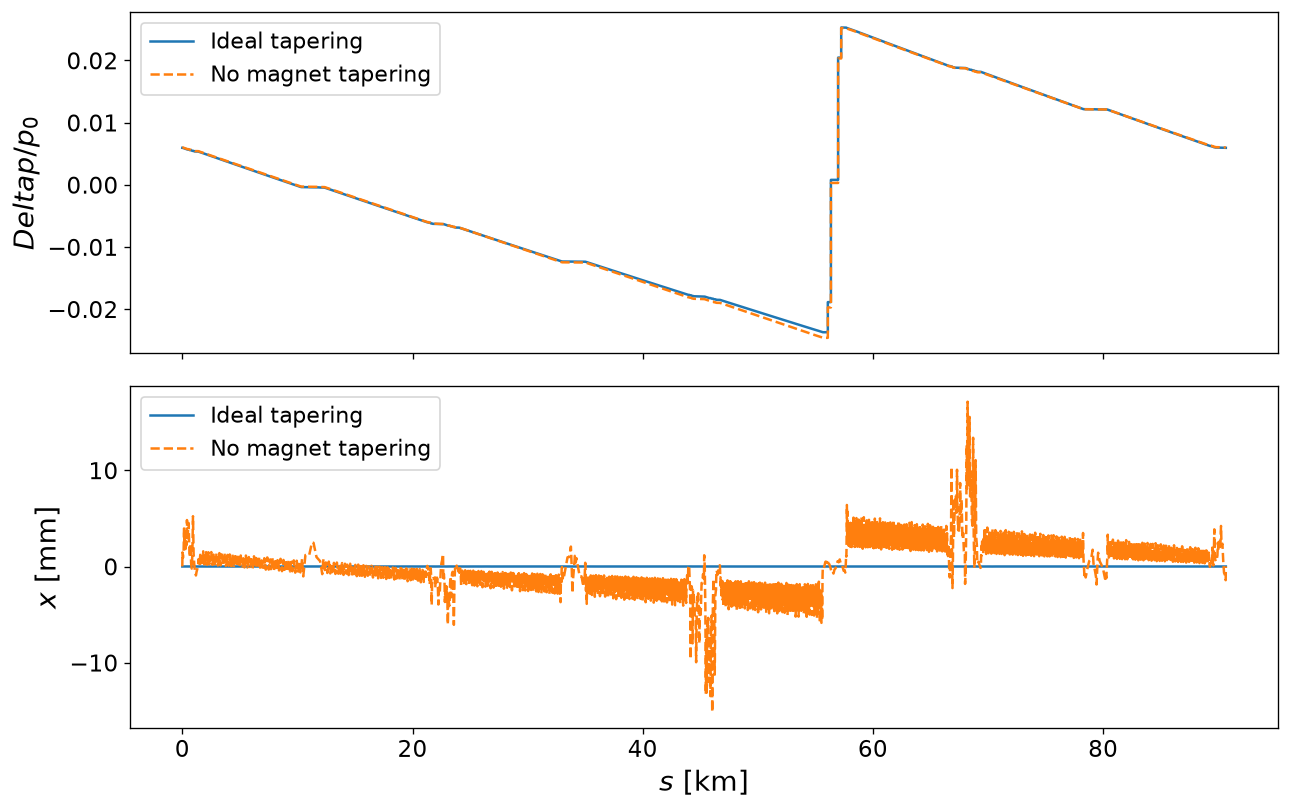

In [97]:
tw_no_taper = line.twiss(eneloss_and_damping=True)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[0].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[0].set_ylabel(
    r"$Delta p/p_0$"
)

axes[0].legend()


axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[1].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[1].set_xlabel(
    r"$s$ [km]"
)

axes[1].set_ylabel(
    r"$x$ [mm]"
)

axes[1].legend()

fig.tight_layout()
plt.show()




In [98]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss("results/notapering", tw_no_taper, ident="notapering")

In [99]:
# use markers to split into regions
def split_lattice_regions(line):
    ips = ["ipa", "ipb", "ipd", "ipf", "ipg", "iph", "ipj", "ipl"]

    table = line.get_table()
    names = np.asarray(table.name, dtype=str)
    s = np.asarray(table.s, dtype=float)

    valid = names != "_end_point"
    names = names[valid]
    s = s[valid]

    s_by_name = dict(zip(names, s))

    def select(start_marker, end_marker):
        start = s_by_name[start_marker]
        end = s_by_name[end_marker]

        if start <= end:
            mask = (s >= start) & (s < end)
        else:
            mask = (s >= start) | (s < end)

        return names[mask]

    arcs = {}
    arc_ds = {}
    ds = {}
    insertions = {}

    for i, left_ip in enumerate(ips):
        right_ip = ips[(i + 1) % len(ips)]
        sector = f"{left_ip}_{right_ip}"

        arcs[sector] = select(
            f"end_ds_start_arc_{left_ip}",
            f"end_arc_start_ds_{right_ip}",
        )

        arc_ds[sector] = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        right_ds = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_arc_{left_ip}",
        )

        left_ds = select(
            f"end_arc_start_ds_{right_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        ds[sector] = np.concatenate([right_ds, left_ds])

        insertions[right_ip] = select(
            f"end_ds_start_straight_{right_ip}",
            f"end_straight_start_ds_{right_ip}",
        )

    return {
        "arcs": arcs,
        "arc_ds": arc_ds,
        "ds": ds,
        "insertions": insertions,
    }

regions = split_lattice_regions(line)
regions


{'arcs': {'ipa_ipb': array(['bpm_qd1am.0', 'end_ds_start_arc_ipa', 'qd1am.0', ...,
         '||drift_30::323', 'bpm_qd1am.50', 'qd1am.50'],
        shape=(3053,), dtype='<U25'),
  'ipb_ipd': array(['end_ds_start_arc_ipb', 'qd1am.52', 'bpm_qd1am.52', ...,
         'mbd.1634', '||drift_36::287', 'qd1am.102'],
        shape=(3052,), dtype='<U25'),
  'ipd_ipf': array(['bpm_qd1am.104', 'end_ds_start_arc_ipd', 'qd1am.104', ...,
         '||drift_36::938', 'bpm_qd1am.154', 'qd1am.154'],
        shape=(3053,), dtype='<U25'),
  'ipf_ipg': array(['end_ds_start_arc_ipf', 'qd1am.156', 'bpm_qd1am.156', ...,
         'mbd.3314', '||drift_36::1473', 'qd1am.206'],
        shape=(3052,), dtype='<U25'),
  'ipg_iph': array(['bpm_qd1am.208', 'end_ds_start_arc_ipg', 'qd1am.208', ...,
         '||drift_36::2118', 'bpm_qd1am.258', 'qd1am.258'],
        shape=(3053,), dtype='<U25'),
  'iph_ipj': array(['end_ds_start_arc_iph', 'qd1am.260', 'bpm_qd1am.260', ...,
         'mbd.4934', '||drift_89::9', 'qd1am.310'

# Step 1: set insertions to perfect tapering

In [100]:
clear_delta_taper(line, elements_with_taper)

# make it flat for all inserions
insertion_element_names_flat = np.concatenate(list(regions["insertions"].values()))

# filter only the elements that have tapering
insertion_mask = np.isin(elements_with_taper,insertion_element_names_flat)

insertion_elements_with_taper = elements_with_taper[insertion_mask]
insertion_ideal_delta_taper = ideal_delta_taper[insertion_mask]

restore_ideal_tapering(line, insertion_elements_with_taper, insertion_ideal_delta_taper)
# get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
get_rf_phase(line)
rf_phase_insertions = read_rf_phase(line)

print(f"Restored ideal tapering for " f"{len(insertion_elements_with_taper)} insertion elements.")
rf_phase_insertions

/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 1): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


Restored ideal tapering for 1587 insertion elements.


,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.119203,-64.125604
1,rf800.0,4020.0,-1.135224,-65.043531
2,rf800.1,4020.0,-1.135224,-65.043531
3,rf400.1,990.0,-1.119203,-64.125604


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


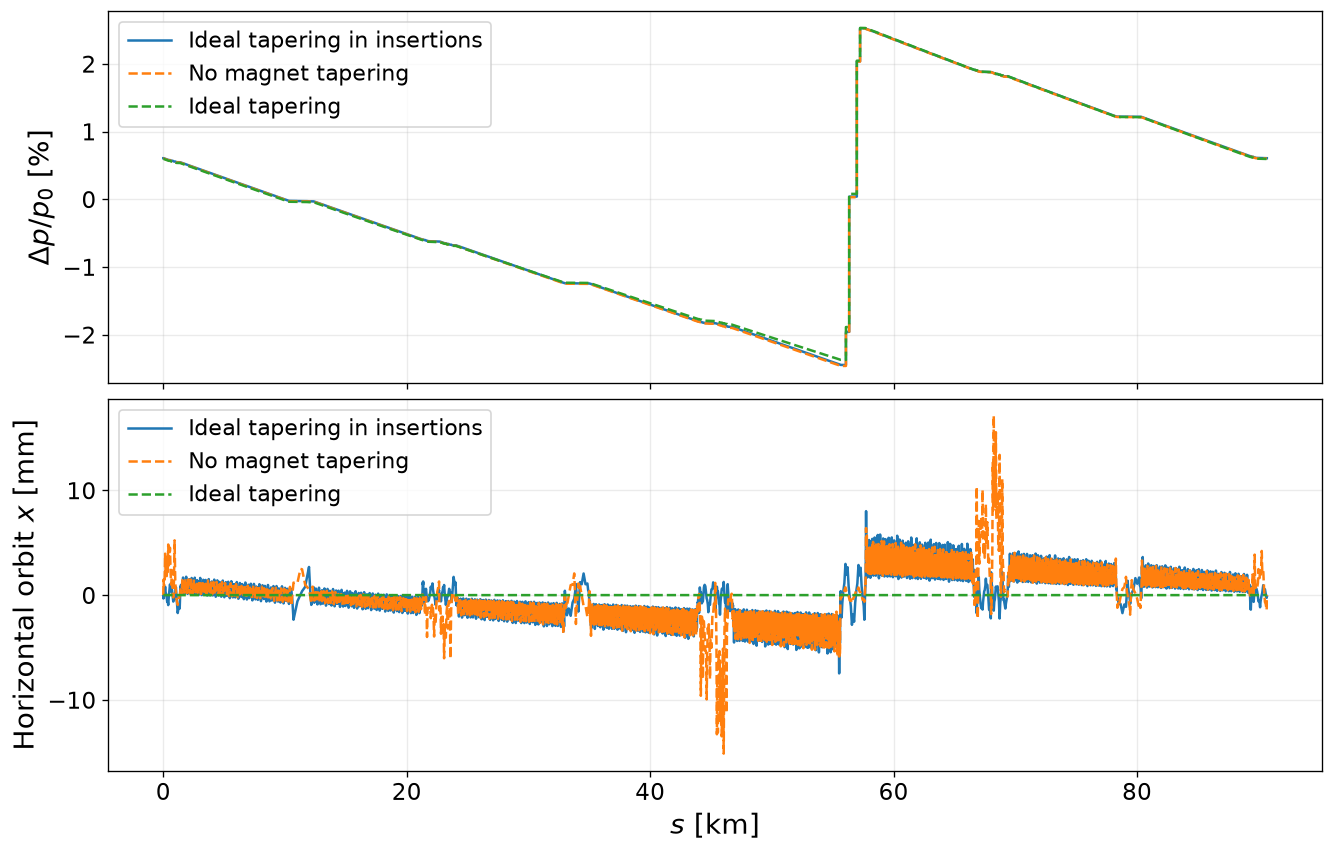

Saved: figures/scenario2_insertion_tapering_orbit_comparison.png


In [101]:


# twiss and plot orbit
twiss_insertion_taper = line.twiss(eneloss_and_damping=True)

fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 7),
    sharex=True,
    layout="constrained",
)

cases = [
    (
        twiss_insertion_taper,
        "Ideal tapering in insertions",
        "tab:blue",
        "-",
    ),
    (
        tw_no_taper,
        "No magnet tapering",
        "tab:orange",
        "--",
    ),
    (
        twiss_ideal,
        "Ideal tapering",
        "tab:green",
        "--",
    ),
]

# Relative momentum deviation
for twiss, label, color, linestyle in cases:
    axes[0].plot(
        np.asarray(twiss.s) / 1e3,
        np.asarray(twiss.delta)*1e2,
        color=color,
        ls=linestyle,
        lw=1.5,
        label=label,
    )

axes[0].set_ylabel(r"$\Delta p/p_0$ [%]")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.25)

# Horizontal closed orbit
for twiss, label, color, linestyle in cases:
    axes[1].plot(
        np.asarray(twiss.s) / 1e3,
        np.asarray(twiss.x) * 1e3,
        color=color,
        ls=linestyle,
        lw=1.5,
        label=label,
    )

axes[1].set_xlabel(r"$s$ [km]")
axes[1].set_ylabel(r"Horizontal orbit $x$ [mm]")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.25)

figure_path = FIGURE_DIR / "scenario2_insertion_tapering_orbit_comparison.png"
# fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

In [102]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss("results/insertion", twiss_insertion_taper, ident="insertion")

# Define circuits

In [103]:
# Define the number of tapering circuits for dipoles per sector. It should not separate dipoles of a cell in different circuits.
# n  :   1    2    4    5    7    8   10   14   20   28   35   40   56   70  140  280
# size: 840  420  210  168  120  105   84   60   42   30   24   21   15   12    6    3

N_DIPOLE_CIRCUITS_PER_SECTOR = 1

In [104]:
import re
import numpy as np
import pandas as pd


def define_arc_circuits(line, regions, n_dipole_circuits_per_sector=1):
    table = line.get_table()

    type_by_name = dict(
        zip(
            np.asarray(table.name, dtype=str),
            np.asarray(table.element_type, dtype=str),
        )
    )

    taperable = {
        name
        for name in line.element_names
        if hasattr(line[name], "delta_taper")
    }

    def family(name):
        # qf2a.15 -> qf2a
        # sf1a.32 -> sf1a
        return re.sub(r"\.\d+$", "", name.lower())

    def select(elements, element_type=None, prefix=None):
        selected = []

        for name in elements:
            if name not in taperable:
                continue

            if element_type is not None:
                if element_type not in type_by_name.get(name, ""):
                    continue

            if prefix is not None:
                prefixes = (
                    (prefix,)
                    if isinstance(prefix, str)
                    else tuple(prefix)
                )

                if not family(name).startswith(prefixes):
                    continue

            selected.append(name)

        return np.asarray(selected, dtype=str)

    def split_in_two(elements):
        """
        Split an ordered family into two contiguous circuits.

        The first circuit contains the first half of the magnets along s.
        The second circuit contains the remaining magnets.
        """
        elements = np.asarray(elements, dtype=str)

        first, second = np.array_split(elements, 2)

        return first, second
    
    def split_in_n(elements, n):
            """
            Split an ordered family into n contiguous circuits.
    
            The first circuit contains the first m/n magnets along s.
            The second circuit contains the next m/n magnets.
            etc. The last circuit contains the remaining magnets.
            """
            elements = np.asarray(elements, dtype=str)
    
            split_elements = np.array_split(elements, n)
    
            return split_elements

    circuits = {}

    for sector in regions["arcs"]:

        arc_elements = regions["arcs"][sector]
        arc_ds_elements = regions["arc_ds"][sector]
        
        # --------------------------------------------------------------
        # Dipoles
        # 
        # Can't use the original circuits because of the twin aperture.
        # New circuits with different granularity are defined here.
        # 
        # Circuit names: DIP_1, DIP_2, ..., DIP_n
        # --------------------------------------------------------------

        dipole_elements = select(
            arc_ds_elements,
            element_type="Bend",
        )
        
        dipoles_circuits = split_in_n(dipole_elements, n_dipole_circuits_per_sector)
        for i, dipole_circuit in enumerate(dipoles_circuits):
            circuits[f"DIP_{i+1}_{sector}"] = dipole_circuit

        # --------------------------------------------------------------
        # Quadrupoles
        #
        # Original circuits:
        #   QF, QD
        #
        # New circuits:
        #   QF_1, QF_2, QD_1, QD_2
        # --------------------------------------------------------------

        qf_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix=("qf2a", "qf3a"),
        )

        qd_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qd1a", # qd1a and qd1am
        )

        qf_1, qf_2 = split_in_two(qf_elements)
        qd_1, qd_2 = split_in_two(qd_elements)

        circuits[f"QF_1_{sector}"] = qf_1
        circuits[f"QF_2_{sector}"] = qf_2
        circuits[f"QD_1_{sector}"] = qd_1
        circuits[f"QD_2_{sector}"] = qd_2

        # --------------------------------------------------------------
        # Sextupoles
        #
        # Original circuits:
        #   SF1, SF2, SD1, SD2
        #
        # Each family is one circuit per arc.
        # --------------------------------------------------------------

        sextupole_families = {
            "SF1": "sf1a",
            "SF2": "sf2a",
            "SD1": "sd1a",
            "SD2": "sd2a",
        }

        for circuit_family, prefix in sextupole_families.items():

            family_elements = select(
                arc_elements,
                element_type="Sextupole",
                prefix=prefix,
            )
            
            circuits[f"{circuit_family}_{sector}"] = family_elements

    # Remove empty circuits.
    circuits = {
        name: elements
        for name, elements in circuits.items()
        if len(elements) > 0
    }

    return circuits

In [105]:

circuits = define_arc_circuits(line, regions, n_dipole_circuits_per_sector=N_DIPOLE_CIRCUITS_PER_SECTOR)

summary = pd.DataFrame([
    {
        "circuit": circuit,
        "number_of_elements": len(elements),
        "first_element": elements[0],
        "last_element": elements[-1],
    }
    for circuit, elements in circuits.items()
])

display(summary)

,circuit,number_of_elements,first_element,last_element
0,DIP_1_ipa_ipb,840,mbd.0,mbd.839
1,QF_1_ipa_ipb,67,qf2a.0,qf3a.13
2,QF_2_ipa_ipb,66,qf2a.53,qf2a.105
3,QD_1_ipa_ipb,67,qd1a.0,qd1a.53
4,QD_2_ipa_ipb,67,qd1a.54,qd1a.107
5,SF1_ipa_ipb,50,sf1a.0,sf1a.49
6,SF2_ipa_ipb,50,sf2a.0,sf2a.49
7,SD1_ipa_ipb,50,sd1a.0,sd1a.49
8,SD2_ipa_ipb,50,sd2a.0,sd2a.49
9,DIP_1_ipb_ipd,840,mbd.840,mbd.1679


In [106]:
circuits['DIP_1_iph_ipj']

array(['mbd3r_rf.0', 'mbd3r_rf.1', 'mbd3r_rf.2', 'mbd2r_rf.0',
       'mbd2r_rf.1', 'mbd2r_rf.2', 'mbd1r_rf.0', 'mbd1r_rf.1',
       'mbd1r_rf.2', 'mbd.4179', 'mbd.4180', 'mbd.4181', 'mbd9r_rf.0',
       'mbd9r_rf.1', 'mbd9r_rf.2', 'mbd9r_rf.3', 'mbd9r_rf.4',
       'mbd9r_rf.5', 'mbd9r_rf.6', 'mbd9r_rf.7', 'mbd9r_rf.8',
       'mbd8r_rf.0', 'mbd8r_rf.1', 'mbd8r_rf.2', 'mbd8r_rf.3',
       'mbd8r_rf.4', 'mbd8r_rf.5', 'mbd8r_rf.6', 'mbd8r_rf.7',
       'mbd8r_rf.8', 'mbd.4182', 'mbd.4183', 'mbd.4184', 'mbd0r_rf.0',
       'mbd0r_rf.1', 'mbd0r_rf.2', 'mbd0r_rf.3', 'mbd0r_rf.4',
       'mbd0r_rf.5', 'mbd0r_rf.6', 'mbd0r_rf.7', 'mbd0r_rf.8',
       'mbd0r_rf.9', 'mbd0r_rf.10', 'mbd0r_rf.11', 'mbd.4185', 'mbd.4186',
       'mbd.4187', 'mbd.4188', 'mbd.4189', 'mbd.4190', 'mbd.4191',
       'mbd.4192', 'mbd.4193', 'mbd.4194', 'mbd.4195', 'mbd.4196',
       'mbd.4197', 'mbd.4198', 'mbd.4199', 'mbd.4200', 'mbd.4201',
       'mbd.4202', 'mbd.4203', 'mbd.4204', 'mbd.4205', 'mbd.4206',
       'mbd

# Step 2: set dipoles in coarse granularity

In [107]:
def circuit_average_tapering_setters(line, circuits, dipole_tapering=True, quadrupole_tapering=True, sextupole_tapering=True):
    """
    Return a list of MultiSetter objects for the given circuits for average tapering.

    Each MultiSetter object can be used to set the delta_taper field
    for all magnets in a circuit simultaneously.
    """
    delta_taper_setters = []

    for circuit in circuits.keys():
        
        if circuit.startswith("DIP") and dipole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )
        if circuit.startswith("Q") and quadrupole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )
        if circuit.startswith("S") and sextupole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )

    return delta_taper_setters

In [108]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=False, 
                                                            sextupole_tapering=False)

delta_taper_setters_zero = circuit_average_tapering_setters(line,
                                                            circuits,
                                                            dipole_tapering=False,
                                                            quadrupole_tapering=True,
                                                            sextupole_tapering=True)

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(8, 66)

In [109]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-1.08897882e-09], x=[-0.00182832], y=[-3.97354937e-12], px=[1.14683706e-05], py=[-1.66056984e-13], ptau=[0.00038806], delta=[0.00038806], rpp=[0.99961209], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -9070.804709732869
Energy loss diff.: 0.04970303950558041
Iteration 1


/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (tapering iteration 0): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-0.00190771], x=[-6.36524966e-05], y=[1.75029069e-11], px=[1.10921689e-06], py=[7.4921732e-15], ptau=[0.00074192], delta=[0.00074192], rpp=[0.99925863], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8944.287609467254
Energy loss diff.: 0.0006932443850197756
Iteration 2
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-1.50312239e-06], x=[-7.47075184e-05], y=[1.50162219e-11], px=[1.20349384e-06], py=[2.2989578e-13], ptau=[0.00073782], delta=[0.00073782], rpp=[0.99926273], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0

In [110]:
def read_applied_tapering(line, circuits, circuit_prefixes, ideal_taper_by_name):
    applied_settings = []
    
    p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
    charge_number = abs(float(line.particle_ref.q0))
    magnetic_rigidity_Tm = p0c_GeV / (0.299792458 * charge_number)

    for circuit_name, circuit_elements in circuits.items():

        if not circuit_name.startswith(tuple(circuit_prefixes)):
            continue

        elements = [
            name for name in circuit_elements
            if name in ideal_taper_by_name
        ]

        if len(elements) == 0:
            continue

        applied_values = np.asarray(
            [float(line[name].delta_taper) for name in elements],
            dtype=float,
        )

        ideal_values = np.asarray(
            [ideal_taper_by_name[name] for name in elements],
            dtype=float,
        )
        if circuit_name.startswith("DIP"): # angle * delta_taper * Brho * 1e3
            magnet_change = line.element_refs[elements[0]].angle._get_value() * np.mean(applied_values) * magnetic_rigidity_Tm * 1e3
            unit_magnet_change = "mT.m"
        elif circuit_name.startswith("QF") or circuit_name.startswith("QD"): #k1L * delta_taper * Brho * 1e3
            magnet_change = line.element_refs[elements[0]].k1._get_value()* line.element_refs[elements[0]].length._get_value() * np.mean(applied_values) * magnetic_rigidity_Tm * 1e3
            unit_magnet_change = "mT"
        elif circuit_name.startswith("SF") or circuit_name.startswith("SD"): #k2L * delta_taper * Brho * 1e3
            magnet_change = line.element_refs[elements[0]].k2._get_value()* line.element_refs[elements[0]].length._get_value() * np.mean(applied_values) * magnetic_rigidity_Tm * 1e3
            unit_magnet_change = "mT/m"
        else: # unknown family: no field conversion, and never inherit the previous circuit
            magnet_change = np.nan
            unit_magnet_change = "n/a"

        applied_settings.append({
            "circuit": circuit_name,
            "number_of_elements": len(elements),
            "applied_delta_taper": np.mean(applied_values),
            "ideal_min": np.min(ideal_values),
            "ideal_max": np.max(ideal_values),
            "maximum_error": np.max(
                np.abs(ideal_values - applied_values)
            ),
            f"magnet_change ({unit_magnet_change})": magnet_change,
        })

    return pd.DataFrame(applied_settings)

In [111]:
read_applied_tapering(line, circuits, ["DIP"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error,magnet_change (mT.m)
0,DIP_1_ipa_ipb,840,0.002429,-0.000367,0.005360,0.002931,1.288393
1,DIP_1_ipb_ipd,840,-0.003305,-0.006037,-0.000440,0.002865,-1.753121
2,DIP_1_ipd_ipf,840,-0.009673,-0.012334,-0.006879,0.002794,-5.130546
3,DIP_1_ipf_ipg,840,-0.015095,-0.017698,-0.012361,0.002734,-8.006601
4,DIP_1_ipg_iph,840,-0.021169,-0.023708,-0.018501,0.002668,-11.228192
5,DIP_1_iph_ipj,840,0.022133,0.019107,0.025289,0.003156,16.532171
6,DIP_1_ipj_ipl,840,0.015098,0.012155,0.018177,0.003079,8.007966
7,DIP_1_ipl_ipa,840,0.009117,0.006244,0.012125,0.003009,4.835716


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


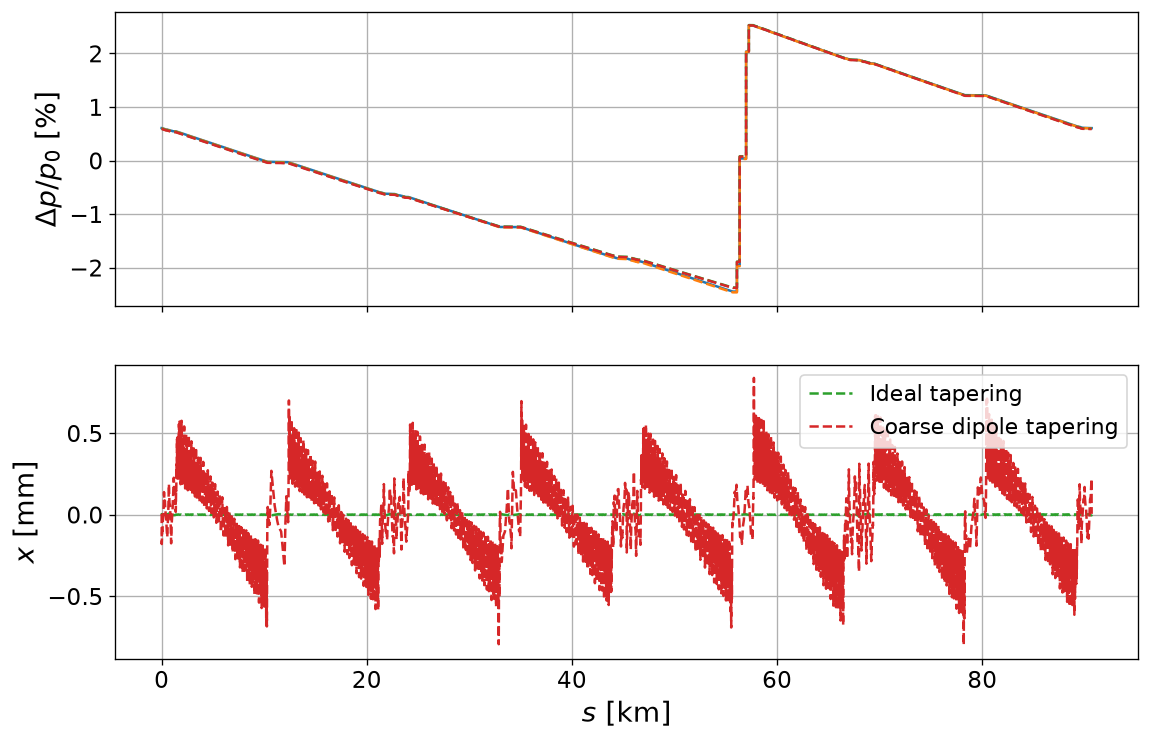

In [112]:
rf_phase_dipole = read_rf_phase(line)

# Twiss and plot orbit
twiss_dipole = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta*1e2,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta*1e2,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta*1e2,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.delta*1e2,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

axes[0].set_ylabel(r"$\Delta p/p_0$ [%]")
plt.grid(True)
plt.sca(axes[1])
#plt.plot(
#    twiss_insertion_taper.s / 1e3,
#    twiss_insertion_taper.x * 1e3,
#    color="tab:blue",
#    lw=1.5,
#    label="Tapering in insertions",
#)
#plt.plot(
#    tw_no_taper.s / 1e3,
#    tw_no_taper.x * 1e3,
#    color="tab:orange",
#    ls="--",
#    lw=1.5,
#    label="No magnet tapering",
#)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)
plt.grid(True)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")
figure_path = FIGURE_DIR / "granularity_scenario2_dipole_trims.png"
# fig.savefig(figure_path, dpi=300, bbox_inches="tight")

In [113]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss(f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}", twiss_dipole, ident=f"D{N_DIPOLE_CIRCUITS_PER_SECTOR}")

# Step 3 set quad and sextupoles in coarse granularity

## 3.1 Quad realistic, no sextupole

In [114]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=True, 
                                                            sextupole_tapering=False)

delta_taper_setters_zero = circuit_average_tapering_setters(line,
                                                            circuits,
                                                            dipole_tapering=False,
                                                            quadrupole_tapering=False,
                                                            sextupole_tapering=True)

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(40, 34)

In [115]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-4.3565626e-07], x=[-7.36218842e-05], y=[2.00019946e-13], px=[1.19594697e-06], py=[1.01770757e-15], ptau=[0.00073116], delta=[0.00073116], rpp=[0.99926938], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8943.945330898416
Energy loss diff.: 0.04900791962155329
Iteration 1
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[1.00218919e-06], x=[-0.0001161], y=[-5.40322715e-13], px=[1.55986525e-06], py=[-7.11190658e-15], ptau=[0.00073322], delta=[0.00073322], rpp=[0.999

In [116]:
# Dipoles tapering
read_applied_tapering(line, circuits, ["DIP"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error,magnet_change (mT.m)
0,DIP_1_ipa_ipb,840,0.002447,-0.000367,0.005360,0.002912,1.298179
1,DIP_1_ipb_ipd,840,-0.003287,-0.006037,-0.000440,0.002847,-1.743547
2,DIP_1_ipd_ipf,840,-0.009655,-0.012334,-0.006879,0.002776,-5.121244
3,DIP_1_ipf_ipg,840,-0.015078,-0.017698,-0.012361,0.002717,-7.997502
4,DIP_1_ipg_iph,840,-0.021152,-0.023708,-0.018501,0.002651,-11.219331
5,DIP_1_iph_ipj,840,0.022153,0.019107,0.025289,0.003137,16.547001
6,DIP_1_ipj_ipl,840,0.015117,0.012155,0.018177,0.003060,8.018261
7,DIP_1_ipl_ipa,840,0.009136,0.006244,0.012125,0.002989,4.845797


In [117]:
# Quadrupoles tapering
read_applied_tapering(line, circuits, [ "QF", "QD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error,magnet_change (mT)
0,QF_1_ipa_ipb,67,0.003799,0.002480,0.005198,0.001399,110.574714
1,QF_2_ipa_ipb,66,0.001075,-0.000209,0.002439,0.001364,31.301803
2,QD_1_ipa_ipb,67,0.003819,0.002500,0.005218,0.001399,-95.591093
3,QD_2_ipa_ipb,67,0.001075,-0.000229,0.002459,0.001384,-26.915125
4,QF_1_ipb_ipd,67,-0.001967,-0.003254,-0.000598,0.001368,-57.247418
5,QF_2_ipb_ipd,66,-0.004628,-0.005882,-0.003294,0.001334,-134.721700
6,QD_1_ipb_ipd,67,-0.001947,-0.003234,-0.000578,0.001368,48.721659
7,QD_2_ipb_ipd,67,-0.004628,-0.005902,-0.003274,0.001354,115.839417
8,QF_1_ipd_ipf,67,-0.008368,-0.009622,-0.007033,0.001335,-243.588372
9,QF_2_ipd_ipf,66,-0.010962,-0.012183,-0.009661,0.001302,-319.101236


In [118]:
rf_phase_quad = read_rf_phase(line)

rf_phase_quad

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103220,-63.209839
1,rf800.0,4020.0,-1.103258,-63.212001
2,rf800.1,4020.0,-1.103258,-63.212001
3,rf400.1,990.0,-1.103220,-63.209839


In [119]:
twiss_quad = line.twiss(eneloss_and_damping=True, radiation_analysis=True)

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


In [120]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss(f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr", twiss_quad, ident=f"D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr")

## 3.2 Ideal quad, no sextupole

In [121]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# # Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
# delta_taper_setters_mean = circuit_average_tapering_setters(line, 
#                                                             circuits, 
#                                                             dipole_tapering=True, 
#                                                             quadrupole_tapering=False, 
#                                                             sextupole_tapering=False)
#
# delta_taper_setters_zero = circuit_average_tapering_setters(line,
#                                                             circuits,
#                                                             dipole_tapering=False,
#                                                             quadrupole_tapering=False,
#                                                             sextupole_tapering=True)
#
# # No tapering in the correctors 
# h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
# v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]
#
#
# delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
# delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))
#
# len(delta_taper_setters_mean), len(delta_taper_setters_zero)


In [122]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# # Realisitic tapering with energy loss compensation
# MAX_ITER = 10
# TOLERANCE = 1e-9
# CAVITY_MIDPOINT = "qd18f.0"
#
# co = compensate_energy_loss(
#     line,
#     delta_taper_setters_mean=delta_taper_setters_mean,
#     delta_taper_setters_no_tapering= delta_taper_setters_zero,
#     apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
#     cavity_midpoint= CAVITY_MIDPOINT,
#     verbose=True,
#     max_iter = MAX_ITER,
#     tolerance= TOLERANCE
# )


In [123]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# twiss_idealquad = line.twiss(eneloss_and_damping=True, radiation_analysis=True)


In [124]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# if SAVE_STEPS_TWISS:
#     io_ckpt.write_twiss(f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qp", twiss_idealquad, ident=f"D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qp")


## 3.3 Ideal quad, realistic sextupole

In [125]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# # Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
# delta_taper_setters_mean = circuit_average_tapering_setters(line, 
#                                                             circuits, 
#                                                             dipole_tapering=True, 
#                                                             quadrupole_tapering=False, 
#                                                             sextupole_tapering=True)
#
# delta_taper_setters_zero = []
#
# # No tapering in the correctors 
# h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
# v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]
#
#
# delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
# delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))
#
# len(delta_taper_setters_mean), len(delta_taper_setters_zero)


In [126]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# # Realisitic tapering with energy loss compensation
# MAX_ITER = 10
# TOLERANCE = 1e-9
# CAVITY_MIDPOINT = "qd18f.0"
#
# co = compensate_energy_loss(
#     line,
#     delta_taper_setters_mean=delta_taper_setters_mean,
#     delta_taper_setters_no_tapering= delta_taper_setters_zero,
#     apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
#     cavity_midpoint= CAVITY_MIDPOINT,
#     verbose=True,
#     max_iter = MAX_ITER,
#     tolerance= TOLERANCE
# )


In [127]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# twiss_idealquad_sext = line.twiss(eneloss_and_damping=True, radiation_analysis=True)


In [128]:
# Not run by default: uncomment this section to produce the ideal-quadrupole comparison.
# if SAVE_STEPS_TWISS:
#     io_ckpt.write_twiss(f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qp_Sr", twiss_idealquad_sext, ident=f"D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qp_Sr")


## 3.4 Realistic quad, realistic sextupole

In [129]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=True, 
                                                            sextupole_tapering=True)

delta_taper_setters_zero =[]

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(72, 2)

In [130]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[1.11242361e-06], x=[-0.00011611], y=[-1.99337003e-12], px=[1.55995355e-06], py=[-2.65778089e-14], ptau=[0.00075242], delta=[0.00075242], rpp=[0.99924815], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8944.69836691547
Energy loss diff.: 0.04901204584630429
Iteration 1
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[1.11778237e-06], x=[-0.0001161], y=[-1.99400847e-12], px=[1.56308548e-06], py=[-2.65850627e-14], ptau=[0.00075455], delta=[0.00075455], rpp=[0.999246

In [131]:
# Quadrupoles tapering
read_applied_tapering(line, circuits, [ "QF", "QD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error,magnet_change (mT)
0,QF_1_ipa_ipb,67,0.003820,0.002480,0.005198,0.001377,111.201496
1,QF_2_ipa_ipb,66,0.001097,-0.000209,0.002439,0.001342,31.921808
2,QD_1_ipa_ipb,67,0.003841,0.002500,0.005218,0.001378,-96.130073
3,QD_2_ipa_ipb,67,0.001097,-0.000229,0.002459,0.001363,-27.448233
4,QF_1_ipb_ipd,67,-0.001946,-0.003254,-0.000598,0.001347,-56.634920
5,QF_2_ipb_ipd,66,-0.004607,-0.005882,-0.003294,0.001313,-134.115713
6,QD_1_ipb_ipd,67,-0.001926,-0.003234,-0.000578,0.001347,48.194963
7,QD_2_ipb_ipd,67,-0.004607,-0.005902,-0.003274,0.001333,115.318362
8,QF_1_ipd_ipf,67,-0.008348,-0.009622,-0.007033,0.001314,-242.991446
9,QF_2_ipd_ipf,66,-0.010942,-0.012183,-0.009661,0.001281,-318.510534


In [132]:
# Sextupoles tapering
read_applied_tapering(line, circuits, [ "SF", "SD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error,magnet_change (mT/m)
0,SF1_ipa_ipb,50,0.002468,-0.000006,0.004991,0.002522,612.008979
1,SF2_ipa_ipb,50,0.002468,-0.000046,0.005032,0.002564,575.443348
2,SD1_ipa_ipb,50,0.002468,-0.000026,0.005011,0.002543,-951.214034
3,SD2_ipa_ipb,50,0.002468,0.000014,0.004970,0.002502,-1072.594735
4,SF1_ipb_ipd,50,-0.003267,-0.005684,-0.000801,0.002466,-809.968181
5,SF2_ipb_ipd,50,-0.003267,-0.005723,-0.000760,0.002507,-761.572427
6,SD1_ipb_ipd,50,-0.003267,-0.005704,-0.000780,0.002486,1258.889983
7,SD2_ipb_ipd,50,-0.003267,-0.005664,-0.000821,0.002446,1419.535349
8,SF1_ipd_ipf,50,-0.009635,-0.011990,-0.007230,0.002405,-2389.006077
9,SF2_ipd_ipf,50,-0.009635,-0.012029,-0.007191,0.002444,-2246.264757


In [133]:
rf_phase_quad_sext = read_rf_phase(line)

rf_phase_quad_sext

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103313,-63.215200
1,rf800.0,4020.0,-1.103445,-63.222724
2,rf800.1,4020.0,-1.103445,-63.222724
3,rf400.1,990.0,-1.103313,-63.215200


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

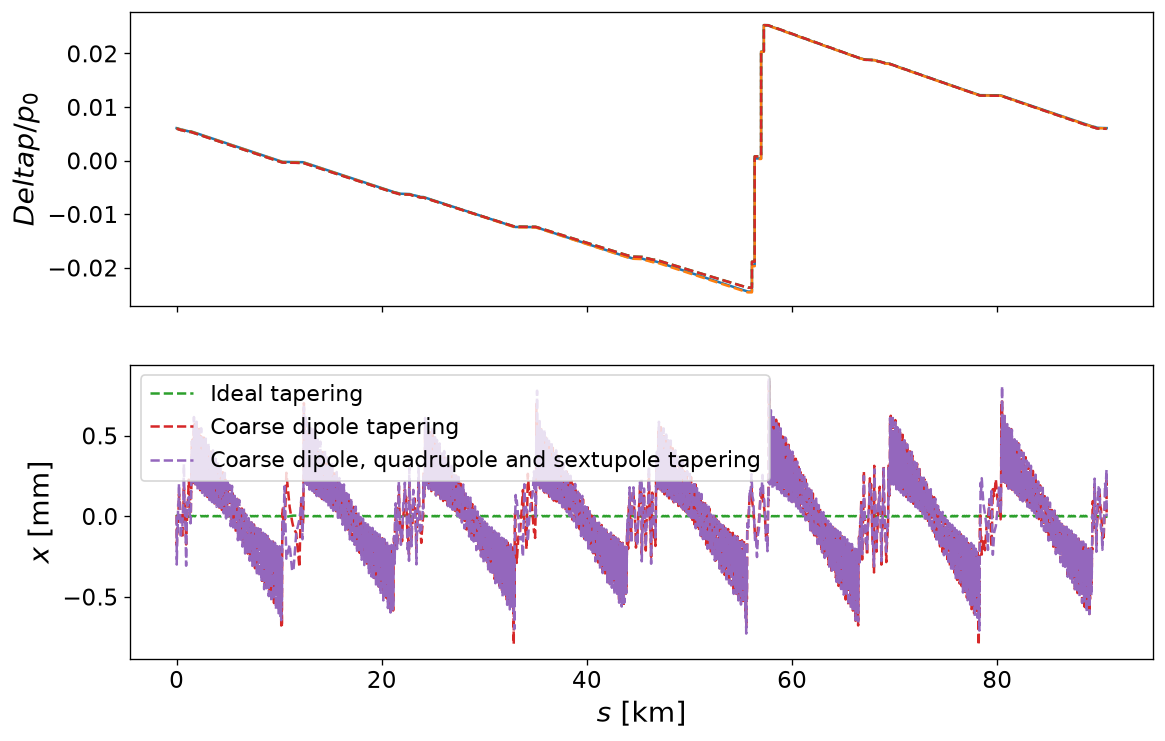

In [134]:
# twiss and plot orbit
twiss_quad_sext = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse quadrupole and sextupole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])

plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

# dipoles
plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.5,
    label="Coarse dipole, quadrupole and sextupole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

In [135]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss(f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr_Sr", twiss_quad_sext, ident=f"D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr_Sr")

# Step 4: correct the horizontal orbit with one dipole trim per arc+DS cell

In [136]:
twiss_ideal["length"]

array([0. , 0. , 2.4, ..., 2.4, 0. , 0. ], shape=(30053,))

In [137]:
from scipy.sparse.linalg import lsmr

# Which dipole of a three-dipole arc cell carries the trim: 1, 2 or 3.
TRIM_POSITION_IN_CELL = 1   # upstream dbae06d; local value was 3

# Index of the trim inside a cell, per choice of position and per cell size.
# The two-dipole cells of the dispersion suppressors follow the three-dipole
# cells as closely as they can: they stay on their first dipole for the first
# two positions and move to their second one for the third.
TRIM_INDEX_IN_CELL = {
    # position: {dipoles in the cell: index of the trim in the cell}
    1: {3: 0, 2: 0},
    2: {3: 1, 2: 0},
    3: {3: 2, 2: 1},
}


def dipole_cells_in_region(line, element_names):
    """Split a region into cells: the dipoles sitting between two quadrupoles.

    An arc cell holds three dipoles. Close to the straight sections, at the
    beginning and at the end of the dispersion suppressors, the cells hold two
    dipoles instead. The cells are therefore read from the lattice itself
    rather than by reshaping the dipole list in groups of three.
    """
    table = line.get_table()
    type_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.element_type, dtype=str),
    ))

    cells = []
    cell = []
    for name in np.asarray(element_names, dtype=str):
        element_type = type_by_name.get(str(name), "")
        if "Bend" in element_type:
            cell.append(str(name))
        elif "Quadrupole" in element_type and cell:
            cells.append(cell)
            cell = []
    if cell:
        cells.append(cell)

    sizes = sorted({len(cell) for cell in cells})
    if not set(sizes) <= {2, 3}:
        raise ValueError(
            f"cells of {sizes} dipoles found; only cells of two or three "
            "dipoles are expected in the arc+DS regions."
        )

    return cells


def select_trim_dipole_of_each_cell(line, regions, position=TRIM_POSITION_IN_CELL):
    """One dipole per arc+DS cell, used as a horizontal orbit corrector.

    `position` chooses which dipole of a three-dipole cell carries the trim:
    1 for the first, 2 for the second, 3 for the third. The two-dipole cells
    next to the straight sections follow along through `TRIM_INDEX_IN_CELL`:
    their first dipole for positions 1 and 2, their second one for position 3.
    There is still exactly one trim per cell everywhere.
    """
    if position not in TRIM_INDEX_IN_CELL:
        raise ValueError(
            f"position must be one of {sorted(TRIM_INDEX_IN_CELL)}, got {position}"
        )

    table = line.get_table()
    tw = line.twiss(eneloss_and_damping=True)
    s_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.s, dtype=float),
    ))
    length_by_name = dict(zip(
        np.asarray(tw.name, dtype=str),
        np.asarray(tw.length, dtype=float),
    ))

    selected = []
    rows = []
    # i keep dipoles also in the DS
    for sector, arc_ds_elements in regions["arc_ds"].items():
        cells = dipole_cells_in_region(line, arc_ds_elements)

        for cell_number, cell in enumerate(cells):
            index = TRIM_INDEX_IN_CELL[position][len(cell)]
            trim_dipole = cell[index]
            selected.append(trim_dipole)

            row = {
                "sector": sector,
                "cell": cell_number,
                "dipoles_in_cell": len(cell),
                "position_in_cell": index + 1,
                "trim_dipole": trim_dipole,
                "s_km": s_by_name[trim_dipole] / 1e3,
                "length_m": length_by_name[trim_dipole],
            }
            # dipole_1, dipole_2 and, for the three-dipole cells, dipole_3.
            row.update({
                f"dipole_{i + 1}": name for i, name in enumerate(cell)
            })
            rows.append(row)

    return np.asarray(selected, dtype=str), pd.DataFrame(rows)


def validate_trim_dipole_selection(
    line,
    regions,
    trim_dipole_names,
    trim_layout,
    position=TRIM_POSITION_IN_CELL,
):
    expected = []
    sector_rows = []

    for sector, arc_ds_elements in regions["arc_ds"].items():
        cells = dipole_cells_in_region(line, arc_ds_elements)

        expected_sector = np.asarray([
            cell[TRIM_INDEX_IN_CELL[position][len(cell)]] for cell in cells
        ], dtype=str)
        expected.extend(expected_sector)

        selected_sector = trim_layout.loc[
            trim_layout["sector"] == sector,
            "trim_dipole",
        ].to_numpy(dtype=str)

        sector_rows.append({
            "sector": sector,
            "dipoles_in_arc_ds": sum(len(cell) for cell in cells),
            "cells_of_three": sum(1 for cell in cells if len(cell) == 3),
            "cells_of_two": sum(1 for cell in cells if len(cell) == 2),
            "expected_trims": len(expected_sector),
            "selected_trims": len(selected_sector),
            "selection_is_correct": np.array_equal(
                selected_sector,
                expected_sector,
            ),
        })

    expected = np.asarray(expected, dtype=str)
    selected = np.asarray(trim_dipole_names, dtype=str)

    assert len(selected) == len(np.unique(selected)), "Duplicate trim dipoles found"
    assert np.array_equal(selected, expected), (
        f"The selected list is not dipole {position} of every three-dipole "
        f"cell and dipole {TRIM_INDEX_IN_CELL[position][2] + 1} of every "
        "two-dipole cell in each arc+DS sector."
    )
    assert np.all(
        trim_layout["trim_dipole"].to_numpy(dtype=str)
        == trim_layout.apply(
            lambda row: row[f"dipole_{int(row['position_in_cell'])}"],
            axis=1,
        ).to_numpy(dtype=str)
    )

    summary = pd.DataFrame(sector_rows)
    assert summary["selection_is_correct"].all()

    print(
        f"Validated {len(selected)} trims: dipole {position} of "
        f"{int(summary['cells_of_three'].sum())} three-dipole cells and dipole "
        f"{TRIM_INDEX_IN_CELL[position][2] + 1} of "
        f"{int(summary['cells_of_two'].sum())} two-dipole cells in the "
        "arc+DS regions."
    )
    return summary


def set_horizontal_dipole_trim_kicks(
    line,
    dipole_names,
    base_knl,
    trim_kicks_rad,
):
    for dipole_name, base_value, kick in zip(
        dipole_names,
        base_knl,
        trim_kicks_rad,
    ):
        # A positive horizontal kick corresponds to a negative knl[0].
        line.element_refs[dipole_name].knl[0] = float(base_value - kick)


def prepare_horizontal_dipole_trims(line, dipole_names):
    base_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ], dtype=float)

    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )
    return base_knl


def verify_horizontal_dipole_trims(
    line,
    dipole_names,
    base_knl,
    test_kick_rad=1e-9,
):
    test_kicks = np.full(len(dipole_names), test_kick_rad)
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        test_kicks,
    )

    installed_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ])
    expected_knl = base_knl - test_kicks

    # Restore zero trims before starting the correction.
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )

    if not np.allclose(installed_knl, expected_knl, rtol=1e-10, atol=1e-16):
        bad = np.flatnonzero(~np.isclose(
            installed_knl,
            expected_knl,
            rtol=1e-10,
            atol=1e-16,
        ))
        raise RuntimeError(
            f"{len(bad)} numerical dipole trims failed the knl[0] test. "
            f"First failed element: {dipole_names[bad[0]]}"
        )

    print(
        f"Verified {len(dipole_names)} numerical trims in knl[0]."
    )

In [138]:
# BPMs and one selected dipole trim per three-dipole cell in arc+DS.
tt_monitors = tt.rows['bpm.*']
monitor_names = np.asarray(tt_monitors.name, dtype=str)
monitor_s = np.asarray(tt_monitors.s, dtype=float)

In [139]:
trim_dipole_names, trim_layout = select_trim_dipole_of_each_cell(
    line,
    regions,
    position=TRIM_POSITION_IN_CELL,
)

selection_summary = validate_trim_dipole_selection(
    line,
    regions,
    trim_dipole_names,
    trim_layout,
    position=TRIM_POSITION_IN_CELL,
)

Validated 2262 trims: dipole 1 of 2196 three-dipole cells and dipole 1 of 66 two-dipole cells in the arc+DS regions.


In [140]:
trim_base_knl = prepare_horizontal_dipole_trims(
    line,
    trim_dipole_names,
)
verify_horizontal_dipole_trims(
    line,
    trim_dipole_names,
    trim_base_knl,
)


Verified 2262 numerical trims in knl[0].


BPMs: 2636
Horizontal dipole trims: 2262


,sector,dipoles_in_arc_ds,cells_of_three,cells_of_two,expected_trims,selected_trims,selection_is_correct
0,ipa_ipb,840,274,9,283,283,True
1,ipb_ipd,840,274,9,283,283,True
2,ipd_ipf,840,274,9,283,283,True
3,ipf_ipg,840,274,9,283,283,True
4,ipg_iph,840,276,6,282,282,True
5,iph_ipj,840,276,6,282,282,True
6,ipj_ipl,840,274,9,283,283,True
7,ipl_ipa,840,274,9,283,283,True


,sector,cell,dipoles_in_cell,position_in_cell,trim_dipole,s_km,length_m,dipole_1,dipole_2,dipole_3
0,ipa_ipb,0,2,1,mbd.0,1.363667,9.613334,mbd.0,mbd.1,NaN
1,ipa_ipb,1,2,1,mbd.2,1.385089,9.613334,mbd.2,mbd.3,NaN
2,ipa_ipb,2,2,1,mbd.4,1.407540,9.613334,mbd.4,mbd.5,NaN
3,ipa_ipb,3,2,1,mbd.6,1.428962,9.613334,mbd.6,mbd.7,NaN
4,ipa_ipb,4,2,1,mbd.8,1.451414,9.613334,mbd.8,mbd.9,NaN
5,ipa_ipb,5,2,1,mbd.10,1.472835,9.613334,mbd.10,mbd.11,NaN
6,ipa_ipb,6,3,1,mbd.12,1.495687,9.613334,mbd.12,mbd.13,mbd.14
7,ipa_ipb,7,3,1,mbd.15,1.526757,9.613334,mbd.15,mbd.16,mbd.17
8,ipa_ipb,8,3,1,mbd.18,1.559257,9.613334,mbd.18,mbd.19,mbd.20
9,ipa_ipb,9,3,1,mbd.21,1.590947,9.613334,mbd.21,mbd.22,mbd.23


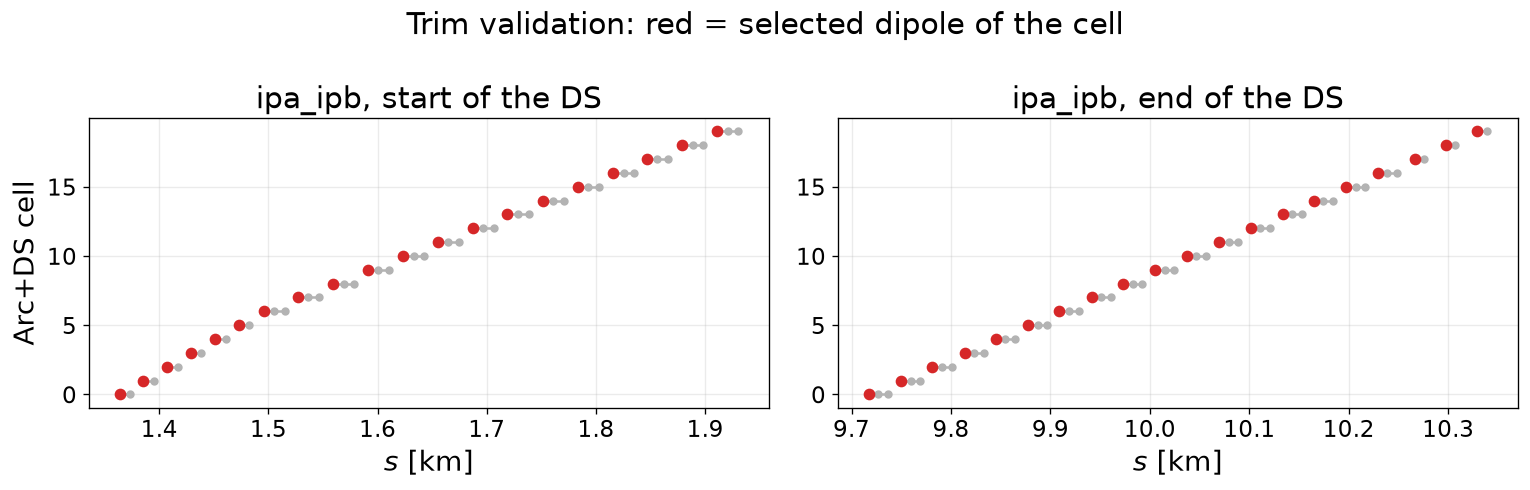

In [141]:
print(f"BPMs: {len(monitor_names)}")
print(f"Horizontal dipole trims: {len(trim_dipole_names)}")
display(selection_summary)
display(trim_layout.head(12))

# Visual check: within every row, the red point must be the dipole that
# TRIM_INDEX_IN_CELL prescribes among the ordered dipoles of the cell shown
# in grey, for the size of that cell.
dipole_columns = [
    name for name in trim_layout.columns if name.startswith("dipole_")
]
first_sector = trim_layout['sector'].iloc[0]
sector_layout = trim_layout[trim_layout['sector'] == first_sector]
panels = {
    'start of the DS': sector_layout.head(20),
    'end of the DS': sector_layout.tail(20),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (panel_label, panel_rows) in zip(axes, panels.items()):
    for row_number, (_, row) in enumerate(panel_rows.iterrows()):
        names = [row[name] for name in dipole_columns if isinstance(row[name], str)]
        s_cell = np.asarray(tt.s[tt.rows.indices[names]], dtype=float) / 1e3
        ax.plot(s_cell, np.full(len(names), row_number), 'o-', color='0.7', ms=4)
        ax.plot(
            s_cell[int(row['position_in_cell']) - 1],
            row_number,
            'o',
            color='tab:red',
            ms=6,
        )
    ax.set_xlabel(r'$s$ [km]')
    ax.set_title(f'{first_sector}, {panel_label}')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Arc+DS cell')
fig.suptitle('Trim validation: red = selected dipole of the cell')
fig.tight_layout()
plt.show()

In [142]:
def build_horizontal_response_matrix(twiss, monitor_names, trim_dipole_names):
    monitor_indices = twiss.rows.indices[list(monitor_names)]
    trim_indices = twiss.rows.indices[list(trim_dipole_names)]

    beta_monitor = np.asarray(twiss.betx[monitor_indices], dtype=float)
    beta_trim = np.asarray(twiss.betx[trim_indices], dtype=float)
    mu_monitor = np.asarray(twiss.mux[monitor_indices], dtype=float)
    mu_trim = np.asarray(twiss.mux[trim_indices], dtype=float)
    tune = float(twiss.qx)

    beta_product = beta_monitor[:, None] * beta_trim[None, :]
    phase_difference = np.abs(mu_monitor[:, None] - mu_trim[None, :])

    return (
        np.sqrt(beta_product)
        / (2.0 * np.sin(np.pi * tune))
        * np.cos(np.pi * tune - 2.0 * np.pi * phase_difference)
    )


def correct_horizontal_orbit_with_dipole_trims(
    line,
    reference,
    monitor_names,
    trim_dipole_names,
    trim_base_knl,
    tolerance_rms_m=1e-6,
    max_iterations=10,
    gain=1.0,
    regularization=1e-3,
    solver_max_iterations=400,
):
    response = build_horizontal_response_matrix(
        reference,
        monitor_names,
        trim_dipole_names,
    )

    # Normalize columns so the regularization treats all trim locations fairly.
    column_scale = np.linalg.norm(response, axis=0)
    column_scale[column_scale == 0.0] = 1.0
    response_scaled = response / column_scale[None, :]

    reference_indices = reference.rows.indices[list(monitor_names)]
    reference_x = np.asarray(reference.x[reference_indices], dtype=float)
    history = []
    total_trim_kicks = np.zeros(len(trim_dipole_names), dtype=float)

    for iteration in range(max_iterations + 1):
        twiss_orbit = line.twiss(only_orbit=True)
        orbit_indices = twiss_orbit.rows.indices[list(monitor_names)]
        residual = np.asarray(twiss_orbit.x[orbit_indices], dtype=float) - reference_x

        rms_residual = float(np.sqrt(np.mean(residual**2)))
        maximum_residual = float(np.max(np.abs(residual)))

        history.append({
            "iteration": iteration,
            "x_rms_m": rms_residual,
            "x_max_m": maximum_residual,
        })

        print(
            f"Iteration {iteration}: x RMS = {rms_residual * 1e6:.4f} um, "
            f"max = {maximum_residual * 1e6:.4f} um"
        )

        if rms_residual <= tolerance_rms_m:
            print("Horizontal orbit correction converged.")
            break

        if iteration == max_iterations:
            print("Maximum number of iterations reached.")
            break

        solution = lsmr(
            response_scaled,
            -residual,
            damp=regularization,
            atol=1e-11,
            btol=1e-11,
            maxiter=solver_max_iterations,
        )
        delta_kick = gain * solution[0] / column_scale

        total_trim_kicks += delta_kick
        set_horizontal_dipole_trim_kicks(
            line,
            trim_dipole_names,
            trim_base_knl,
            total_trim_kicks,
        )

        applied_kicks = total_trim_kicks
        print(
            f"  LSMR iterations = {solution[2]}, "
            f"linear residual norm = {solution[3] * 1e6:.4f} um, "
            f"step RMS = {1e6 * np.sqrt(np.mean(delta_kick**2)):.4f} urad, "
            f"total trim RMS = {1e6 * np.sqrt(np.mean(applied_kicks**2)):.4f} urad"
        )

    return pd.DataFrame(history), response, total_trim_kicks

In [143]:
trim_correction_history, trim_response_matrix, trim_kicks_rad = (
    correct_horizontal_orbit_with_dipole_trims(
        line=line,
        reference=twiss_ideal,
        monitor_names=monitor_names,
        trim_dipole_names=trim_dipole_names,
        trim_base_knl=trim_base_knl,
        tolerance_rms_m=1e-6,       # 1 um BPM RMS
        max_iterations=100,        # upstream dbae06d; local value was 50
        gain=1.0,
        regularization=1e-6,
        solver_max_iterations=400,
    )
)

display(trim_correction_history)

Iteration 0: x RMS = 232.5029 um, max = 856.9322 um
  LSMR iterations = 400, linear residual norm = 742.1302 um, step RMS = 5.2978 urad, total trim RMS = 5.2978 urad
Iteration 1: x RMS = 100.8027 um, max = 614.9716 um
  LSMR iterations = 400, linear residual norm = 366.1533 um, step RMS = 0.5581 urad, total trim RMS = 4.8545 urad
Iteration 2: x RMS = 65.4064 um, max = 326.4118 um
  LSMR iterations = 400, linear residual norm = 246.6050 um, step RMS = 0.5296 urad, total trim RMS = 4.6024 urad
Iteration 3: x RMS = 59.1153 um, max = 323.9587 um
  LSMR iterations = 400, linear residual norm = 208.3945 um, step RMS = 0.2726 urad, total trim RMS = 4.5093 urad
Iteration 4: x RMS = 22.2088 um, max = 133.0863 um
  LSMR iterations = 400, linear residual norm = 137.7154 um, step RMS = 0.3328 urad, total trim RMS = 4.3870 urad
Iteration 5: x RMS = 16.8736 um, max = 90.7698 um
  LSMR iterations = 400, linear residual norm = 115.1442 um, step RMS = 0.1754 urad, total trim RMS = 4.3448 urad
Iteration

,iteration,x_rms_m,x_max_m
0,0,0.000233,0.000857
1,1,0.000101,0.000615
2,2,0.000065,0.000326
3,3,0.000059,0.000324
4,4,0.000022,0.000133
5,5,0.000017,0.000091
6,6,0.000010,0.000055
7,7,0.000004,0.000038
8,8,0.000004,0.000036
9,9,0.000003,0.000039


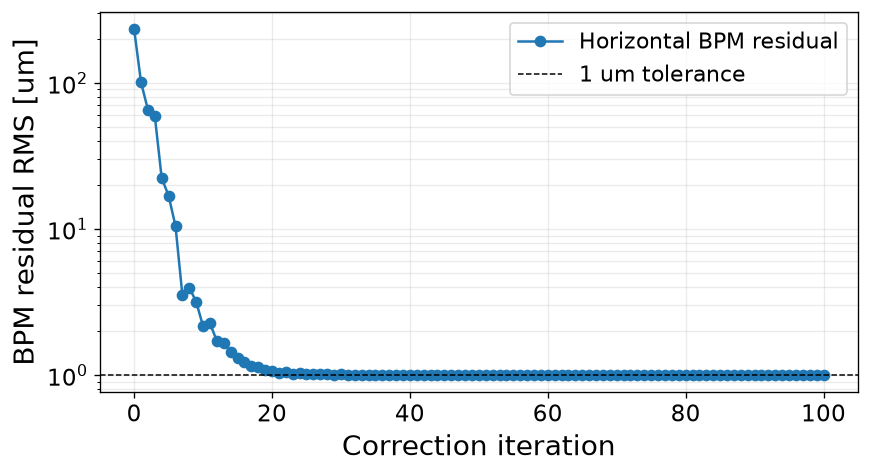

In [144]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(
    trim_correction_history['iteration'],
    1e6 * trim_correction_history['x_rms_m'],
    'o-',
    label='Horizontal BPM residual',
)
ax.axhline(1.0, color='black', ls='--', lw=0.9, label='1 um tolerance')
ax.set_xlabel('Correction iteration')
ax.set_ylabel('BPM residual RMS [um]')
ax.grid(alpha=0.25, which='both')
ax.legend()
fig.tight_layout()
plt.show()

In [145]:
get_rf_phase(line)
rf_phase_corrected = read_rf_phase(line)
rf_phase_corrected

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103077,-63.201665
1,rf800.0,4020.0,-1.102972,-63.195654
2,rf800.1,4020.0,-1.102972,-63.195654
3,rf400.1,990.0,-1.103077,-63.201665


In [146]:
twiss_after_dipole_trims = line.twiss(
    eneloss_and_damping=True,
    radiation_analysis=True,
)

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


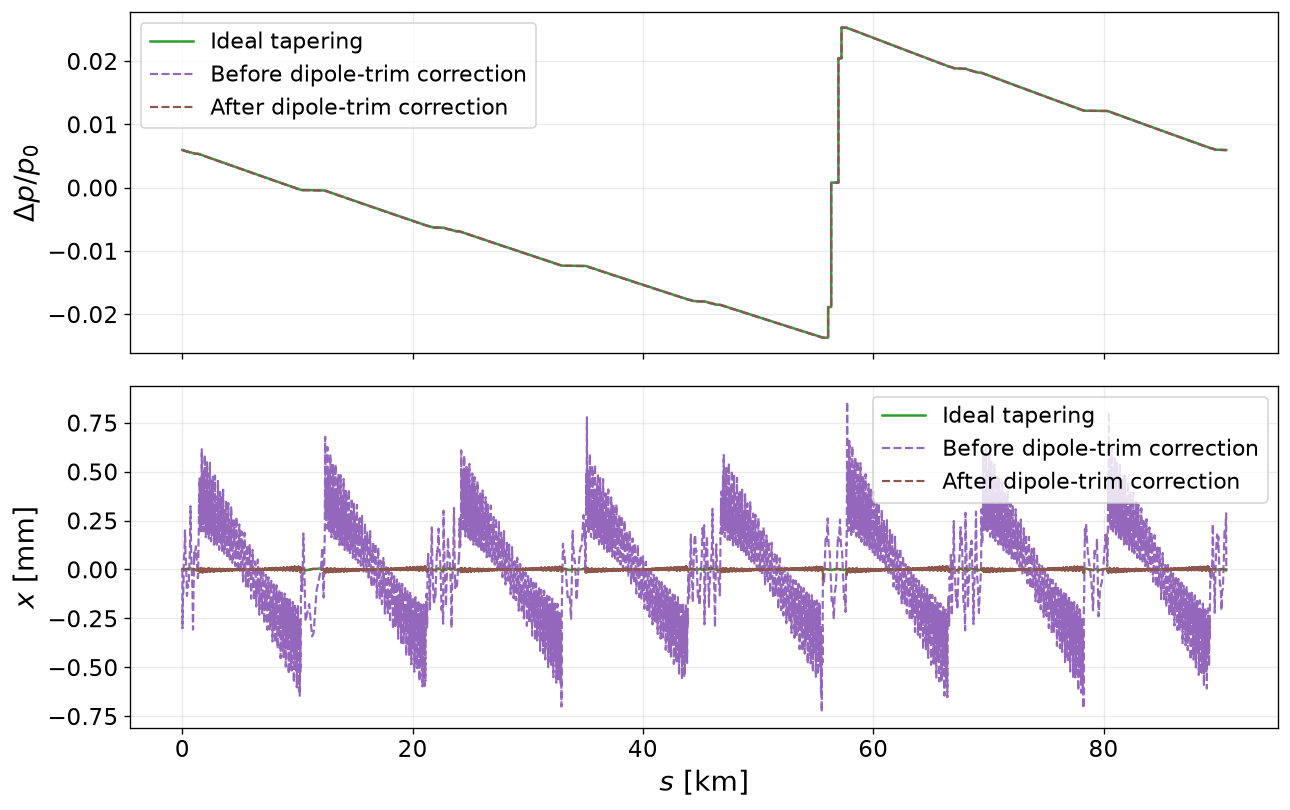

In [147]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[0].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[0].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.delta,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[0].set_ylabel(r"$\Delta p/p_0$")
axes[0].legend()

axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[1].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[1].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.x * 1e3,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[1].set_xlabel(r"$s$ [km]")
axes[1].set_ylabel(r"$x$ [mm]")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [148]:
if SAVE_STEPS_TWISS:
    io_ckpt.write_twiss(
            f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr_Sr_DipTrim{TRIM_POSITION_IN_CELL}", 
            twiss_after_dipole_trims, 
            ident=f"D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr_Sr_DipTrim{TRIM_POSITION_IN_CELL}"
        )
    trim_table = stages.corrections_table(line, trim_dipole_names, trim_kicks_rad, family='dip_trim', plane="x")
    io_ckpt.write_corrections(f"results/D{N_DIPOLE_CIRCUITS_PER_SECTOR}_Qr_Sr_DipTrim{TRIM_POSITION_IN_CELL }", trim_table)
    

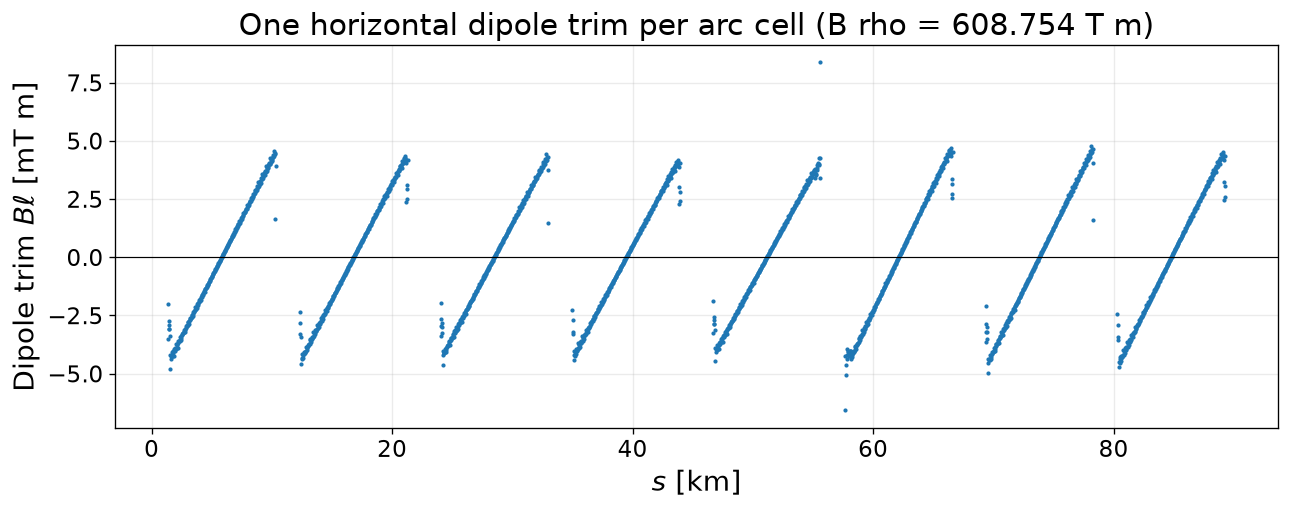

Trims: 2262
RMS kick = 4.23491 urad
Max |kick| = 13.7411 urad
RMS |B*l| = 2.57802 mT m
Max |B*l| = 8.36497 mT m


In [149]:
p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
charge_number = abs(float(line.particle_ref.q0))
magnetic_rigidity_Tm = p0c_GeV / (0.299792458 * charge_number)
trim_integrated_field_mTm = trim_kicks_rad * magnetic_rigidity_Tm * 1e3
trim_s_km = trim_layout['s_km'].to_numpy(float)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(trim_s_km, trim_integrated_field_mTm, '.', ms=3)
ax.axhline(0.0, color='black', lw=0.7)
ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel(r'Dipole trim $B\ell$ [mT m]')
ax.grid(alpha=0.25)
ax.set_title(
    f'One horizontal dipole trim per arc cell '
    f'(B rho = {magnetic_rigidity_Tm:.3f} T m)'
)
fig.tight_layout()
plt.show()

print(f'Trims: {len(trim_kicks_rad)}')
print(f'RMS kick = {1e6 * np.sqrt(np.mean(trim_kicks_rad**2)):.6g} urad')
print(f'Max |kick| = {1e6 * np.max(np.abs(trim_kicks_rad)):.6g} urad')
print(f'RMS |B*l| = {np.sqrt(np.mean(trim_integrated_field_mTm**2)):.6g} mT m')
print(f'Max |B*l| = {np.max(np.abs(trim_integrated_field_mTm)):.6g} mT m')

# Summary

In [150]:
twiss_scenario_2_before_correction = twiss_quad_sext
twiss_scenario_2_after_correction = twiss_after_dipole_trims

In [151]:
beta_beating_x = (
    twiss_scenario_2_after_correction.betx - twiss_ideal.betx
) / twiss_ideal.betx

beta_beating_y = (
    twiss_scenario_2_after_correction.bety - twiss_ideal.bety
) / twiss_ideal.bety


diagnostics = pd.DataFrame({
    "name": np.asarray(twiss_scenario_2_after_correction.name, dtype=str),
    "s_km": np.asarray(twiss_scenario_2_after_correction.s) / 1e3,
    "beta_beating_x": beta_beating_x,
    "beta_beating_y": beta_beating_y,
    "orbit_x_mm": (
        twiss_scenario_2_after_correction.x - twiss_ideal.x
    ) * 1e3,
})


print("Largest horizontal beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_x))[-15:]
    ].sort_values(
        "beta_beating_x",
        key=np.abs,
        ascending=False,
    )
)


print("Largest vertical beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_y))[-15:]
    ].sort_values(
        "beta_beating_y",
        key=np.abs,
        ascending=False,
    )
)

Largest horizontal beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
20593,||drift_36::2438,62.245156,0.011043,0.002254,1.280546e-04
20594,qd1a.595,62.245306,0.011034,0.002235,1.187147e-04
28105,||drift_78::806,84.910220,0.010573,0.001390,1.198462e-04
28106,qd1a.811,84.910370,0.010564,0.001371,1.111076e-04
20595,||drift_34::893,62.247166,0.010524,0.002103,5.971070e-06
20596,bpm_qd1a.595,62.247266,0.010476,0.002102,-2.437437e-09
20597,hcor_qd1a.595,62.247266,0.010476,0.002102,-2.437437e-09
20599,sd1a.281,62.247266,0.010476,0.002102,-2.437437e-09
20598,vcor_qd1a.595,62.247266,0.010476,0.002102,-2.437437e-09
24555,qd1a.703,73.934770,0.010324,0.001193,1.152248e-04


Largest vertical beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
22589,||drift_78::103,68.105533,0.001039,-0.010855,-7.310611e-04
22590,qd4r.3,68.105683,0.000982,-0.010340,-7.328812e-04
20879,||drift_36::2485,62.983716,-0.006661,0.007745,-1.462277e-03
20880,mbd.4638,62.983866,-0.006666,0.007741,-1.531981e-03
20703,qf2a.587,62.532736,-0.008249,0.007727,6.557529e-04
20702,||drift_36::2456,62.532586,-0.008245,0.007724,6.870191e-04
20582,||drift_34::892,62.215696,0.000356,0.007548,4.656499e-06
20583,bpm_qf2a.583,62.215796,0.000377,0.007541,2.725341e-09
20586,sf1a.281,62.215796,0.000377,0.007541,2.725341e-09
20584,hcor_qf2a.583,62.215796,0.000377,0.007541,2.725341e-09


In [152]:
def twiss_scalar(twiss, *candidate_names):
    for name in candidate_names:
        value = getattr(twiss, name, None)
        if value is not None:
            array = np.asarray(value)
            if array.size:
                return float(array.reshape(-1)[0])
    return np.nan

def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.nanmean(values**2)))

def max_abs(values):
    return float(np.nanmax(np.abs(np.asarray(values, dtype=float))))

def percent_change(value, reference):
    if not np.isfinite(reference) or reference == 0:
        return np.nan
    return 100.0 * (value/reference - 1.0)

def complete_optics_summary(twiss, reference):
    betx_beating = (twiss.betx-reference.betx)/reference.betx
    bety_beating = (twiss.bety-reference.bety)/reference.bety
    delta_x = twiss.x-reference.x
    delta_y = twiss.y-reference.y
    delta_dx = twiss.dx-reference.dx
    delta_dy = twiss.dy-reference.dy

    emit_x = twiss_scalar(twiss, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y = twiss_scalar(twiss, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')
    emit_x_ref = twiss_scalar(reference, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y_ref = twiss_scalar(reference, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')

    return {
        'Horizontal tune Qx': twiss_scalar(twiss, 'qx'),
        'Vertical tune Qy': twiss_scalar(twiss, 'qy'),
        'Horizontal tune shift': twiss_scalar(twiss, 'qx')-twiss_scalar(reference, 'qx'),
        'Vertical tune shift': twiss_scalar(twiss, 'qy')-twiss_scalar(reference, 'qy'),
        'Horizontal chromaticity Qx_prime': twiss_scalar(twiss, 'dqx'),
        'Vertical chromaticity Qy_prime': twiss_scalar(twiss, 'dqy'),
        'Minimum tune separation |C-|': twiss_scalar(twiss, 'c_minus'),
        'Synchrotron tune Qs': twiss_scalar(twiss, 'qs'),
        'RMS beta-x beating [%]': 100*rms(betx_beating),
        'Maximum beta-x beating [%]': 100*max_abs(betx_beating),
        'RMS beta-y beating [%]': 100*rms(bety_beating),
        'Maximum beta-y beating [%]': 100*max_abs(bety_beating),
        'RMS horizontal-orbit residual [um]': 1e6*rms(delta_x),
        'Maximum horizontal-orbit residual [um]': 1e6*max_abs(delta_x),
        'RMS vertical-orbit residual [um]': 1e6*rms(delta_y),
        'Maximum vertical-orbit residual [um]': 1e6*max_abs(delta_y),
        'RMS horizontal-dispersion residual [mm]': 1e3*rms(delta_dx),
        'Maximum horizontal-dispersion residual [mm]': 1e3*max_abs(delta_dx),
        'RMS vertical-dispersion residual [mm]': 1e3*rms(delta_dy),
        'Maximum vertical-dispersion residual [mm]': 1e3*max_abs(delta_dy),
        'Equilibrium horizontal emittance [nm]': 1e9*emit_x,
        'Horizontal emittance change [%]': percent_change(emit_x, emit_x_ref),
        'Equilibrium vertical emittance [pm]': 1e12*emit_y,
        'Vertical emittance change [%]': percent_change(emit_y, emit_y_ref),
        'Equilibrium longitudinal emittance [um]': 1e6*twiss_scalar(
            twiss, 'eq_gemitt_zeta', 'rad_int_eq_gemitt_zeta'),
        'Equilibrium momentum spread [%]': 100*twiss_scalar(
            twiss, 'eq_sigma_delta', 'rad_int_sigma_delta'),
        'Equilibrium bunch length [mm]': 1e3*twiss_scalar(
            twiss, 'eq_sigma_zeta', 'eq_sigma_z', 'rad_int_sigma_zeta'),
        'Energy loss per turn [GeV]': 1e-9*twiss_scalar(
            twiss, 'eneloss_turn', 'rad_int_energy_loss'),
        'Momentum compaction factor': twiss_scalar(
            twiss, 'momentum_compaction_factor'),
        'Slip factor': twiss_scalar(twiss, 'slip_factor'),
    }

optics_comparison = pd.DataFrame({
    'Ideal tapering': complete_optics_summary(twiss_ideal, twiss_ideal),
    'Scenario 2 before correction': complete_optics_summary(
        twiss_scenario_2_before_correction, twiss_ideal),
    'Scenario 2 after dipole-trim correction': complete_optics_summary(
        twiss_after_dipole_trims, twiss_ideal),
})
pd.set_option('display.max_rows', None)
display(optics_comparison)

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/table.py:317: FutureWarning: `eneloss_turn` is deprecated, use `energy_loss` instead. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn(depr_fields[name], FutureWarning)


,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Horizontal tune Qx,3.461316e+02,3.461390e+02,3.461337e+02
Vertical tune Qy,2.622813e+02,2.622783e+02,2.622831e+02
Horizontal tune shift,0.000000e+00,7.428458e-03,2.122084e-03
Vertical tune shift,0.000000e+00,-2.940651e-03,1.768605e-03
Horizontal chromaticity Qx_prime,4.605619e+00,4.539041e+00,4.589581e+00
Vertical chromaticity Qy_prime,3.873637e+00,3.722502e+00,3.845828e+00
Minimum tune separation |C-|,1.672017e-10,1.030265e-10,3.831399e-10
Synchrotron tune Qs,9.183689e-02,9.181013e-02,9.185347e-02
RMS beta-x beating [%],0.000000e+00,2.327356e+00,3.515944e-01
Maximum beta-x beating [%],0.000000e+00,6.357464e+00,1.104251e+00


In [153]:
# Focused equilibrium-emittance comparison.
emittance_rows = [
    'Equilibrium horizontal emittance [nm]',
    'Horizontal emittance change [%]',
    'Equilibrium vertical emittance [pm]',
    'Vertical emittance change [%]',
    'Equilibrium momentum spread [%]',
    'Equilibrium bunch length [mm]',
]
display(optics_comparison.loc[emittance_rows])

,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Equilibrium horizontal emittance [nm],2.189252,2.191487,2.188833
Horizontal emittance change [%],0.000000,0.102070,-0.019146
Equilibrium vertical emittance [pm],0.063790,0.063563,0.063892
Vertical emittance change [%],0.000000,-0.356513,0.160069
Equilibrium momentum spread [%],NaN,NaN,NaN
Equilibrium bunch length [mm],NaN,NaN,NaN


# Horizontal optics comparison for every case

The dispersion is compared directly with the ideal lattice. The beta beating is shown as the relative difference from the ideal horizontal beta function.

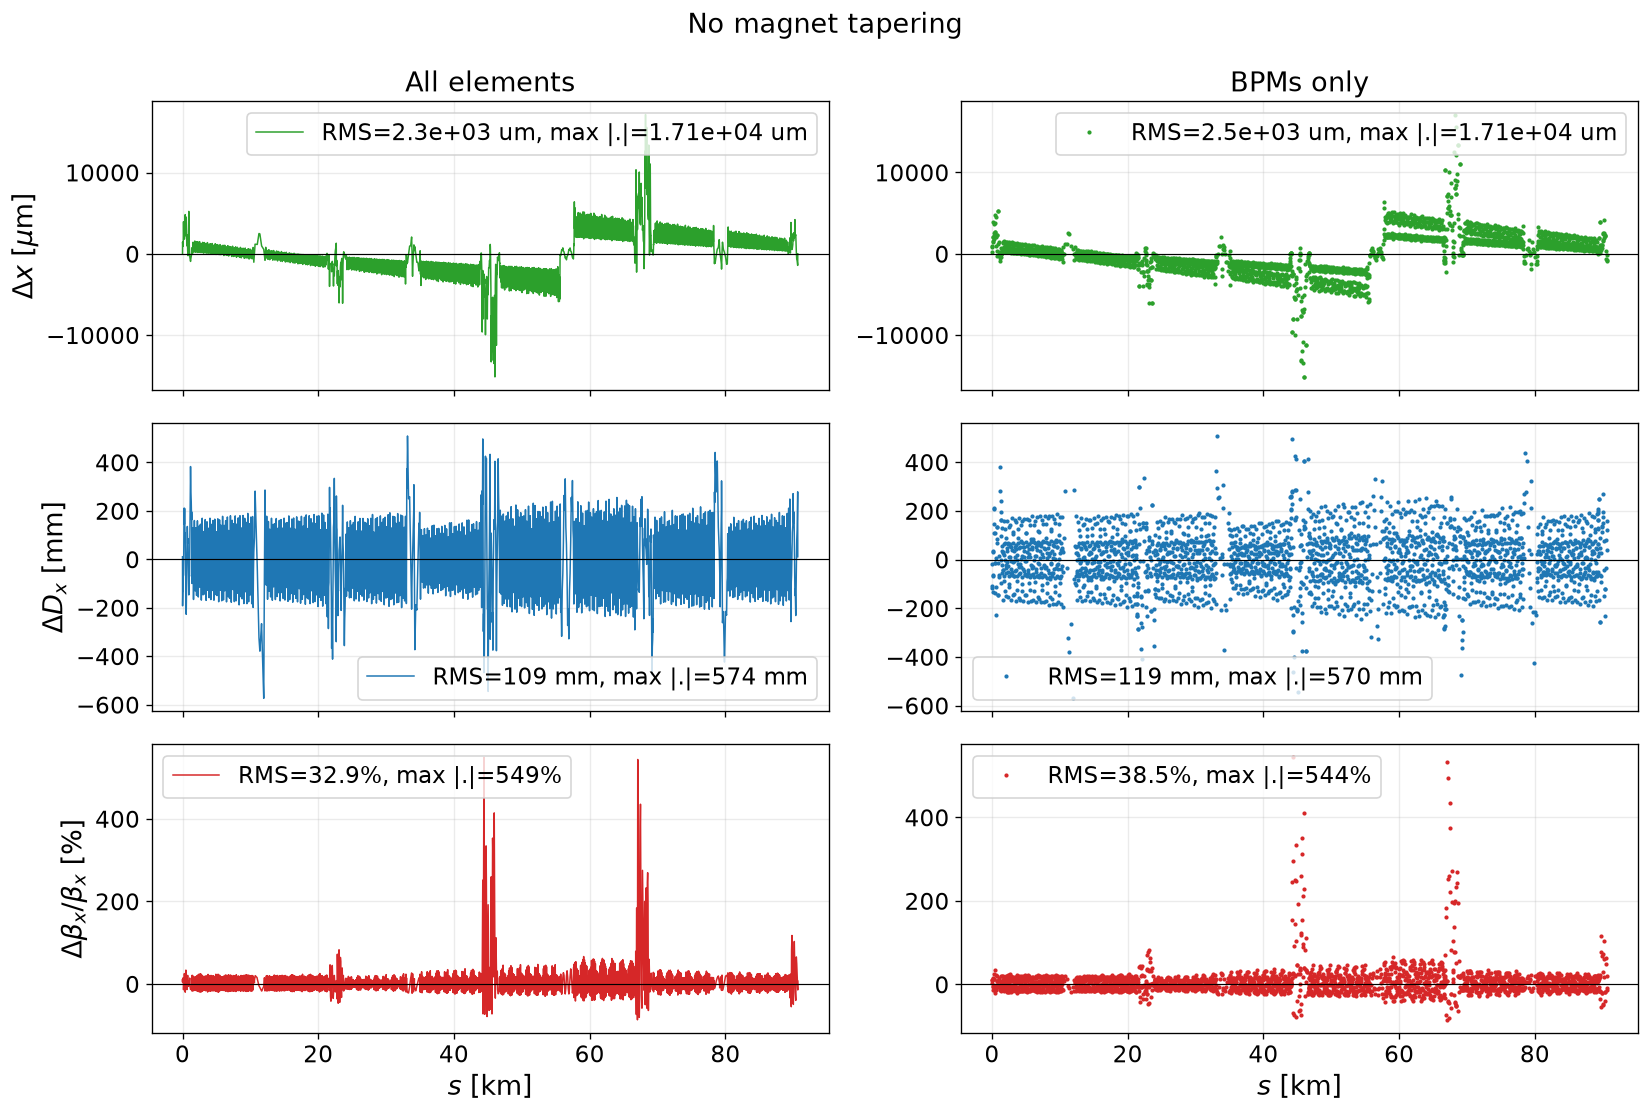

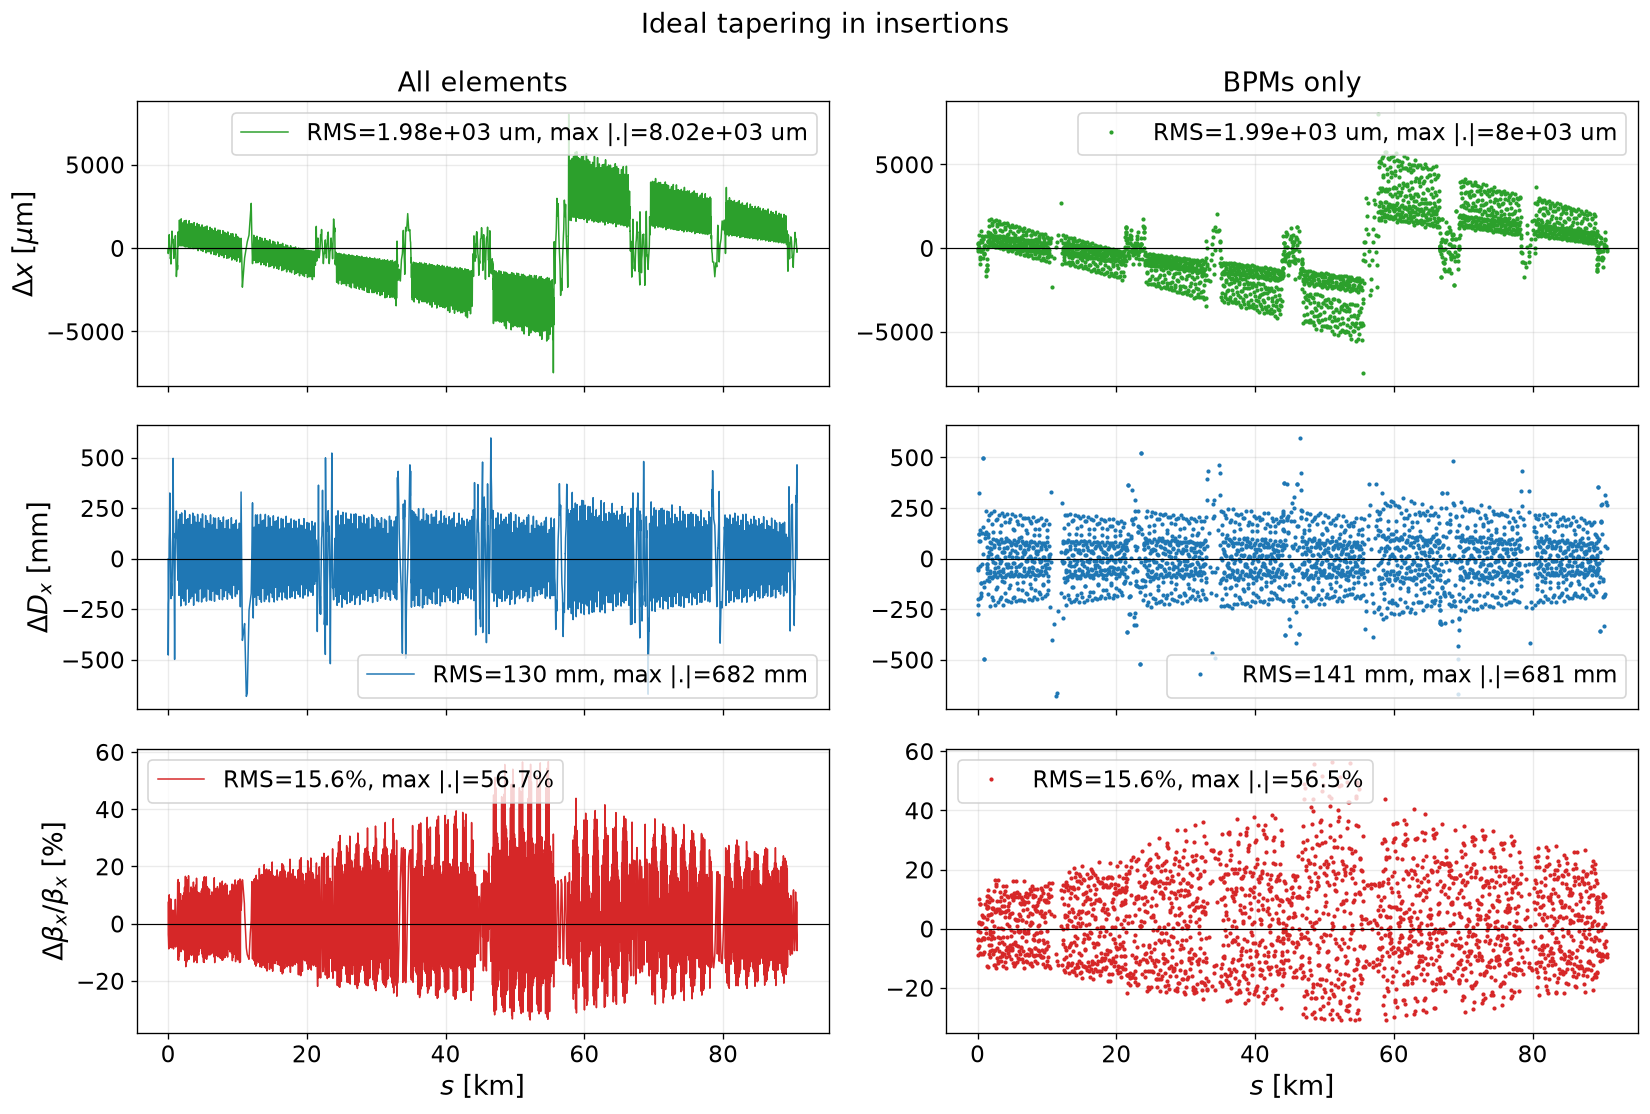

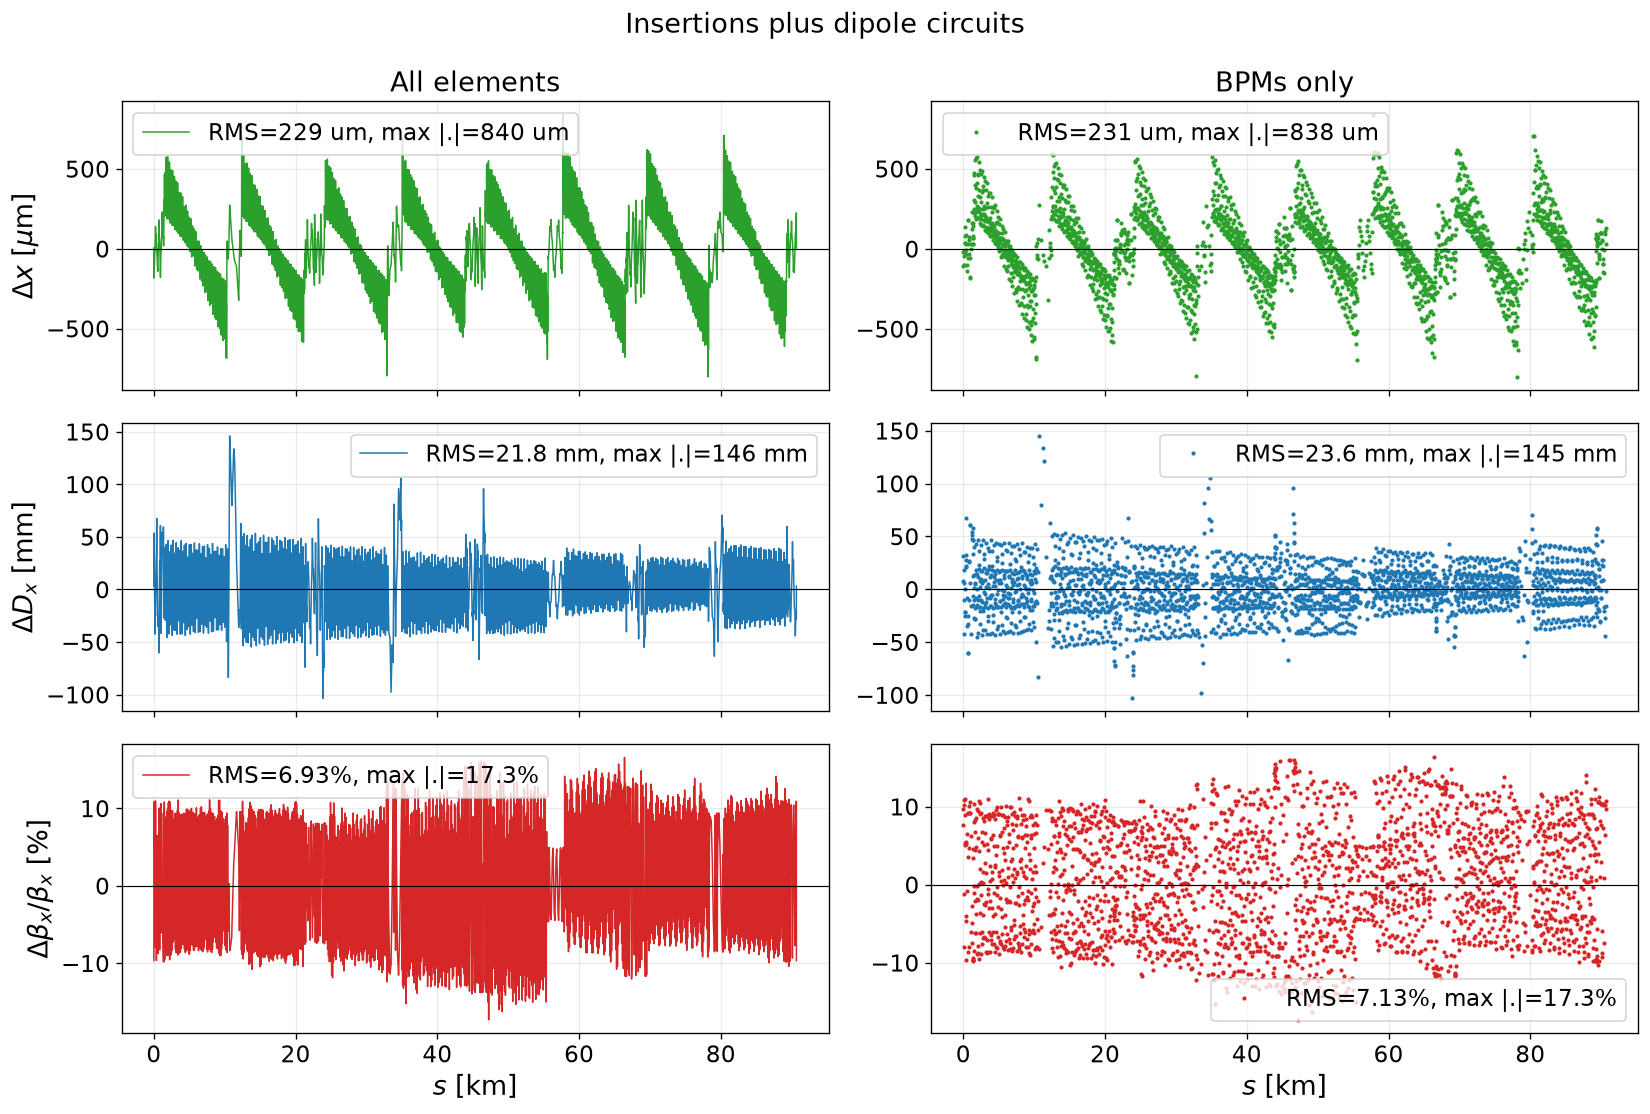

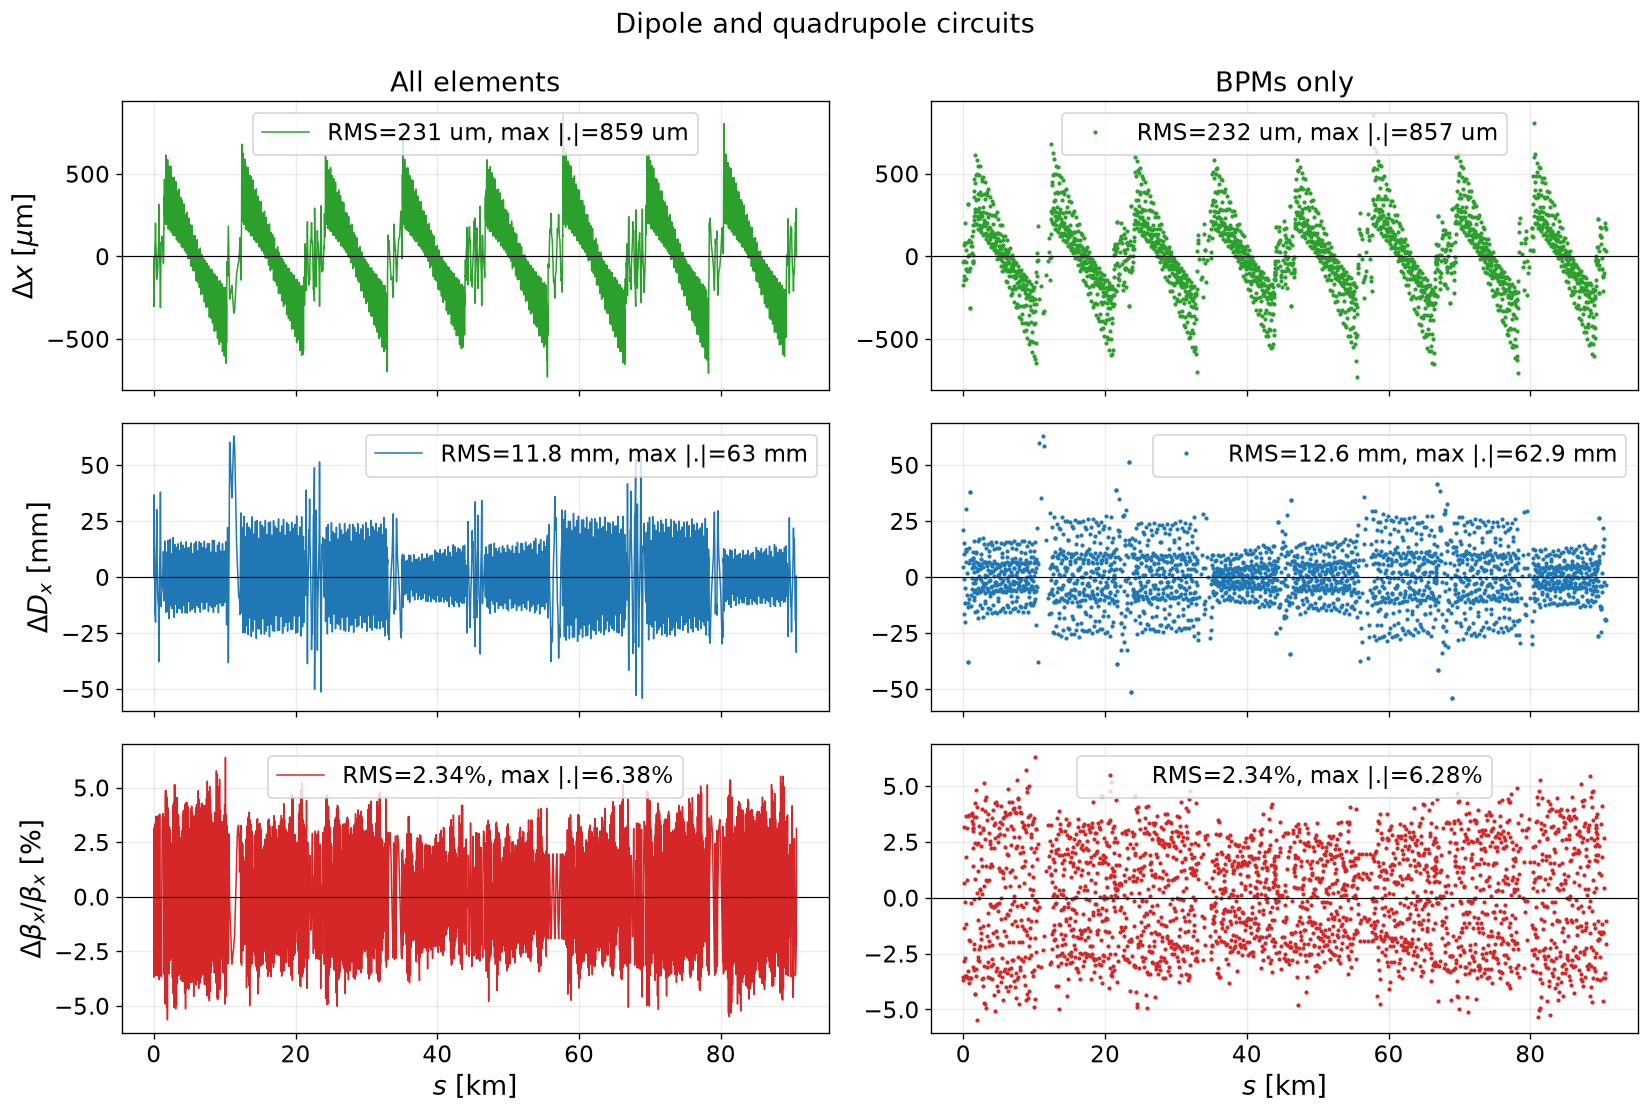

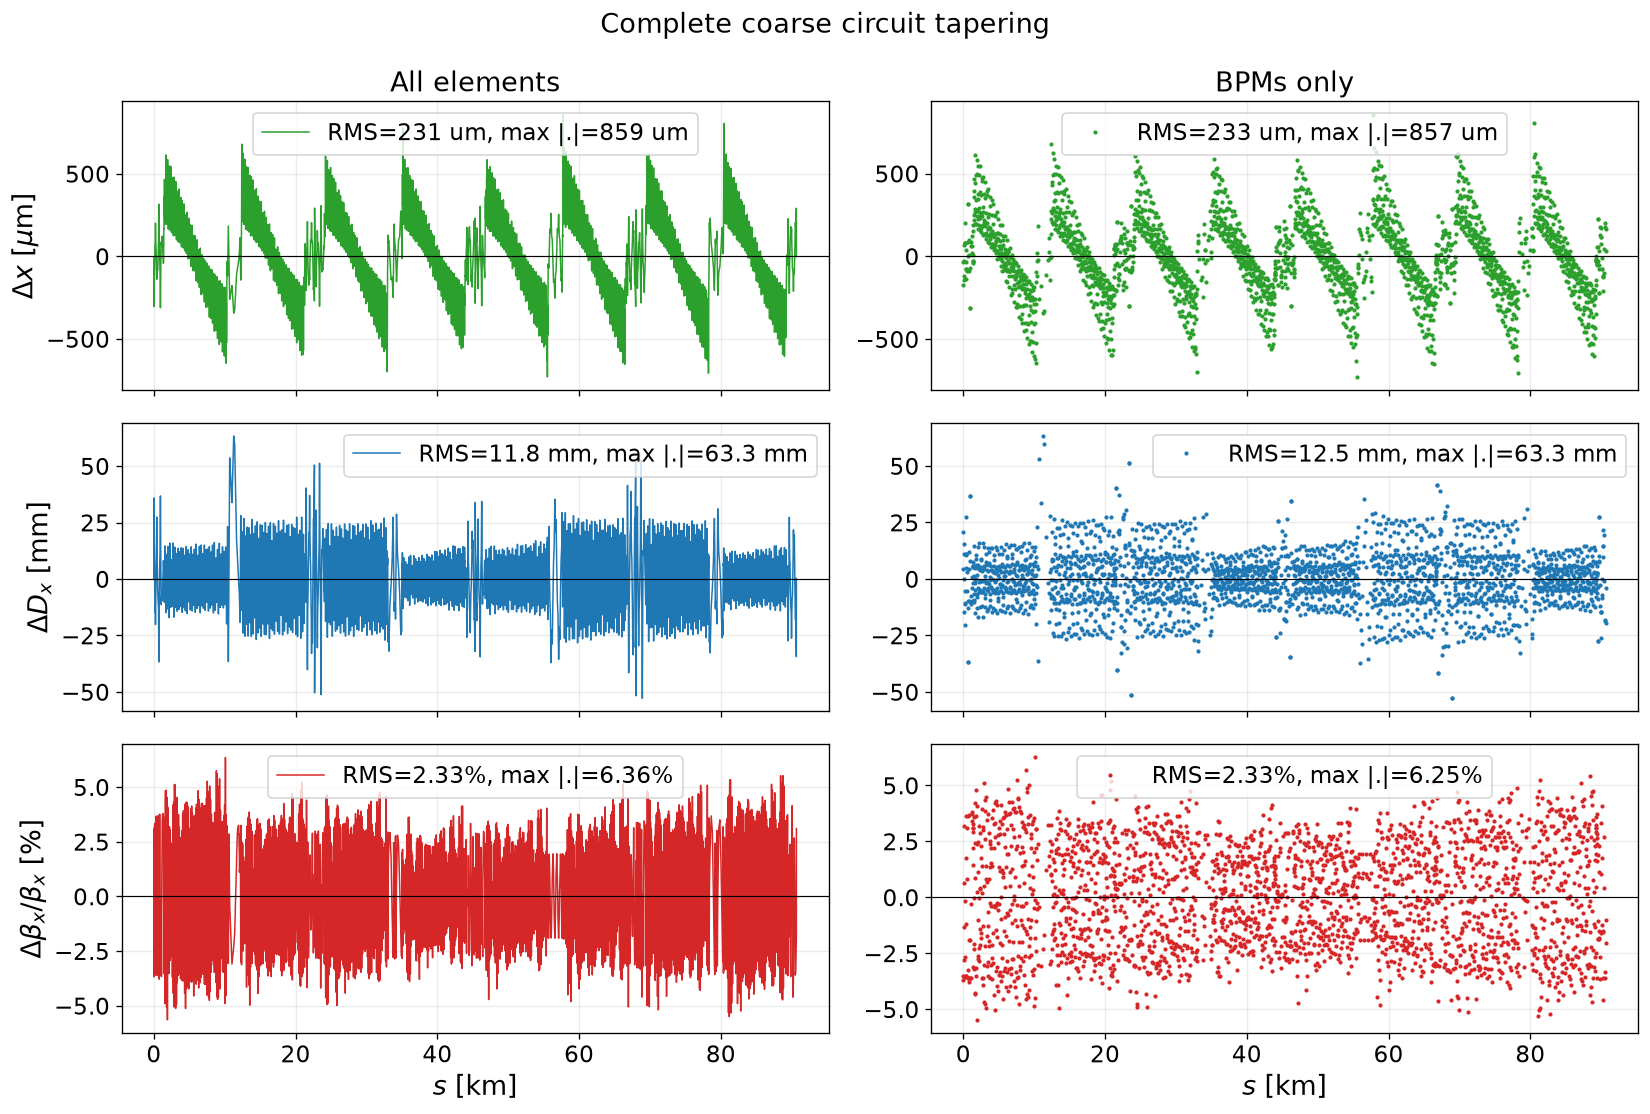

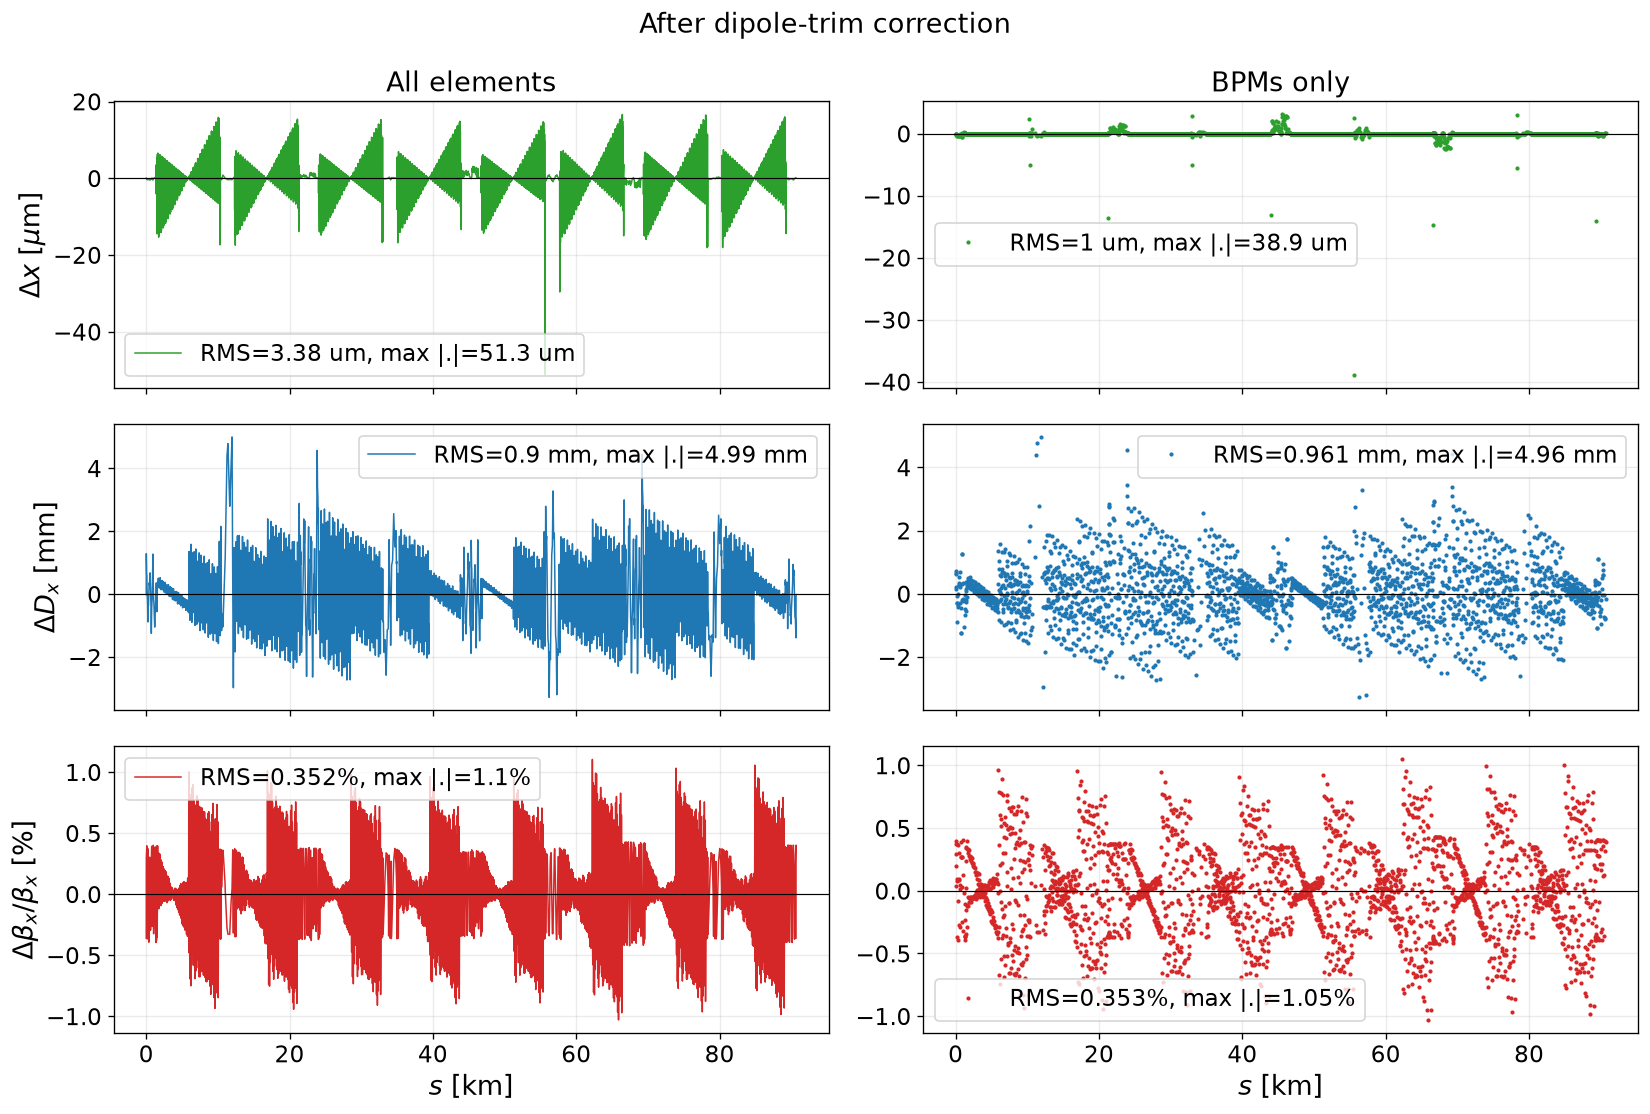

In [154]:
def plot_horizontal_optics_case(twiss_case, reference, label, bpm_names):
    bpm_names = list(np.asarray(bpm_names, dtype=str))

    # All Twiss locations
    s_all_km = np.asarray(reference.s, dtype=float) / 1e3
    delta_orbit_x_all_um = 1e6 * (
        np.asarray(twiss_case.x, dtype=float)
        - np.asarray(reference.x, dtype=float)
    )
    delta_dispersion_all_mm = 1e3 * (
        np.asarray(twiss_case.dx, dtype=float)
        - np.asarray(reference.dx, dtype=float)
    )
    beta_beating_all_percent = 100.0 * (
        np.asarray(twiss_case.betx, dtype=float)
        / np.asarray(reference.betx, dtype=float) - 1.0
    )

    # BPM locations only. Obtain the indices independently from each table.
    reference_bpm_indices = reference.rows.indices[bpm_names]
    case_bpm_indices = twiss_case.rows.indices[bpm_names]
    s_bpm_km = np.asarray(reference.s[reference_bpm_indices], dtype=float) / 1e3
    delta_orbit_x_bpm_um = 1e6 * (
        np.asarray(twiss_case.x[case_bpm_indices], dtype=float)
        - np.asarray(reference.x[reference_bpm_indices], dtype=float)
    )
    delta_dispersion_bpm_mm = 1e3 * (
        np.asarray(twiss_case.dx[case_bpm_indices], dtype=float)
        - np.asarray(reference.dx[reference_bpm_indices], dtype=float)
    )
    beta_beating_bpm_percent = 100.0 * (
        np.asarray(twiss_case.betx[case_bpm_indices], dtype=float)
        / np.asarray(reference.betx[reference_bpm_indices], dtype=float) - 1.0
    )

    def statistics(values):
        values = np.asarray(values, dtype=float)
        return np.sqrt(np.nanmean(values**2)), np.nanmax(np.abs(values))

    orbit_all_rms, orbit_all_max = statistics(delta_orbit_x_all_um)
    orbit_bpm_rms, orbit_bpm_max = statistics(delta_orbit_x_bpm_um)
    dx_all_rms, dx_all_max = statistics(delta_dispersion_all_mm)
    dx_bpm_rms, dx_bpm_max = statistics(delta_dispersion_bpm_mm)
    betx_all_rms, betx_all_max = statistics(beta_beating_all_percent)
    betx_bpm_rms, betx_bpm_max = statistics(beta_beating_bpm_percent)

    fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex='col')
    axes[0, 0].plot(s_all_km, delta_orbit_x_all_um, color='tab:green', lw=0.9,
                    label=f'RMS={orbit_all_rms:.3g} um, max |.|={orbit_all_max:.3g} um')
    axes[0, 1].plot(s_bpm_km, delta_orbit_x_bpm_um, '.', color='tab:green', ms=3,
                    label=f'RMS={orbit_bpm_rms:.3g} um, max |.|={orbit_bpm_max:.3g} um')
    axes[1, 0].plot(s_all_km, delta_dispersion_all_mm, color='tab:blue', lw=0.9,
                    label=f'RMS={dx_all_rms:.3g} mm, max |.|={dx_all_max:.3g} mm')
    axes[1, 1].plot(s_bpm_km, delta_dispersion_bpm_mm, '.', color='tab:blue', ms=3,
                    label=f'RMS={dx_bpm_rms:.3g} mm, max |.|={dx_bpm_max:.3g} mm')
    axes[2, 0].plot(s_all_km, beta_beating_all_percent, color='tab:red', lw=0.9,
                    label=f'RMS={betx_all_rms:.3g}%, max |.|={betx_all_max:.3g}%')
    axes[2, 1].plot(s_bpm_km, beta_beating_bpm_percent, '.', color='tab:red', ms=3,
                    label=f'RMS={betx_bpm_rms:.3g}%, max |.|={betx_bpm_max:.3g}%')

    axes[0, 0].set_title('All elements', fontsize=16)
    axes[0, 1].set_title('BPMs only', fontsize=16)
    axes[0, 0].set_ylabel(r'$\Delta x$ [$\mu$m]', fontsize=16)
    axes[1, 0].set_ylabel(r'$\Delta D_x$ [mm]', fontsize=16)
    axes[2, 0].set_ylabel(r'$\Delta\beta_x/\beta_x$ [%]', fontsize=16)
    axes[2, 0].set_xlabel(r'$s$ [km]', fontsize=16)
    axes[2, 1].set_xlabel(r'$s$ [km]', fontsize=16)

    for ax in axes.flat:
        ax.axhline(0.0, color='black', lw=0.7)
        ax.grid(alpha=0.25)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.legend(fontsize=14)

    fig.suptitle(label, fontsize=16)
    fig.tight_layout()
    plt.show()

case_twiss_tables = {
    'No magnet tapering': tw_no_taper,
    'Ideal tapering in insertions': twiss_insertion_taper,
    'Insertions plus dipole circuits': twiss_dipole,
    'Dipole and quadrupole circuits': twiss_quad,
    'Complete coarse circuit tapering': twiss_quad_sext,
    'After dipole-trim correction': twiss_after_dipole_trims,
}

for case_label, case_twiss in case_twiss_tables.items():
    plot_horizontal_optics_case(case_twiss, twiss_ideal, case_label, monitor_names)

No tapering -> Dipole circuits (D1) -> + quadrupoles -> + sextupoles -> + dipole trims (pos. 1)
excluded: end_arc_start_ds_iph -> end_ds_start_arc_iph (55.17 - 58.15 km)


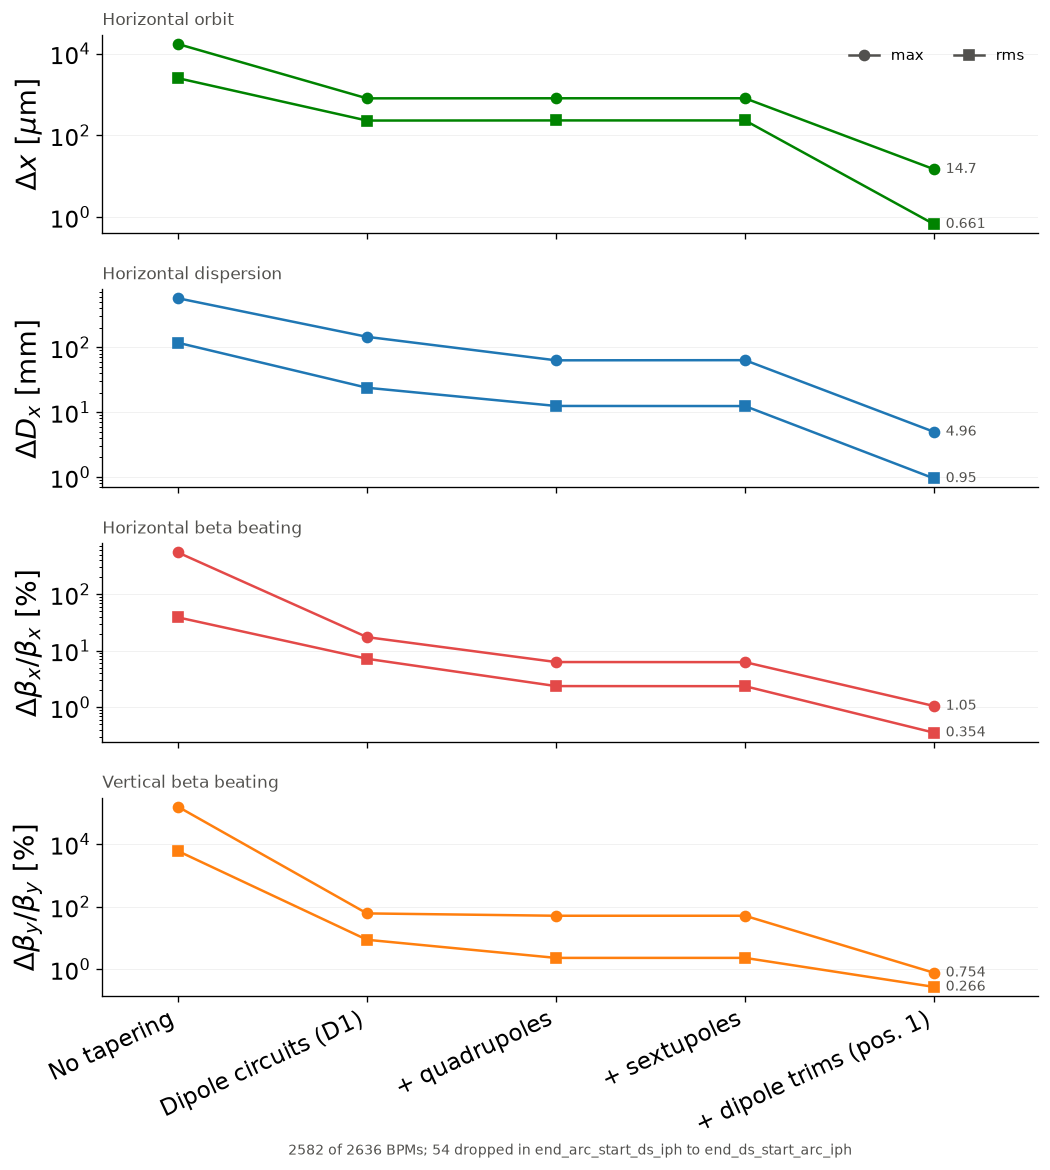

Horizontal orbit           Horizontal dispersion  \
                                     max       rms                   max   
stage                                                                      
No tapering                    17124.842  2495.324               570.148   
Dipole circuits (D1)             799.769   228.601               144.986   
+ quadrupoles                    802.919   230.284                62.935   
+ sextupoles                     803.342   230.320                63.287   
+ dipole trims (pos. 1)           14.676     0.661                 4.962   

                                 Horizontal beta beating          \
                             rms                     max     rms   
stage                                                              
No tapering              117.490                 543.746  38.743   
Dipole circuits (D1)      23.784                  17.319   7.169   
+ quadrupoles             12.457                   6.279   2.358   
+ sextupoles              12.410                   6.252   2.349   
+ dipole trims (pos. 1)    0.950                   1.048   0.354   

                        Vertical beta beating            
                                          max       rms  
stage                                                    
No tapering                        156969.239  5980.465  
Dipole circuits (D1)                   60.156     8.617  
+ quadrupoles                          50.639     2.264  
+ sextupoles                           50.621     2.266  
+ dipole trims (pos. 1)                 0.754     0.266

In [155]:
# Stage progression, read straight from the twiss tables computed above.
#
# Same figure as the one in results/summary.ipynb, but nothing is loaded back
# from results/: every point is one of the twiss tables this notebook just
# produced, so the plot follows this run rather than the checkpoints on disk.

# The chain, in order: (tick label, twiss, is the step a correction).
# Add ("Insertions only", twiss_insertion_taper, False) after the first entry
# to keep the intermediate step of the walkthrough. The ideal-quadrupole cases
# of step 3 (twiss_idealquad, twiss_idealquad_sext) are a side comparison and
# not a step of this chain, so they are left out.
STAGE_TWISS = [
    ("No tapering", tw_no_taper, False),
    (f"Dipole circuits (D{N_DIPOLE_CIRCUITS_PER_SECTOR})", twiss_dipole, False),
    ("+ quadrupoles", twiss_quad, False),
    ("+ sextupoles", twiss_quad_sext, False),
    (f"+ dipole trims (pos. {TRIM_POSITION_IN_CELL})", twiss_after_dipole_trims, True),
]

# Residuals against the ideal lattice: (title, axis label, column, scale, relative)
RESIDUALS = (
    ("Horizontal orbit", r"$\Delta x$ [$\mu$m]", "x", 1e6, False),
    ("Horizontal dispersion", r"$\Delta D_x$ [mm]", "dx", 1e3, False),
    ("Horizontal beta beating", r"$\Delta\beta_x/\beta_x$ [%]", "betx", 100.0, True),
    ("Vertical beta beating", r"$\Delta\beta_y/\beta_y$ [%]", "bety", 100.0, True),
)

# Colour carries the residual, one hue per panel and the same hue for both
# statistics in it; max and rms are told apart by marker shape alone.
RESIDUAL_COLORS = {
    "Horizontal orbit": "#008300",  # green
    "Horizontal dispersion": "C0",  # matplotlib's default blue
    "Horizontal beta beating": "#e34948",  # red
    "Vertical beta beating": "#ff7f0e",  # orange
}
STAT_MARKERS = {"max": "o", "rms": "s"}
INK_MUTED = "#52514e"
FALLBACK_COLOR = "#52514e"

# Stretches of the ring left out of the statistics, as (first marker, last
# marker) pairs read from the lattice's own markers. The dispersion suppressors
# and the straight around point H carry the RF and the magnets under
# discussion, and they would otherwise set the maximum of every panel on their
# own. Set this to () to measure over the whole ring again.
EXCLUDED_SPANS = (("end_arc_start_ds_iph", "end_ds_start_arc_iph"),)


def measured_rows(twiss, elements=None, excluded=EXCLUDED_SPANS):
    """Rows a residual is measured over: the BPMs, minus the excluded spans.

    Read from each table on its own rather than once from the reference, so the
    stages are lined up by element name and not by position in the array. A
    span whose first marker sits after its last one wraps past the end of the
    ring, the way the region selection earlier in this notebook does.
    """
    names = np.asarray(twiss.name, dtype=str)
    s = np.asarray(twiss.s, dtype=float)

    if elements is None:
        keep = np.fromiter(
            (name.startswith("bpm") for name in names), bool, len(names)
        )
    else:
        keep = np.isin(names, np.asarray(elements, dtype=str))

    s_by_name = dict(zip(names, s))
    if excluded is not None:
        for first_marker, last_marker in excluded:
            start = s_by_name[first_marker]
            end = s_by_name[last_marker]
            inside = (s >= start) & (s < end) if start <= end else (s >= start) | (s < end)
            keep &= ~inside

    return np.flatnonzero(keep)


def residual_table(
    stages, reference, elements=None, residuals=RESIDUALS, excluded=EXCLUDED_SPANS
):
    """Max and rms of each residual against ``reference``, one row per stage.

    Measured at the BPMs by default: that is where the orbit is actually known,
    and it keeps the maximum from being set by a single interaction-region
    element no monitor can see. ``elements`` takes a list of element names to
    measure somewhere else instead; ``excluded`` drops stretches of the ring
    from whatever was selected.
    """

    def rows_of(twiss):
        rows = measured_rows(twiss, elements, excluded)
        if len(rows) != len(reference_rows):
            raise ValueError(
                f"{len(rows)} measured elements against {len(reference_rows)} in "
                "the reference: the stages are not the same lattice."
            )
        return rows

    reference_rows = measured_rows(reference, elements, excluded)

    columns = {}
    for title, _, column, scale, relative in residuals:
        baseline = np.asarray(getattr(reference, column), dtype=float)[reference_rows]
        peaks, rmss = [], []
        for _, twiss, _ in stages:
            values = np.asarray(getattr(twiss, column), dtype=float)[rows_of(twiss)]
            residual = values - baseline
            if relative:
                residual = residual / baseline
            residual = residual * scale
            peaks.append(np.max(np.abs(residual)))
            rmss.append(np.sqrt(np.mean(residual**2)))
        columns[(title, "max")] = peaks
        columns[(title, "rms")] = rmss

    return pd.DataFrame(
        columns,
        index=pd.Index([label for label, _, _ in stages], name="stage"),
    )


def plot_stage_progression(
    stages, reference, elements=None, residuals=RESIDUALS, excluded=EXCLUDED_SPANS
):
    """One panel per residual, max and rms across the stage progression."""
    table = residual_table(stages, reference, elements, residuals, excluded)
    ticks = [label for label, _, _ in stages]
    positions = np.arange(len(stages))

    fig, axes = plt.subplots(
        len(residuals), 1, figsize=(9, 2.5 * len(residuals)), sharex=True
    )
    for ax, (title, ylabel, *_) in zip(np.atleast_1d(axes), residuals):
        color = RESIDUAL_COLORS.get(title, FALLBACK_COLOR)
        for stat, marker in STAT_MARKERS.items():
            values = table[(title, stat)].to_numpy()
            ax.plot(
                positions, values, lw=1.5, color=color, marker=marker, ms=6, label=stat
            )
            # The endpoint value only -- a number on every marker would bury it.
            ax.annotate(
                f"{values[-1]:.3g}",
                (positions[-1], values[-1]),
                xytext=(7, 0),
                textcoords="offset points",
                va="center",
                fontsize=8.5,
                color=INK_MUTED,
            )
        # What the correction bought, which is the reason for the last point.
        # Only said when the chain actually ends on one.
        peak = table[(title, "max")].to_numpy()
        gained = (
            f"    (correction: x{peak[-2] / peak[-1]:.0f} on the maximum)"
            if len(stages) > 1 and stages[-1][2]
            else ""
        )
        ax.set_title(f"{title}", fontsize=10, loc="left", color=INK_MUTED)
        ax.set_yscale("log")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.2, lw=0.5)
        ax.set_xlim(-0.4, len(stages) - 0.45)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    # Neutral markers, so the legend reads as "shape is the statistic" and does
    # not tie the two entries to the colour of whichever panel carries it.
    np.atleast_1d(axes)[0].legend(
        handles=[
            plt.Line2D([], [], color=INK_MUTED, lw=1.5, marker=marker, ms=6, label=stat)
            for stat, marker in STAT_MARKERS.items()
        ],
        frameon=False,
        fontsize=9,
        loc="upper right",
        ncols=2,
    )
    bottom = np.atleast_1d(axes)[-1]
    bottom.set_xticks(positions)
    bottom.set_xticklabels(ticks, rotation=25, ha="right")
    # What the numbers are measured over, written on the figure: a statistic
    # taken over part of the ring has to say which part, or it reads as if it
    # were the whole machine.
    kept = len(measured_rows(reference, elements, excluded))
    whole_ring = len(measured_rows(reference, elements, ()))
    bottom.set_xlabel(
        f"{kept} of {whole_ring} BPMs"
        + (
            f"; {whole_ring - kept} dropped in " + ", ".join(
                f"{first} to {last}" for first, last in excluded
            )
            if excluded is not None
            else " (whole ring)"
        ),
        fontsize=8.5,
        color=INK_MUTED,
    )
    fig.tight_layout()
    return fig, np.atleast_1d(axes), table


print(" -> ".join(label for label, _, _ in STAGE_TWISS))

s_by_name = dict(
    zip(np.asarray(twiss_ideal.name, dtype=str), np.asarray(twiss_ideal.s, dtype=float))
)
if EXCLUDED_SPANS is not None:
    for first_marker, last_marker in EXCLUDED_SPANS:
        print(
            f"excluded: {first_marker} -> {last_marker} "
            f"({s_by_name[first_marker] / 1e3:.2f} - {s_by_name[last_marker] / 1e3:.2f} km)"
        )

fig, axes, progression = plot_stage_progression(STAGE_TWISS, reference=twiss_ideal)
plt.show()

display(progression.round(3))

# Dipole-trim distribution

In [156]:
# The trim integrated-field distribution was calculated above.
trim_strength_summary = pd.DataFrame({
    'dipole': trim_dipole_names,
    's_km': trim_s_km,
    'kick_urad': 1e6 * trim_kicks_rad,
    'length_m': trim_layout['length_m'].to_numpy(float),
    'integrated_field_mTm': trim_integrated_field_mTm,
})
trim_strength_summary["field mT"] = trim_strength_summary["integrated_field_mTm"] / trim_strength_summary["length_m"]
display(trim_strength_summary.head(12))

,dipole,s_km,kick_urad,length_m,integrated_field_mTm,field mT
0,mbd.0,1.363667,-3.336939,9.613334,-2.031376,-0.211308
1,mbd.2,1.385089,-5.749370,9.613334,-3.499955,-0.364073
2,mbd.4,1.407540,-4.516945,9.613334,-2.749711,-0.286031
3,mbd.6,1.428962,-5.062955,9.613334,-3.082097,-0.320606
4,mbd.8,1.451414,-4.785397,9.613334,-2.913132,-0.303030
5,mbd.10,1.472835,-5.096450,9.613334,-3.102487,-0.322727
6,mbd.12,1.495687,-5.546471,9.613334,-3.376439,-0.351225
7,mbd.15,1.526757,-7.874837,9.613334,-4.793842,-0.498666
8,mbd.18,1.559257,-6.894662,9.613334,-4.197156,-0.436597
9,mbd.21,1.590947,-7.174518,9.613334,-4.367520,-0.454319


Dipoles carrying both coarse field and trim winding: 2262


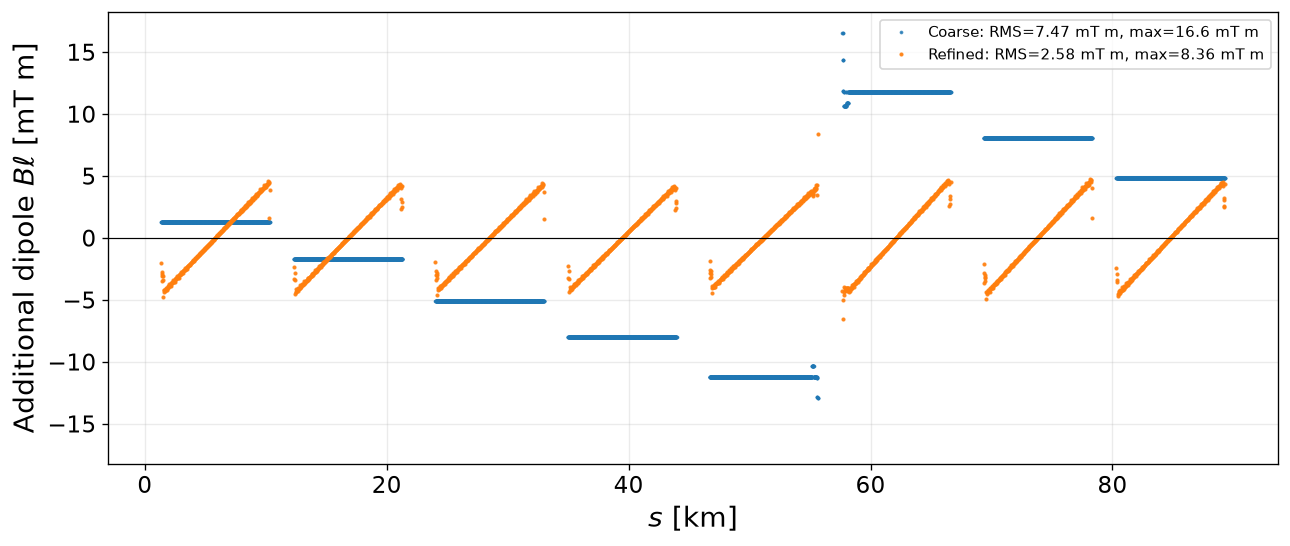

1 urad corresponds to 0.608754 mT m
Coarse dipoles: RMS |B*l| = 7.47178 mT m, max |B*l| = 16.5643 mT m
Refined trims: RMS |B*l| = 2.57802 mT m, max |B*l| = 8.36497 mT m


,dipole,s_km,applied_delta_taper,integrated_field_mTm
0,mbd.0,1.363667,0.002469,1.309538
1,mbd.1,1.373315,0.002469,1.309538
1112,mbd.2,1.385089,0.002469,1.309538
2223,mbd.3,1.394737,0.002469,1.309538
3334,mbd.4,1.407540,0.002469,1.309538
4445,mbd.5,1.417189,0.002469,1.309538
5556,mbd.6,1.428962,0.002469,1.309538
6327,mbd.7,1.438610,0.002469,1.309538
6438,mbd.8,1.451414,0.002469,1.309538
6549,mbd.9,1.461062,0.002469,1.309538


In [157]:
# Compare the two arc+DS dipole contributions:
#   1. coarse field increment from delta_taper on every DIP_* circuit;
#   2. refined knl[0] trim field on one selected dipole per cell.
# The selected trim dipole can also belong to a coarse circuit, because the
# trim winding is superimposed on the main dipole field.
horizontal_integrated_field_mTm = trim_strength_summary["integrated_field_mTm"].to_numpy(float)

plot_table = line.get_table()
s_by_name = dict(zip(
    np.asarray(plot_table.name, dtype=str),
    np.asarray(plot_table.s, dtype=float),
))

# Derive this list locally so the cell has no hidden execution-order
# dependency on the older reserved-dipole implementation.
coarse_dipole_names = np.unique(np.concatenate([
    np.asarray(elements, dtype=str)
    for circuit_name, elements in circuits.items()
    if circuit_name.startswith("DIP_")
]))

coarse_rows = []
for name in np.asarray(coarse_dipole_names, dtype=str):
    element = line[name]
    length = float(getattr(element, "length", 0.0))
    k0 = getattr(element, "k0", "from_h")

    # For an RBend with k0='from_h', k0*L is represented by its bend angle.
    if isinstance(k0, str) and k0 == "from_h":
        normalized_integrated_strength = float(element.angle)
    else:
        normalized_integrated_strength = float(k0)*length

    coarse_rows.append({
        "dipole": name,
        "s_km": s_by_name[name]/1e3,
        "applied_delta_taper": float(element.delta_taper),
        "integrated_field_mTm": (
            1e3*magnetic_rigidity_Tm
            * normalized_integrated_strength
            * float(element.delta_taper)
        ),
    })

coarse_dipole_strength_summary = pd.DataFrame(coarse_rows).sort_values("s_km")
coarse_integrated_field_mTm = coarse_dipole_strength_summary["integrated_field_mTm"].to_numpy(float)

overlapping_dipoles = np.intersect1d(
    coarse_dipole_strength_summary["dipole"].to_numpy(str),
    trim_strength_summary["dipole"].to_numpy(str),
)
print(f"Dipoles carrying both coarse field and trim winding: "
      f"{len(overlapping_dipoles)}")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(
    coarse_dipole_strength_summary["s_km"],
    coarse_integrated_field_mTm,
    ".", ms=2.5, color="tab:blue", alpha=0.75,
    label=(f"Coarse: "
           f"RMS={np.sqrt(np.mean(coarse_integrated_field_mTm**2)):.3g} mT m, "
           f"max={np.max(np.abs(coarse_integrated_field_mTm)):.3g} mT m"),
)
ax.plot(
    trim_strength_summary["s_km"],
    horizontal_integrated_field_mTm,
    ".", ms=3.0, color="tab:orange", alpha=0.85,
    label=(f"Refined: "
           f"RMS={np.sqrt(np.mean(horizontal_integrated_field_mTm**2)):.3g} mT m, "
           f"max={np.max(np.abs(horizontal_integrated_field_mTm)):.3g} mT m"),
)
ax.axhline(0.0, color="black", lw=0.7)
ax.set_xlabel(r"$s$ [km]")
ax.set_ylabel(r"Additional dipole $B\ell$ [mT m]")
ax.grid(alpha=0.25)
#ax.set_title(
#    "Coarse and refined dipole integrated-field increments "
#    + rf"($B\rho={magnetic_rigidity_Tm:.3f}$ T m)"
#)
ax.legend(fontsize=9, loc="best")

combined_maximum = max(
    np.max(np.abs(coarse_integrated_field_mTm)),
    np.max(np.abs(horizontal_integrated_field_mTm)),
)
plot_limit = max(15.0, 1.10*combined_maximum)
ax.set_ylim(-plot_limit, plot_limit)
fig.tight_layout()
plt.show()

print(f"1 urad corresponds to {magnetic_rigidity_Tm*1e-3:.6g} mT m")
print(
    "Coarse dipoles: "
    f"RMS |B*l| = {np.sqrt(np.mean(coarse_integrated_field_mTm**2)):.6g} mT m, "
    f"max |B*l| = {np.max(np.abs(coarse_integrated_field_mTm)):.6g} mT m"
)
print(
    "Refined trims: "
    f"RMS |B*l| = {np.sqrt(np.mean(horizontal_integrated_field_mTm**2)):.6g} mT m, "
    f"max |B*l| = {np.max(np.abs(horizontal_integrated_field_mTm)):.6g} mT m"
)

display(coarse_dipole_strength_summary.head(12))


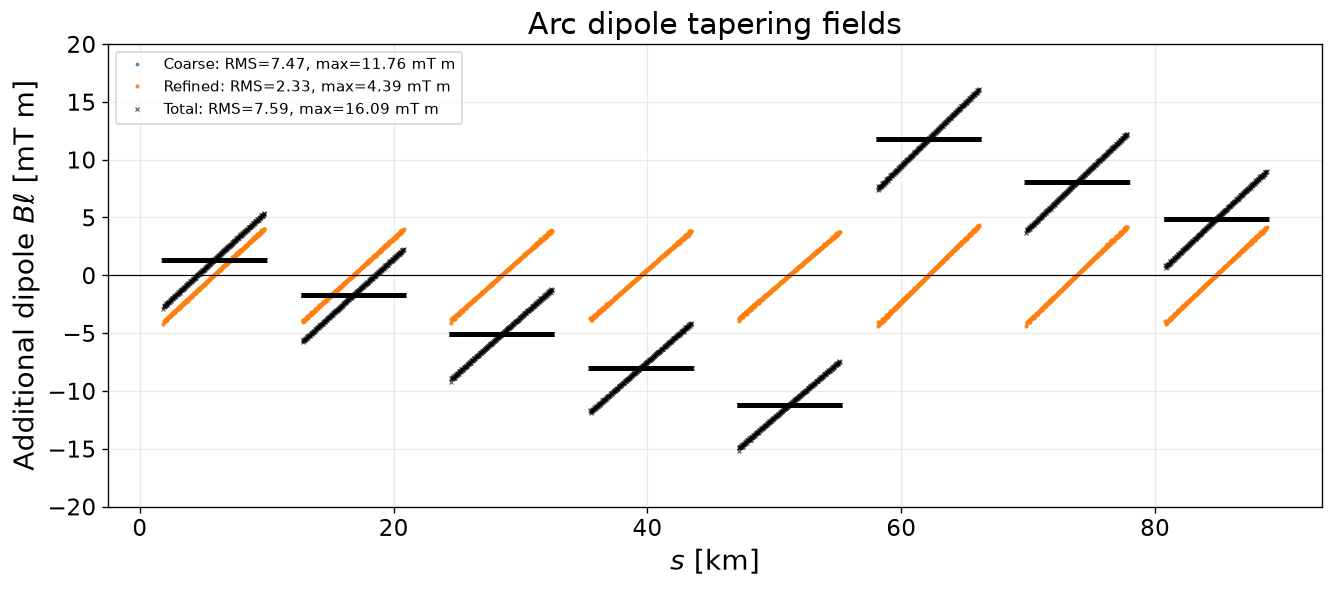

Coarse arc dipoles:  6000
Refined arc dipoles: 2000
Total arc dipoles:   6000


In [158]:
# Coarse, refined and total dipole-field contributions in the arcs only.
# Dispersion suppressors and insertions are excluded.

# TO FIX with 1+delta

arc_names = set(np.concatenate([
    np.asarray(names, dtype=str) for names in regions["arcs"].values()
]))

coarse_arcs = (
    coarse_dipole_strength_summary
    .loc[lambda frame: frame["dipole"].isin(arc_names),
         ["dipole", "s_km", "integrated_field_mTm"]]
    .sort_values("s_km")
)
refined_arcs = (
    trim_strength_summary
    .loc[lambda frame: frame["dipole"].isin(arc_names),
         ["dipole", "s_km", "integrated_field_mTm"]]
    .sort_values("s_km")
)

# Concatenation is clearer than an outer merge for the reserved-dipole
# layout. The groupby also remains correct if the two sets ever overlap.
total_arcs = (
    pd.concat([coarse_arcs, refined_arcs], ignore_index=True)
    .groupby("dipole", as_index=False)
    .agg(s_km=("s_km", "first"),
         integrated_field_mTm=("integrated_field_mTm", "sum"))
    .sort_values("s_km")
)

def rms_and_max(values):
    values = np.asarray(values, dtype=float)
    return np.sqrt(np.mean(values**2)), np.max(np.abs(values))

coarse_values = coarse_arcs["integrated_field_mTm"].to_numpy(float)
refined_values = refined_arcs["integrated_field_mTm"].to_numpy(float)
total_values = total_arcs["integrated_field_mTm"].to_numpy(float)
coarse_rms, coarse_max = rms_and_max(coarse_values)
refined_rms, refined_max = rms_and_max(refined_values)
total_rms, total_max = rms_and_max(total_values)

fig, ax = plt.subplots(figsize=(11, 4.8), layout="constrained")
ax.plot(coarse_arcs["s_km"], coarse_values, ".", ms=2.5,
        color="tab:blue", alpha=0.75,
        label=f"Coarse: RMS={coarse_rms:.2f}, max={coarse_max:.2f} mT m")
ax.plot(refined_arcs["s_km"], refined_values, ".", ms=3.0,
        color="tab:orange", alpha=0.85,
        label=f"Refined: RMS={refined_rms:.2f}, max={refined_max:.2f} mT m")
ax.plot(total_arcs["s_km"], total_values, "x", ms=2.5, mew=0.7,
        color="black", alpha=0.65,
        label=f"Total: RMS={total_rms:.2f}, max={total_max:.2f} mT m")
ax.axhline(0.0, color="black", lw=0.7)
ax.set(xlabel=r"$s$ [km]",
       ylabel=r"Additional dipole $B\ell$ [mT m]",
       title="Arc dipole tapering fields", ylim=(-20, 20))
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
plt.show()

print(f"Coarse arc dipoles:  {len(coarse_arcs)}")
print(f"Refined arc dipoles: {len(refined_arcs)}")
print(f"Total arc dipoles:   {len(total_arcs)}")


# Field change for each magnet

The circuits above are set through `delta_taper`, one value per circuit. What a magnet
builder is asked for is a field, so the `delta_taper` of the circuit is turned here into
the field change of every individual magnet.

`delta_taper` scales `k0`, `k1`, `k2` (and `knl`, `ksl`) of the magnet by
`1 + delta_taper`, so the change with respect to the nominal setting is

| magnet | quantity | field change | unit |
|---|---|---|---|
| dipole | integrated field | `k0 * L * delta_taper * Brho` | mT m |
| quadrupole | integrated gradient | `k1 * L * delta_taper * Brho` | mT |
| sextupole | integrated sextupole gradient | `k2 * L * delta_taper * Brho` | mT/m |

One circuit holds magnets of more than one integrated strength, so the same
`delta_taper` does not ask the same field change of all of them: the numbers below are
read magnet by magnet, not circuit by circuit. The circuit families — `QF` and `QD`, and
the four sextupole families — are kept apart throughout, since they are different
magnets and are not asked for the same field.

In [159]:
# Per-magnet field change produced by the applied tapering.

FIELD_UNIT = {
    "dipole": "mT m",
    "quadrupole": "mT",
    "sextupole": "mT/m",
}

# The circuit families of each magnet type, kept apart everywhere below: the
# focusing and the defocusing magnets are not the same magnets and are not asked
# for the same field.
FAMILY_GROUPS = {
    "dipole": ("DIP",),
    "quadrupole": ("QF", "QD"),
    "sextupole": ("SF1", "SF2", "SD1", "SD2"),
}


def magnetic_rigidity(line):
    p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
    charge_number = abs(float(line.particle_ref.q0))
    return p0c_GeV / (0.299792458 * charge_number)


def circuit_group(circuit_name):
    """The family a circuit belongs to: DIP_1_ipa_ipb -> DIP, SF1_ipa_ipb -> SF1."""
    return circuit_name.split("_")[0]


def circuit_family(circuit_name):
    group = circuit_group(circuit_name)

    for family, groups in FAMILY_GROUPS.items():
        if group in groups:
            return family

    return None


def integrated_strength(element, family):
    """Integrated normal strength of a magnet: k0*L, k1*L or k2*L.

    The bends of this lattice carry `k0 = 'from_h'`, meaning that their field
    follows their curvature, so k0*L is read from h and equals the bending angle.
    """
    length = float(element.length)

    if family == "dipole":
        k0 = element.k0
        if isinstance(k0, str):
            k0 = element.h
        return float(k0) * length

    if family == "quadrupole":
        return float(element.k1) * length

    return float(element.k2) * length


def read_magnet_field_changes(line, circuits, ideal_taper_by_name, circuit_prefixes=None):
    """One row per magnet: its delta_taper and the field change that this asks of it.

    `field_change` is what the applied, circuit-wide delta_taper asks for;
    `field_change_ideal` is what the magnet's own ideal delta_taper would ask for.
    Their difference is the field error left by the coarse granularity.
    """
    table = line.get_table()
    s_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.s, dtype=float),
    ))
    brho_Tm = magnetic_rigidity(line)

    rows = []

    for circuit_name, circuit_elements in circuits.items():

        if circuit_prefixes is not None:
            if not circuit_name.startswith(tuple(circuit_prefixes)):
                continue

        family = circuit_family(circuit_name)

        if family is None:
            continue

        for name in np.asarray(circuit_elements, dtype=str):
            name = str(name)

            if name not in ideal_taper_by_name:
                continue

            element = line[name]
            strength = integrated_strength(element, family)
            applied = float(element.delta_taper)
            ideal = float(ideal_taper_by_name[name])

            rows.append({
                "name": name,
                "circuit": circuit_name,
                "family": family,
                "group": circuit_group(circuit_name),
                "s_km": s_by_name[name] / 1e3,
                "length_m": float(element.length),
                "integrated_strength": strength,
                "delta_taper_applied": applied,
                "delta_taper_ideal": ideal,
                "field_change": strength * applied * brho_Tm * 1e3,
                "field_change_ideal": strength * ideal * brho_Tm * 1e3,
                "unit": FIELD_UNIT[family],
            })

    field_changes = pd.DataFrame(rows)
    field_changes["field_change_error"] = (
        field_changes["field_change"] - field_changes["field_change_ideal"]
    )
    return field_changes

In [160]:
field_changes = read_magnet_field_changes(line, circuits, ideal_taper_by_name)

field_changes_by_family = {
    family: rows.reset_index(drop=True)
    for family, rows in field_changes.groupby("family")
}

summary_rows = []

for family, groups in FAMILY_GROUPS.items():
    for group in groups:
        rows = field_changes[field_changes["group"] == group]

        summary_rows.append({
            "group": group,
            "family": family,
            "unit": FIELD_UNIT[family],
            "magnets": len(rows),
            "circuits": rows["circuit"].nunique(),
            "RMS applied": np.sqrt(np.mean(rows["field_change"] ** 2)),
            "max |applied|": rows["field_change"].abs().max(),
            "max |applied - ideal|": rows["field_change_error"].abs().max(),
        })

field_change_summary = pd.DataFrame(summary_rows)

print(f"B rho = {magnetic_rigidity(line):.3f} T m")
display(field_change_summary)
display(field_changes.head(8))

B rho = 608.754 T m


,group,family,unit,magnets,circuits,RMS applied,max |applied|,max |applied - ideal|
0,DIP,dipole,mT m,6720,8,7.471780,16.564296,2.325609
1,QF,quadrupole,mT,1064,16,412.646552,693.551998,42.640374
2,QD,quadrupole,mT,1072,16,354.258757,592.164724,36.744337
3,SF1,sextupole,mT/m,400,8,3493.064132,5498.445575,674.955538
4,SF2,sextupole,mT/m,400,8,3284.357853,5169.921393,645.057977
5,SD1,sextupole,mT/m,400,8,5429.085142,8545.944436,1057.668193
6,SD2,sextupole,mT/m,400,8,6121.877674,9636.470449,1173.194180


,name,circuit,family,group,s_km,length_m,integrated_strength,delta_taper_applied,delta_taper_ideal,field_change,field_change_ideal,unit,field_change_error
0,mbd.0,DIP_1_ipa_ipb,dipole,DIP,1.363667,9.613334,0.000871,0.002469,0.005360,1.309538,2.842870,mT m,-1.533332
1,mbd.1,DIP_1_ipa_ipb,dipole,DIP,1.373315,9.613334,0.000871,0.002469,0.005353,1.309538,2.839208,mT m,-1.529670
2,mbd.2,DIP_1_ipa_ipb,dipole,DIP,1.385089,9.613334,0.000871,0.002469,0.005346,1.309538,2.835546,mT m,-1.526008
3,mbd.3,DIP_1_ipa_ipb,dipole,DIP,1.394737,9.613334,0.000871,0.002469,0.005339,1.309538,2.831884,mT m,-1.522346
4,mbd.4,DIP_1_ipa_ipb,dipole,DIP,1.407540,9.613334,0.000871,0.002469,0.005332,1.309538,2.828222,mT m,-1.518684
5,mbd.5,DIP_1_ipa_ipb,dipole,DIP,1.417189,9.613334,0.000871,0.002469,0.005325,1.309538,2.824561,mT m,-1.515022
6,mbd.6,DIP_1_ipa_ipb,dipole,DIP,1.428962,9.613334,0.000871,0.002469,0.005318,1.309538,2.820899,mT m,-1.511361
7,mbd.7,DIP_1_ipa_ipb,dipole,DIP,1.438610,9.613334,0.000871,0.002469,0.005311,1.309538,2.817238,mT m,-1.507699


In [161]:
# The RF region, from the lattice's own markers: the straight section at point H
# with its two dispersion suppressors. Its dipoles are the outliers of the arcs.
s_by_name = dict(zip(
    np.asarray(tt.name, dtype=str),
    np.asarray(tt.s, dtype=float),
))
RF_REGION_KM = (
    s_by_name["end_arc_start_ds_iph"] / 1e3,
    s_by_name["end_ds_start_arc_iph"] / 1e3,
)

# Okabe-Ito, distinguishable under the common colour-vision deficiencies. One
# colour per circuit family, taken in order, so a family keeps its colour.
SERIES_COLOURS = ("#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9")


def plot_field_change_along_ring(
    series,
    ylabel,
    unit,
    title,
    bins=60,
    colours=SERIES_COLOURS,
    markersizes=None,
):
    """Field change of every magnet along the ring, and its distribution.

    `series` maps a label to a (s_km, values) pair, all drawn on the same axes,
    in the order they are given: the first one ends up underneath. A series that
    is the sum of the others is best given first and with a larger marker, so
    that the terms it is made of stay visible on top of it.
    """
    if markersizes is None:
        markersizes = [2.5] * len(series)

    # One set of bin edges for every series, so the steps can be read against
    # each other. With a bin count per series they would each span their own
    # range, and two steps of different width look like a comparison without
    # being one.
    magnitudes = [
        np.abs(np.asarray(values, dtype=float)) for _, values in series.values()
    ]
    largest = max((column.max() for column in magnitudes if len(column)), default=0.0)
    if np.isscalar(bins) and largest > 0.0:
        bins = np.linspace(0.0, largest, int(bins) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), width_ratios=(2.2, 1))

    axes[0].axvspan(*RF_REGION_KM, color="0.85", zorder=0, label="RF region")

    for (label, (s_km, values)), colour, size in zip(
        series.items(), colours, markersizes
    ):
        values = np.asarray(values, dtype=float)
        axes[0].plot(s_km, values, ".", ms=size, color=colour, alpha=0.7, label=label)
        axes[1].hist(
            np.abs(values), bins=bins, histtype="step", lw=2, color=colour,
            label=f"{label}: max={np.abs(values).max():.3g} {unit}",
        )

    axes[0].axhline(0.0, color="black", lw=0.7)
    axes[0].set_xlabel(r"$s$ [km]")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title, loc="left")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=9, markerscale=4)

    axes[1].set_xlabel(f"|field change| [{unit}]")
    axes[1].set_ylabel("Magnets")
    axes[1].set_yscale("log")
    axes[1].set_title("Distribution", loc="left")
    axes[1].grid(alpha=0.25, which="both")
    axes[1].legend(fontsize=9)

    fig.tight_layout()
    plt.show()
    return fig

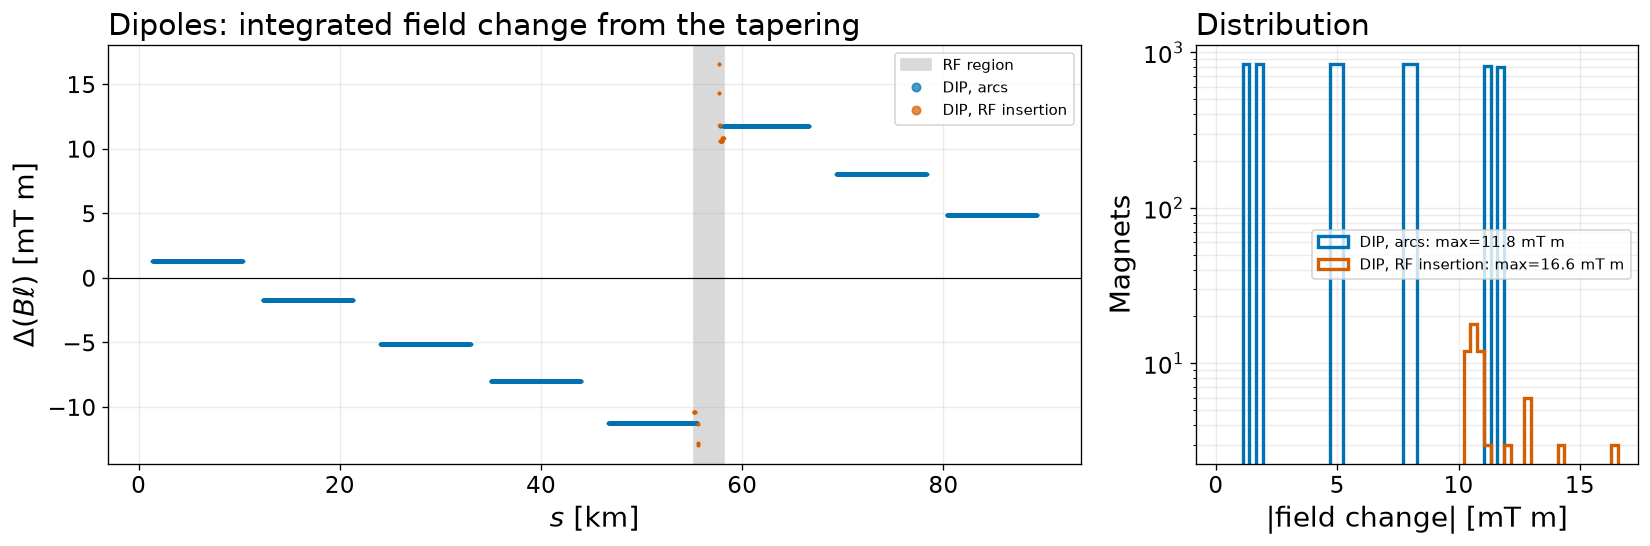

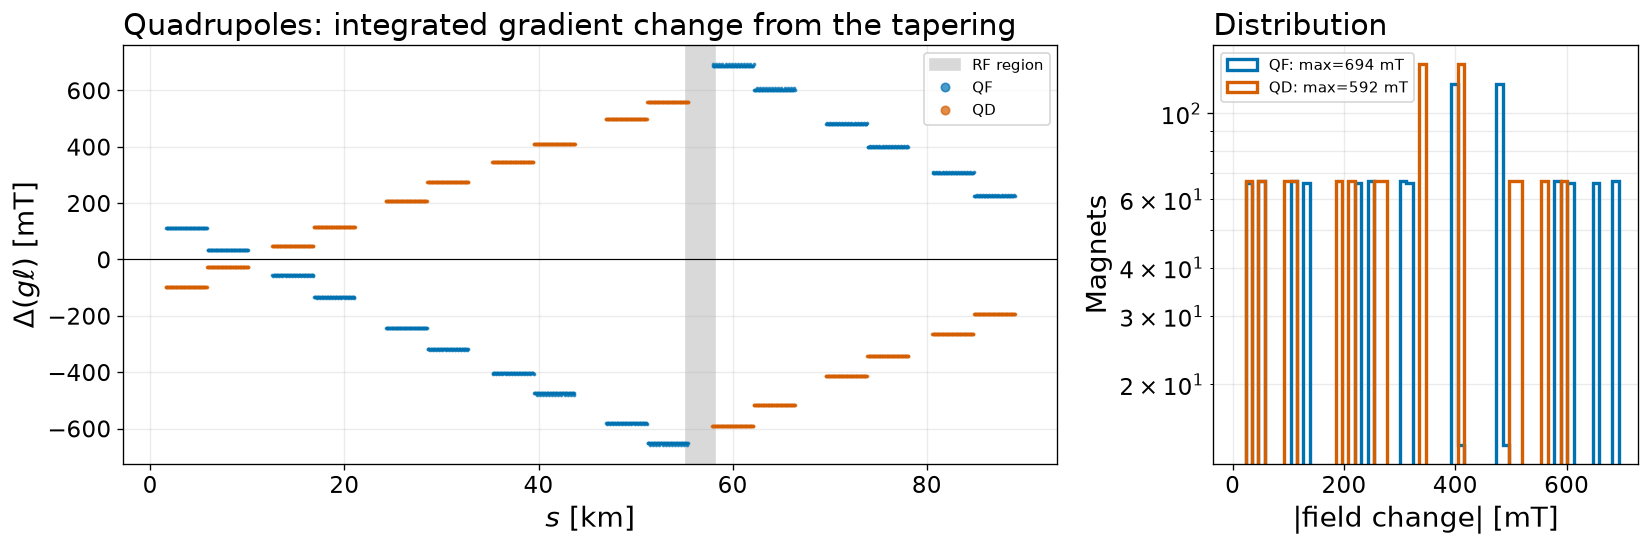

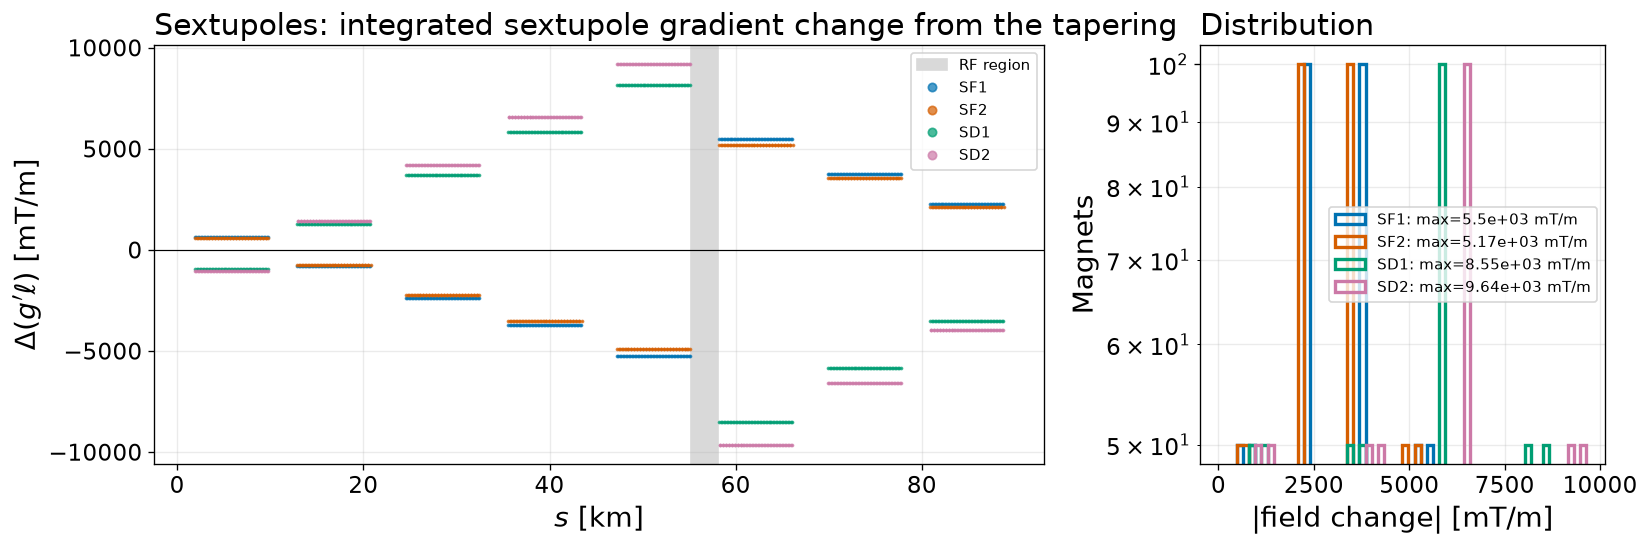

In [162]:
# One figure per magnet type, one colour per circuit family.
FAMILY_YLABEL = {
    "dipole": r"$\Delta (B\ell)$ [mT m]",
    "quadrupole": r"$\Delta (g\ell)$ [mT]",
    "sextupole": r"$\Delta (g'\ell)$ [mT/m]",
}

FAMILY_TITLE = {
    "dipole": "Dipoles: integrated field change from the tapering",
    "quadrupole": "Quadrupoles: integrated gradient change from the tapering",
    "sextupole": "Sextupoles: integrated sextupole gradient change from the tapering",
}

# The magnets of the RF insertion carry "_rf" in their name: the dipoles of the
# two dispersion suppressors around point H, inside the grey band of the figure.
# They are the outliers of the arc population, so they are drawn as a series of
# their own -- their own colour along the ring and their own step in the
# histogram -- instead of being counted in with the arc dipoles.
RF_MAGNET = re.compile(r"_rf(?:\.|$)")

# The families drawn with their RF insertion apart, and the two colours that
# split takes: blue for the arcs, orange for the RF insertion, both Okabe-Ito.
# One pair of colours per group, so this holds for a family of a single group.
SPLIT_RF_FAMILIES = {"dipole"}
SPLIT_RF_COLOURS = ("#0072B2", "#D55E00")


def split_rf_magnets(rows, label, column="field_change"):
    """``{label: (s_km, column)}`` for one set of magnets, RF insertion apart.

    ``column`` is which quantity of ``rows`` is plotted, so the same split
    serves the tapering figures here and the tapering-and-trim figure further
    down. An empty half is dropped rather than drawn: a series with no magnet
    in it would take a colour and an entry in both legends and has nothing to
    say.
    """
    in_rf = rows["name"].str.contains(RF_MAGNET)
    halves = (
        (f"{label}, arcs", rows[~in_rf]),
        (f"{label}, RF insertion", rows[in_rf]),
    )
    return {
        name: (part["s_km"], part[column])
        for name, part in halves
        if len(part)
    }


for family, groups in FAMILY_GROUPS.items():
    rows = field_changes_by_family[family]

    series = {}

    for group in groups:
        selected = rows[rows["group"] == group]

        if family in SPLIT_RF_FAMILIES:
            series |= split_rf_magnets(selected, group)
        else:
            series[group] = (selected["s_km"], selected["field_change"])

    plot_field_change_along_ring(
        series,
        ylabel=FAMILY_YLABEL[family],
        unit=FIELD_UNIT[family],
        title=FAMILY_TITLE[family],
        colours=(
            SPLIT_RF_COLOURS if family in SPLIT_RF_FAMILIES else SERIES_COLOURS
        ),
    )

## Dipoles: tapering and trim together

A trim dipole is asked for two things at once, and the coil has to provide their sum:
the field change of the tapering, and the trim that corrects the horizontal orbit.

The two are written here in the same convention, the change of the integrated field of
the magnet. The trim lives in `knl[0]`, so its contribution is built from `delta_knl0`,
and it comes out with the *opposite sign* of the `kick * Brho` plotted further up,
because a positive horizontal kick is a negative `knl[0]`.

With radiation on, xsuite scales `knl` by `1 + delta_taper` together with `k0`, so the
field the trim coil has to provide is `delta_knl0 * (1 + delta_taper) * Brho`, and that
factor is kept here. `delta_taper` reaches a few `1e-2` on these circuits, so it is
worth a few percent of the trim — small, but not a rounding error.

It does not put the correction in question. The loop iterates on the measured orbit, so
the converged machine is right whatever the bookkeeping; and while the impulse a trim
gives is `kick * (1 + delta_taper)`, the beam at that point carries the same
`1 + delta_taper` more momentum, so the trajectory bends by `kick` — which is exactly
what the response matrix is built for. 

In [163]:
brho_Tm = magnetic_rigidity(line)

# The trim of each selected dipole, read back from the lattice rather than from
# the kicks it was asked for.
trim_delta_knl0 = {
    str(name): float(line[name].knl[0]) - float(base)
    for name, base in zip(trim_dipole_names, trim_base_knl)
}

# With a knl[0] of zero before the trims, the tapering and the trim add up to the
# whole change of the magnet's field with no cross term left over.
assert np.allclose(trim_base_knl, 0.0, atol=1e-16), (
    "the trim dipoles carry a knl[0] of their own, so the tapering and the trim "
    "no longer split exactly"
)

dipole_fields = field_changes_by_family["dipole"].copy()

missing_trims = set(trim_delta_knl0) - set(dipole_fields["name"])
assert not missing_trims, (
    f"{len(missing_trims)} trim dipoles are not in the dipole circuits, "
    f"first: {sorted(missing_trims)[:3]}"
)

dipole_fields["trim_delta_knl0"] = [
    trim_delta_knl0.get(name, 0.0) for name in dipole_fields["name"]
]

# The tapering scales knl together with k0, so the coil provides
# delta_knl0 * (1 + delta_taper) * Brho, a few percent more than delta_knl0 * Brho.
dipole_fields["trim_field_change"] = (
    dipole_fields["trim_delta_knl0"]
    * (1.0 + dipole_fields["delta_taper_applied"])
    * brho_Tm * 1e3
)
dipole_fields["total_field_change"] = (
    dipole_fields["field_change"] + dipole_fields["trim_field_change"]
)
dipole_fields["total_field_mT"] = (
    dipole_fields["total_field_change"] / dipole_fields["length_m"]
)

has_trim = dipole_fields["trim_field_change"] != 0.0

# What the (1 + delta_taper) scaling of knl is worth, against the kick * Brho of
# the figure above.
unscaled_trim_mTm = dipole_fields["trim_delta_knl0"] * brho_Tm * 1e3

print(f"Dipoles in the circuits: {len(dipole_fields)}, of which trimmed: {int(has_trim.sum())}")
print(f"max |trim B*l| = {dipole_fields['trim_field_change'].abs().max():.4g} mT m "
      f"with the (1 + delta_taper) scaling, {unscaled_trim_mTm.abs().max():.4g} mT m without it")

dipole_field_summary = pd.DataFrame([
    {
        "contribution": label,
        "RMS [mT m]": np.sqrt(np.mean(values ** 2)),
        "max |.| [mT m]": values.abs().max(),
        "at": dipole_fields["name"][values.abs().idxmax()],
    }
    for label, values in (
        ("Tapering", dipole_fields["field_change"]),
        ("Trim", dipole_fields["trim_field_change"]),
        ("Tapering + trim", dipole_fields["total_field_change"]),
        ("Tapering + trim, trimmed dipoles only", dipole_fields["total_field_change"][has_trim]),
    )
])

display(dipole_field_summary)

Dipoles in the circuits: 6720, of which trimmed: 2262
max |trim B*l| = 8.188 mT m with the (1 + delta_taper) scaling, 8.365 mT m without it


,contribution,RMS [mT m],max |.| [mT m],at
0,Tapering,7.471780,16.564296,mbd3r_rf.0
1,Trim,1.497545,8.188198,mbd3l_rf.0
2,Tapering + trim,7.618734,21.091618,mbd3l_rf.0
3,"Tapering + trim, trimmed dipoles only",7.896099,21.091618,mbd3l_rf.0


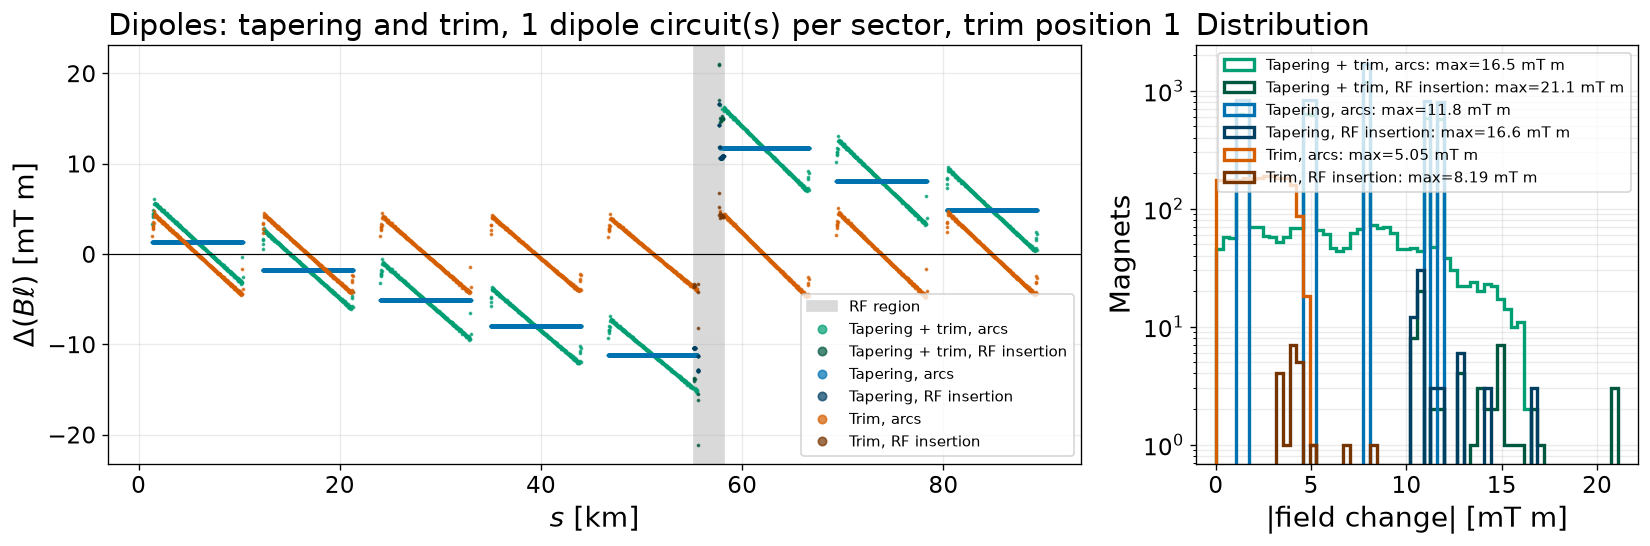

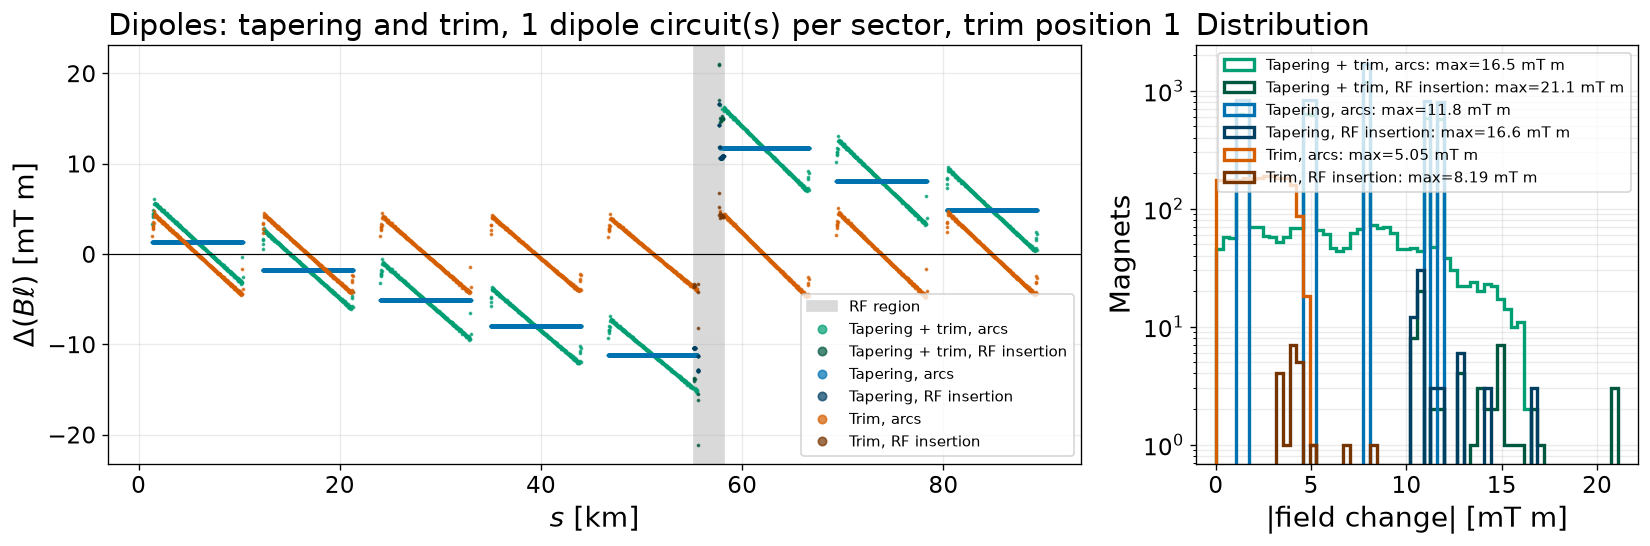

In [164]:
# The sum first and with the larger marker, so that the two terms it is made of
# stay readable on top of it. Only one dipole per cell carries a trim, and the
# ones that do not are left out of the trim series rather than drawn at zero.
#
# Each of the three is split at the RF insertion, the way the tapering figures
# above are. Hue still carries the quantity -- green the sum, blue the
# tapering, orange the trim -- and the dark shade of that hue carries the RF
# insertion, so the figure keeps reading as three quantities and the region is
# the weaker distinction inside each of them.
trimmed = dipole_fields[has_trim]

# quantity -> (arc magnets, RF-insertion magnets)
RF_SHADES = {
    "Tapering + trim": ("#009E73", "#00573F"),
    "Tapering": ("#0072B2", "#003F62"),
    "Trim": ("#D55E00", "#753400"),
}

trim_series = {}
trim_colours = []
trim_markersizes = []

for label, column, rows, markersize in (
    ("Tapering + trim", "total_field_change", dipole_fields, 2.5),
    ("Tapering", "field_change", dipole_fields, 2.5),
    ("Trim", "trim_field_change", trimmed, 2.5),
):
    halves = split_rf_magnets(rows, label, column)
    trim_series |= halves

    for name in halves:
        in_rf = name.endswith("RF insertion")
        trim_colours.append(RF_SHADES[label][in_rf])
        # Sixty magnets against several thousand: at the size of an arc point a
        # dark shade of the same hue is not a distinction anyone can make.
        trim_markersizes.append(markersize  if in_rf else markersize)

plot_field_change_along_ring(
    trim_series,
    colours=tuple(trim_colours),
    markersizes=tuple(trim_markersizes),
    ylabel=r"$\Delta (B\ell)$ [mT m]",
    unit="mT m",
    title=(
        f"Dipoles: tapering and trim, {N_DIPOLE_CIRCUITS_PER_SECTOR} dipole "
        f"circuit(s) per sector, trim position {TRIM_POSITION_IN_CELL}"
    ),
)

In [165]:
# The dipoles asked for the most field, tapering and trim together.
strongest_dipoles = (
    dipole_fields
    .reindex(dipole_fields["total_field_change"].abs().sort_values(ascending=False).index)
    .head(12)[[
        "name", "circuit", "s_km", "length_m",
        "delta_taper_applied", "field_change", "trim_field_change",
        "total_field_change", "total_field_mT",
    ]]
)
display(strongest_dipoles)

,name,circuit,s_km,length_m,delta_taper_applied,field_change,trim_field_change,total_field_change,total_field_mT
4197,mbd3l_rf.0,DIP_1_ipg_iph,55.622755,9.613334,-0.021133,-12.903420,-8.188198,-21.091618,-2.193996
4203,mbd2r_rf.0,DIP_1_iph_ipj,57.704726,9.613334,0.022176,14.307768,6.717922,21.025690,2.187138
4200,mbd3r_rf.0,DIP_1_iph_ipj,57.673656,9.613334,0.022176,16.564296,4.352048,20.916343,2.175764
4206,mbd1r_rf.0,DIP_1_iph_ipj,57.737226,9.613334,0.022176,11.877327,5.170735,17.048062,1.773377
4202,mbd3r_rf.2,DIP_1_iph_ipj,57.692953,9.613334,0.022176,16.564296,0.000000,16.564296,1.723054
4201,mbd3r_rf.1,DIP_1_iph_ipj,57.683304,9.613334,0.022176,16.564296,0.000000,16.564296,1.723054
4209,mbd.4179,DIP_1_iph_ipj,57.768916,9.613334,0.022176,11.762321,4.714718,16.477039,1.713978
4248,mbd.4188,DIP_1_iph_ipj,58.184916,9.613334,0.022176,11.762321,4.475095,16.237416,1.689052
4194,mbd2l_rf.0,DIP_1_ipg_iph,55.591685,9.613334,-0.021133,-12.825184,-3.340539,-16.165722,-1.681594
4257,mbd.4197,DIP_1_iph_ipj,58.280796,9.613334,0.022176,11.762321,4.387665,16.149986,1.679957


## The magnets that keep their own tapering

Everything that is not on one of the coarse circuits is tapered individually, through
`apply_full_taper` — the magnets of the insertions, and the handful of arc magnets the
circuits do not cover. The orbit correctors are the exception: they sit in the
`no_tapering` setters and stay at `delta_taper = 0`.

These are grouped by element type rather than by circuit family, since they have no
circuit. A magnet left at `delta_taper = 0` is asked for nothing and is dropped from the
figures, the orbit correctors above all; the table keeps them, which is where the record
that they were held at zero belongs. The thin correctors would have no field panel in
any case: their strength is a `knl` of no fixed order.

In [166]:
# Every taperable magnet that is not on one of the coarse circuits.

ELEMENT_TYPE_ORDER = (
    "RBend", "Bend", "Quadrupole", "Sextupole", "Octupole", "Multipole",
)

# The element types whose main integrated strength is a single number, and the
# family of `integrated_strength` that reads it.
STRENGTH_FAMILY = {
    "RBend": "dipole",
    "Bend": "dipole",
    "Quadrupole": "quadrupole",
    "Sextupole": "sextupole",
}


def read_individual_tapering(line, circuits, ideal_taper_by_name):
    """One row per magnet tapered on its own, with the field change it asks for.

    `field_change` is left empty for the element types whose strength is not a
    single number, the thin correctors above all.
    """
    on_circuit = {
        str(name)
        for elements in circuits.values()
        for name in elements
    }

    table = line.get_table()
    s_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.s, dtype=float),
    ))
    type_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.element_type, dtype=str),
    ))
    brho_Tm = magnetic_rigidity(line)

    rows = []

    for name, ideal in ideal_taper_by_name.items():
        name = str(name)

        if name in on_circuit:
            continue

        element = line[name]
        element_type = type_by_name.get(name, "")
        family = STRENGTH_FAMILY.get(element_type)
        applied = float(element.delta_taper)

        if family is None:
            strength = np.nan
            unit = ""
        else:
            strength = integrated_strength(element, family)
            unit = FIELD_UNIT[family]

        rows.append({
            "name": name,
            "element_type": element_type,
            "s_km": s_by_name[name] / 1e3,
            "length_m": float(element.length),
            "integrated_strength": strength,
            "delta_taper_applied": applied,
            "delta_taper_ideal": float(ideal),
            "delta_taper_percent": 100.0 * applied,
            "field_change": strength * applied * brho_Tm * 1e3,
            "unit": unit,
        })

    return pd.DataFrame(rows)


def ordered_element_types(rows):
    present = list(dict.fromkeys(rows["element_type"]))
    known = [name for name in ELEMENT_TYPE_ORDER if name in present]
    return known + [name for name in present if name not in ELEMENT_TYPE_ORDER]


individual_tapering = read_individual_tapering(line, circuits, ideal_taper_by_name)

individual_summary = pd.DataFrame([
    {
        "element type": element_type,
        "magnets": len(rows),
        "tapered": int((rows["delta_taper_applied"] != 0.0).sum()),
        "follows the ideal": bool(np.allclose(
            rows["delta_taper_applied"], rows["delta_taper_ideal"], atol=1e-12
        )),
        "max |delta taper| [%]": rows["delta_taper_percent"].abs().max(),
        "max |field change|": rows["field_change"].abs().max(),
        "unit": rows["unit"].iloc[0],
    }
    for element_type in ordered_element_types(individual_tapering)
    for rows in [individual_tapering[individual_tapering["element_type"] == element_type]]
])

# A magnet at delta_taper = 0 is asked for nothing: the figures below are drawn
# from the tapered ones alone, and an element type left with none of them loses
# its panel.
tapered_individually = individual_tapering[
    individual_tapering["delta_taper_applied"] != 0.0
]

print(f"Individually tapered magnets: {len(individual_tapering)} "
      f"of {len(ideal_taper_by_name)} taperable elements, "
      f"{len(tapered_individually)} of them with a non-zero tapering")
display(individual_summary)

Individually tapered magnets: 5529 of 15985 taperable elements, 1025 of them with a non-zero tapering


,element type,magnets,tapered,follows the ideal,max |delta taper| [%],max |field change|,unit
0,RBend,173,173,False,2.527934,72.952293,mT m
1,Quadrupole,540,540,False,2.527953,1964.429902,mT
2,Sextupole,216,216,False,2.520076,11666.461678,mT/m
3,Multipole,4600,96,False,2.515577,NaN,


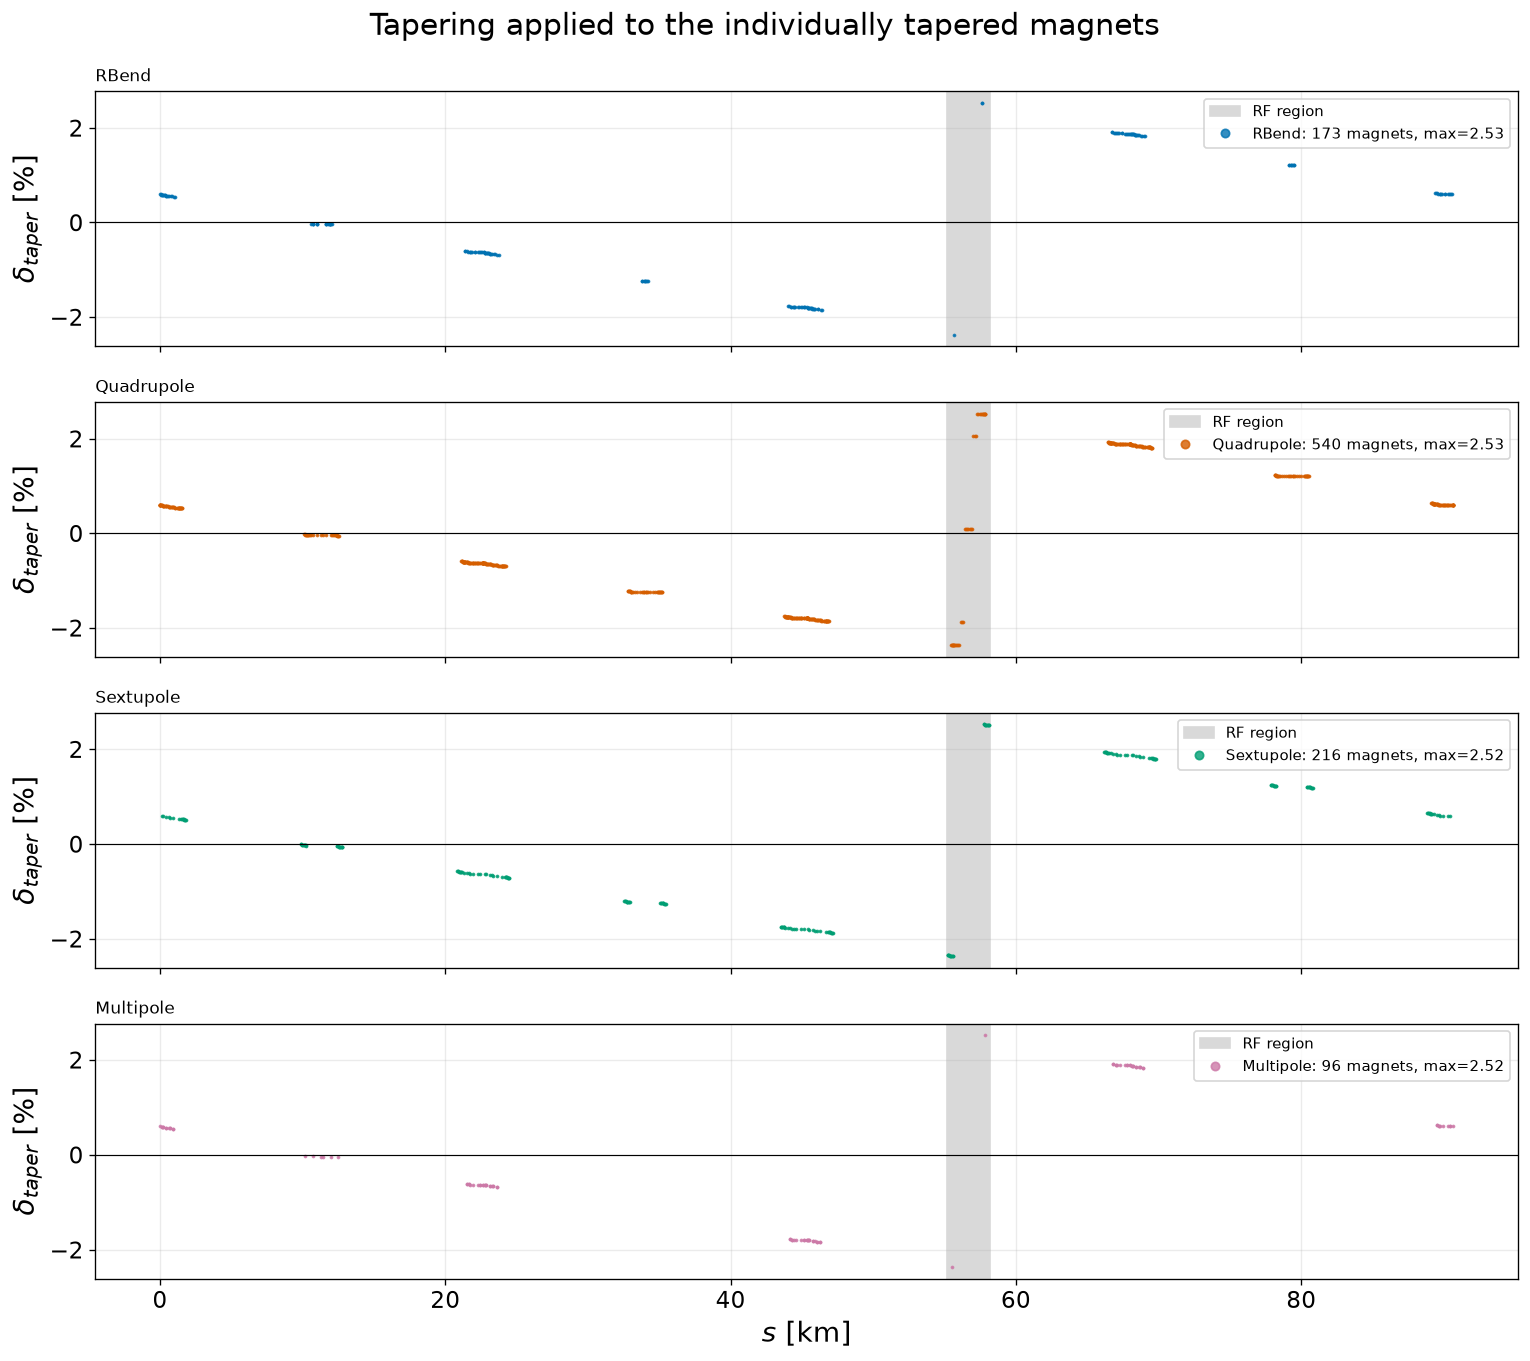

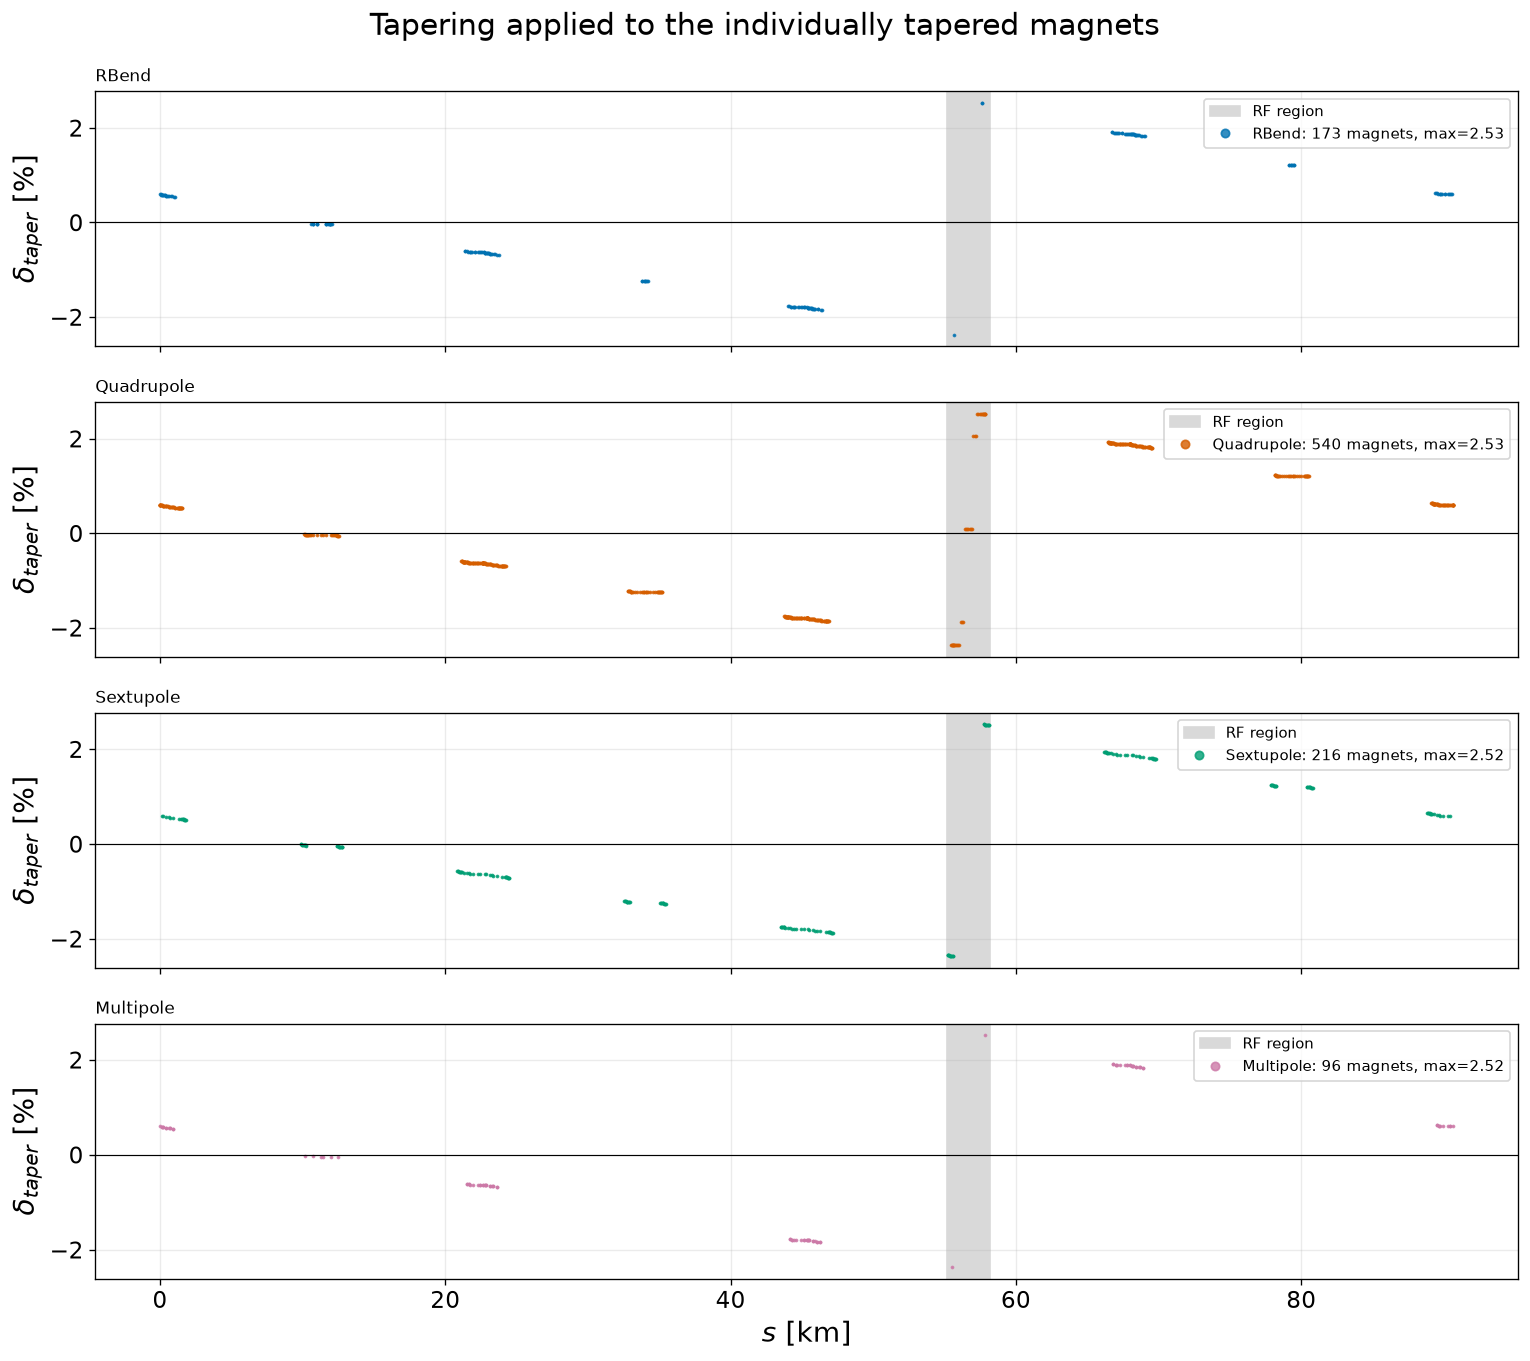

In [167]:
def plot_by_element_type(rows, column, ylabel, title, element_types=None, unit_from_rows=False):
    """One panel per element type, the quantity of every magnet along the ring."""
    if element_types is None:
        element_types = ordered_element_types(rows)

    fig, axes = plt.subplots(
        len(element_types), 1,
        figsize=(13, 2.9 * len(element_types)),
        sharex=True,
        squeeze=False,
    )

    for ax, element_type, colour in zip(axes[:, 0], element_types, SERIES_COLOURS):
        selected = rows[rows["element_type"] == element_type]
        values = np.asarray(selected[column], dtype=float)
        unit = selected["unit"].iloc[0] if unit_from_rows else ""

        ax.axvspan(*RF_REGION_KM, color="0.85", zorder=0, label="RF region")
        ax.plot(
            selected["s_km"], values, ".", ms=2.5, color=colour, alpha=0.8,
            label=f"{element_type}: {len(selected)} magnets, "
                  f"max={np.nanmax(np.abs(values)):.3g} {unit}".rstrip(),
        )
        ax.axhline(0.0, color="black", lw=0.7)
        ax.set_ylabel(f"{ylabel} [{unit}]" if unit_from_rows else ylabel)
        ax.set_title(element_type, loc="left", fontsize=10)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9, markerscale=4, loc="upper right")

    axes[-1, 0].set_xlabel(r"$s$ [km]")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return fig


plot_by_element_type(
    tapered_individually,
    column="delta_taper_percent",
    ylabel=r"$\delta_{taper}$ [%]",
    title="Tapering applied to the individually tapered magnets",
)

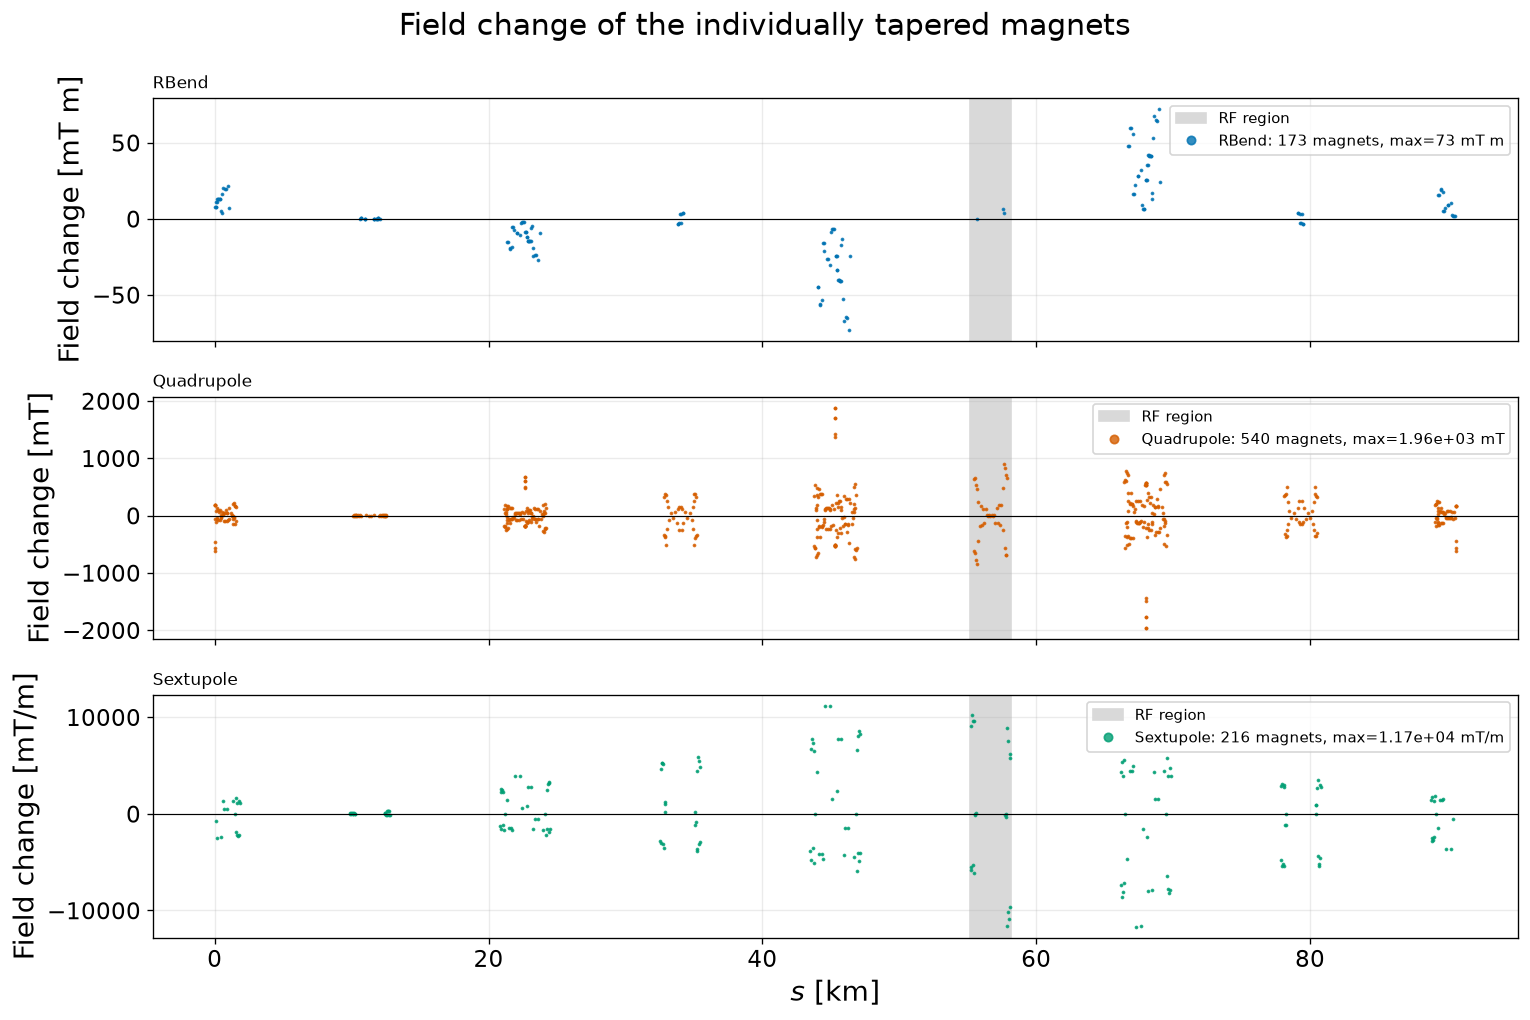

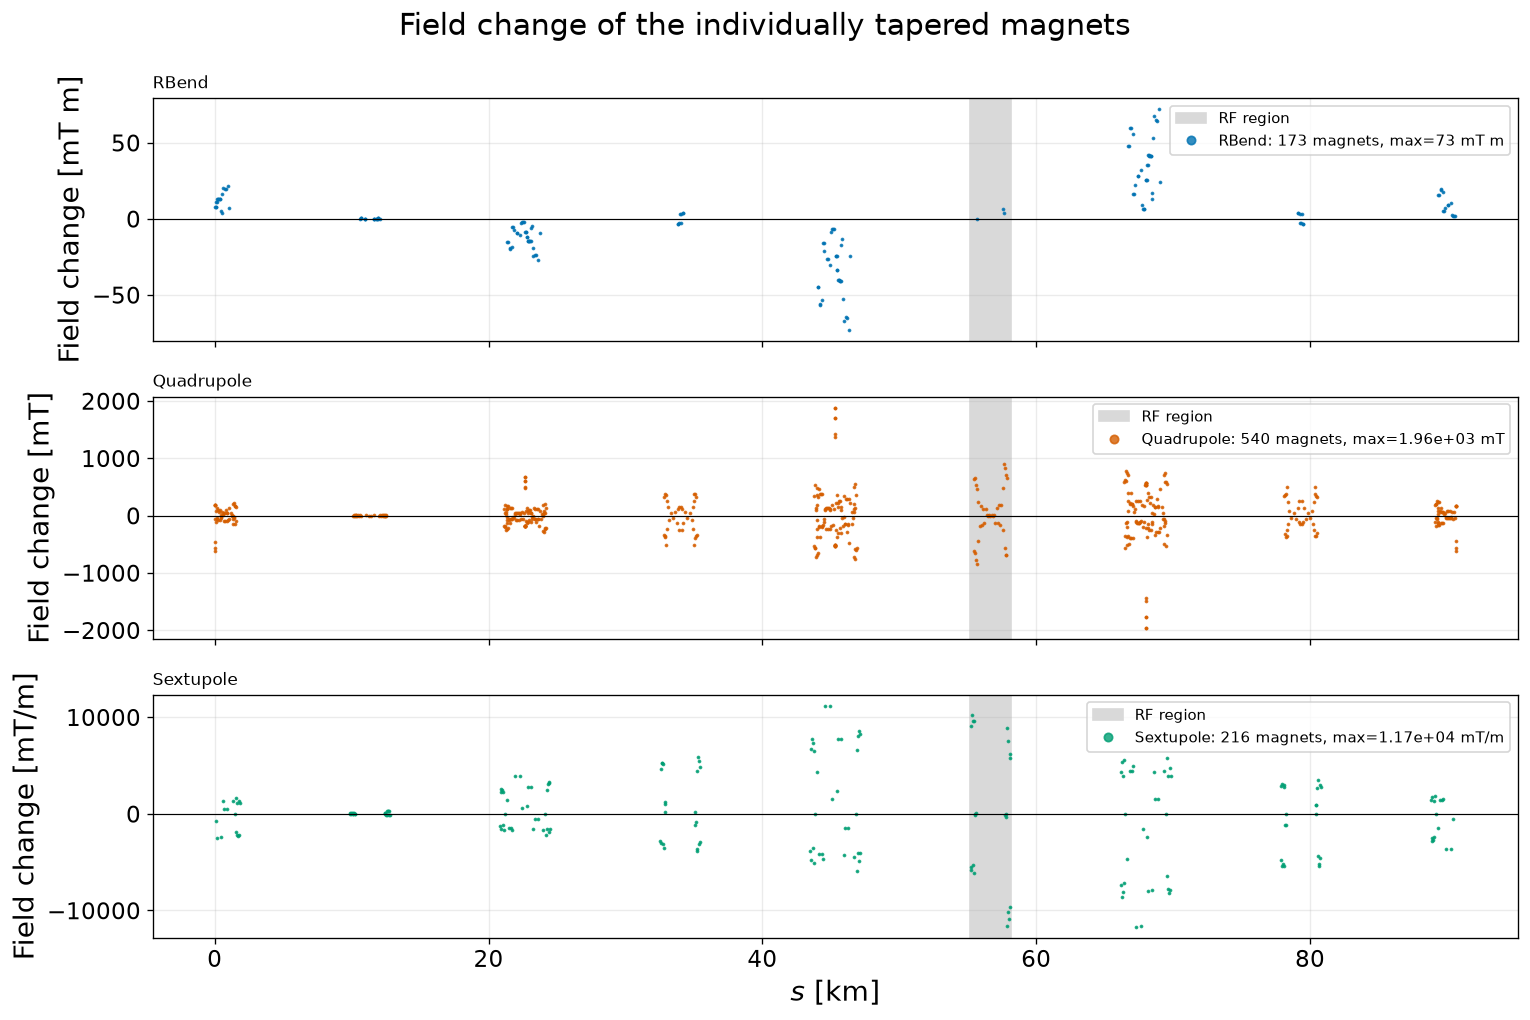

In [168]:
# The same magnets, as the field change the tapering asks of them. The thin
# correctors have no single integrated strength, so they have no panel here.
plot_by_element_type(
    tapered_individually,
    column="field_change",
    ylabel="Field change",
    title="Field change of the individually tapered magnets",
    element_types=[
        element_type
        for element_type in ordered_element_types(tapered_individually)
        if element_type in STRENGTH_FAMILY
    ],
    unit_from_rows=True,
)

# Step 5: refine the optics with grouped arc+DS quadrupole trims
 
 this takes a lot of time, even if trims are grouped


In [169]:
from scipy.optimize import lsq_linear

QUADS_PER_TRIM_GROUP = 10             # if i don't group, very slow
MAX_RELATIVE_QUAD_TRIM = 0.01       # |Delta k1| <= 1% from tuning, already this i think it too much
DISPERSION_SCALE_M = 1e-3           # 1 mm
BETA_BEATING_SCALE = 0.01           # 1%
TUNE_SCALE = 1e-6
REGULARIZATION = 0.05


# this is focusing/defocusing grouping
def quadrupole_family(name):
    family = re.sub(r"\.\d+$", "", str(name).lower())
    if family.startswith("qf"):
        return "QF"
    if family.startswith("qd"):
        return "QD"
    return None


def make_quad_trim_groups(line, regions, group_size):
    table = line.get_table()
    element_type = dict(zip(np.asarray(table.name, str),
                            np.asarray(table.element_type, str)))
    s_by_name = dict(zip(np.asarray(table.name, str),
                         np.asarray(table.s, float)))
    rows = []

    # use quads in arcs and DS
    for sector, sector_elements in regions["arc_ds"].items():
        for family in ("QF", "QD"):
            names = [
                str(name) for name in np.asarray(sector_elements, str)
                if "Quadrupole" in element_type.get(str(name), "")
                and quadrupole_family(name) == family
            ]
            for start in range(0, len(names), group_size):
                group = names[start:start + group_size]
                k1 = np.asarray([float(line[name].k1) for name in group])
                rows.append({
                    "sector": sector,
                    "family": family,
                    "group": start // group_size + 1,
                    "elements": tuple(group),
                    "number_of_quadrupoles": len(group),
                    "s_km": np.mean([s_by_name[name] for name in group]) / 1e3,
                    # A common Delta k1 is used; the minimum limit protects
                    # every quadrupole in the group.
                    "limit": MAX_RELATIVE_QUAD_TRIM * np.min(np.abs(k1)),
                    "step": max(1e-4 * np.median(np.abs(k1)), 1e-8),
                })

    groups = pd.DataFrame(rows)
    if groups.empty or groups["number_of_quadrupoles"].sum() == 0:
        raise RuntimeError("No arc+DS QF/QD quadrupoles were selected")
    return groups


quad_trim_groups = make_quad_trim_groups(
    line, regions, QUADS_PER_TRIM_GROUP
)
twiss_before_quad_trims = line.twiss(eneloss_and_damping=True)
print(f"Quadrupole trim groups: {len(quad_trim_groups)}")
print(f"Quadrupoles covered: {quad_trim_groups['number_of_quadrupoles'].sum()}")
display(quad_trim_groups.drop(columns="elements").head(12))


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Quadrupole trim groups: 238
Quadrupoles covered: 2254


,sector,family,group,number_of_quadrupoles,s_km,limit,step
0,ipa_ipb,QF,1,10,1.658259,0.000165,0.000002
1,ipa_ipb,QF,2,10,2.292064,0.000165,0.000002
2,ipa_ipb,QF,3,10,2.931924,0.000165,0.000002
3,ipa_ipb,QF,4,10,3.571784,0.000165,0.000002
4,ipa_ipb,QF,5,10,4.211644,0.000165,0.000002
5,ipa_ipb,QF,6,10,4.851504,0.000165,0.000002
6,ipa_ipb,QF,7,10,5.491364,0.000165,0.000002
7,ipa_ipb,QF,8,10,6.131224,0.000165,0.000002
8,ipa_ipb,QF,9,10,6.771084,0.000165,0.000002
9,ipa_ipb,QF,10,10,7.410944,0.000165,0.000002


In [170]:
def normalized_optics_error(twiss, reference, bpm_names):
    names = list(np.asarray(bpm_names, dtype=str))
    case_index = twiss.rows.indices[names]
    reference_index = reference.rows.indices[names]

    dx = (np.asarray(twiss.dx[case_index])
          - np.asarray(reference.dx[reference_index])) / DISPERSION_SCALE_M
    betx = (np.asarray(twiss.betx[case_index])
            / np.asarray(reference.betx[reference_index]) - 1.0) / BETA_BEATING_SCALE
    bety = (np.asarray(twiss.bety[case_index])
            / np.asarray(reference.bety[reference_index]) - 1.0) / BETA_BEATING_SCALE
    tunes = np.asarray([twiss.qx - reference.qx,
                        twiss.qy - reference.qy]) / TUNE_SCALE
    return np.concatenate([dx, betx, bety, tunes])


def build_quad_trim_response(line, reference, baseline, bpm_names, groups):
    baseline_error = normalized_optics_error(baseline, reference, bpm_names)
    response = np.empty((len(baseline_error), len(groups)))

    for column, row in groups.iterrows():
        names = row["elements"]
        step = float(row["step"])
        initial_k1 = np.asarray([float(line[name].k1) for name in names])
        try:
            for name, value in zip(names, initial_k1):
                line.element_refs[name].k1 = float(value + step)
            perturbed = line.twiss(eneloss_and_damping=True)
        finally:
            for name, value in zip(names, initial_k1):
                line.element_refs[name].k1 = float(value)

        response[:, column] = (
            normalized_optics_error(perturbed, reference, bpm_names)
            - baseline_error
        ) / step
        if (column + 1) % 10 == 0 or column + 1 == len(groups):
            print(f"Response columns: {column + 1}/{len(groups)}")

    return response, baseline_error


quad_response, optics_error_before = build_quad_trim_response(
    line=line,
    reference=twiss_ideal,
    baseline=twiss_before_quad_trims,
    bpm_names=monitor_names,
    groups=quad_trim_groups,
)
print("Response-matrix shape:", quad_response.shape)


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Response columns: 10/238
Response columns: 20/238
Response columns: 30/238
Response columns: 40/238
Response columns: 50/238
Response columns: 60/238
Response columns: 70/238
Response columns: 80/238
Response columns: 90/238
Response columns: 100/238
Response columns: 110/238
Response columns: 120/238
Response columns: 130/238
Response columns: 140/238
Response columns: 150/238
Response columns: 160/238
Response columns: 170/238
Response columns: 180/238
Response columns: 190/238
Response columns: 200/238
Response columns: 210/238
Response columns: 220/238
Response columns: 230/238
Response columns: 238/238
Response-matrix shape: (7910, 238)


In [171]:
# Solve in units of each group's hardware limit, with |fraction| <= 1.
limits = quad_trim_groups["limit"].to_numpy(float)
scaled_response = quad_response * limits[None, :]
augmented_response = np.vstack([
    scaled_response,
    np.sqrt(REGULARIZATION) * np.eye(len(limits)),
])
augmented_target = np.concatenate([
    -optics_error_before,
    np.zeros(len(limits)),
])
solution = lsq_linear(
    augmented_response, augmented_target, bounds=(-1.0, 1.0),
    method="trf", lsq_solver="lsmr", tol=1e-8, max_iter=200,
)
quad_trim_delta_k1 = limits * solution.x

for (_, row), delta_k1 in zip(quad_trim_groups.iterrows(), quad_trim_delta_k1):
    for name in row["elements"]:
        line.element_refs[name].k1 = float(line[name].k1) + float(delta_k1)

# Re-establish the energy balance after changing the quadrupole strengths.
get_rf_phase(line)
twiss_after_quad_trims = line.twiss(
    eneloss_and_damping=True, radiation_analysis=True
)
optics_error_after = normalized_optics_error(
    twiss_after_quad_trims, twiss_ideal, monitor_names
)

quad_trim_results = quad_trim_groups.drop(columns="elements").copy()
quad_trim_results["delta_k1"] = quad_trim_delta_k1
quad_trim_results["fraction_of_limit"] = np.abs(solution.x)
print("Solver success:", solution.success, solution.message)
print(f"Normalized optics RMS before: {np.sqrt(np.mean(optics_error_before**2)):.4g}")
print(f"Normalized optics RMS after:  {np.sqrt(np.mean(optics_error_after**2)):.4g}")
display(quad_trim_results.sort_values("fraction_of_limit", ascending=False).head(20))


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Solver success: True The unconstrained solution is optimal.
Normalized optics RMS before: 31.07
Normalized optics RMS after:  0.5543


,sector,family,group,number_of_quadrupoles,s_km,limit,step,delta_k1,fraction_of_limit
119,ipf_ipg,QD,15,1,43.945190,0.000050,5.042154e-07,0.000008,0.155341
169,iph_ipj,QD,7,10,61.829601,0.000221,2.210511e-06,0.000033,0.149917
176,iph_ipj,QD,14,10,66.304536,0.000064,2.210511e-06,0.000009,0.146495
177,iph_ipj,QD,15,1,66.610254,0.000050,5.042154e-07,0.000007,0.142428
237,ipl_ipa,QD,15,1,89.275319,0.000050,5.042154e-07,0.000007,0.139698
59,ipb_ipd,QD,15,1,21.280126,0.000050,5.042154e-07,0.000007,0.137368
193,ipj_ipl,QD,1,10,69.624992,0.000050,2.210511e-06,-0.000007,0.133636
134,ipg_iph,QD,1,10,46.959928,0.000050,2.210511e-06,-0.000007,0.130412
155,iph_ipj,QF,7,10,61.861079,0.000165,1.654579e-06,-0.000021,0.129507
15,ipa_ipb,QD,1,10,1.629800,0.000050,2.210511e-06,-0.000007,0.129123


,stage,Dx RMS [mm],betx RMS [%],bety RMS [%],Qx error,Qy error,dQx error,dQy error
0,Before quadrupole trims,0.961495,0.352736,0.267824,0.002122,0.001769,-0.016038,-0.027809
1,After quadrupole trims,0.285662,0.207116,0.142658,0.000045,-0.000001,-0.015129,-0.007092


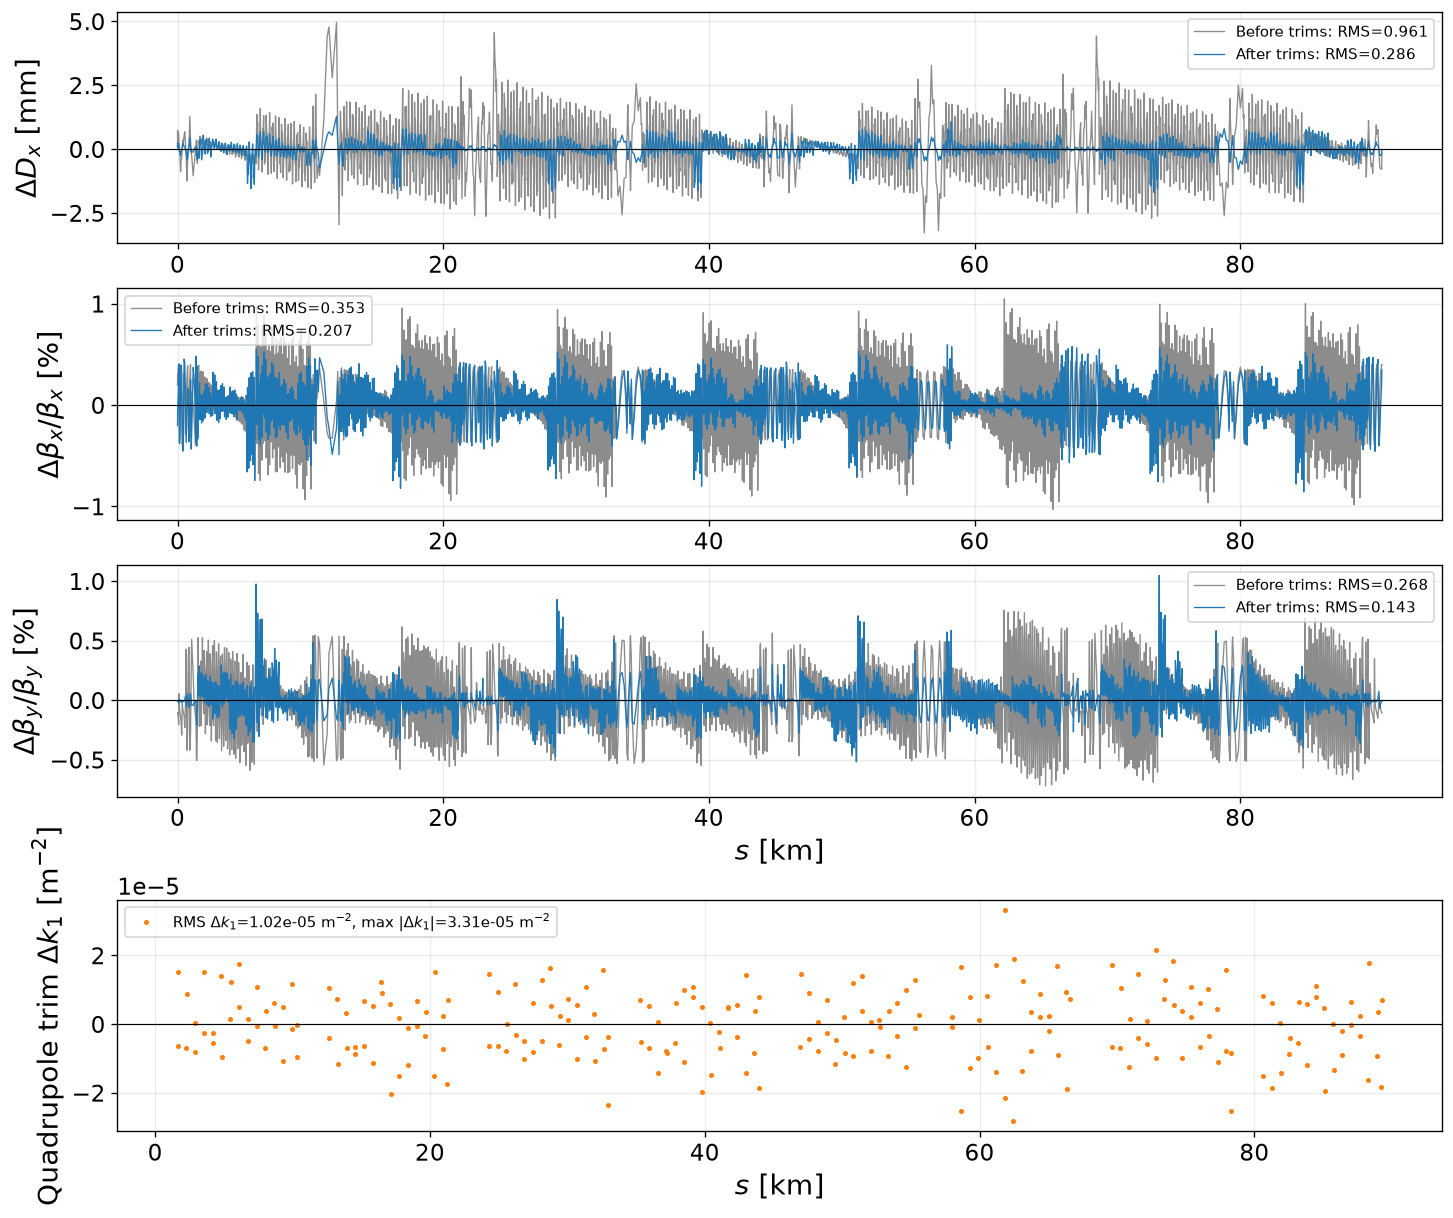

In [172]:
def quad_correction_metrics(twiss, reference, bpm_names, stage):
    names = list(np.asarray(bpm_names, dtype=str))
    case_index = twiss.rows.indices[names]
    reference_index = reference.rows.indices[names]
    dx_mm = 1e3 * (np.asarray(twiss.dx[case_index])
                     - np.asarray(reference.dx[reference_index]))
    betx_percent = 100 * (np.asarray(twiss.betx[case_index])
                           / np.asarray(reference.betx[reference_index]) - 1)
    bety_percent = 100 * (np.asarray(twiss.bety[case_index])
                           / np.asarray(reference.bety[reference_index]) - 1)
    local_rms = lambda values: float(np.sqrt(np.mean(np.asarray(values)**2)))
    return {
        "stage": stage,
        "Dx RMS [mm]": local_rms(dx_mm),
        "betx RMS [%]": local_rms(betx_percent),
        "bety RMS [%]": local_rms(bety_percent),
        "Qx error": float(twiss.qx - reference.qx),
        "Qy error": float(twiss.qy - reference.qy),
        "dQx error": float(twiss.dqx - reference.dqx),
        "dQy error": float(twiss.dqy - reference.dqy),
    }


quad_correction_summary = pd.DataFrame([
    quad_correction_metrics(twiss_before_quad_trims, twiss_ideal,
                            monitor_names, "Before quadrupole trims"),
    quad_correction_metrics(twiss_after_quad_trims, twiss_ideal,
                            monitor_names, "After quadrupole trims"),
])
display(quad_correction_summary)

names = list(np.asarray(monitor_names, dtype=str))
ib = twiss_before_quad_trims.rows.indices[names]
ia = twiss_after_quad_trims.rows.indices[names]
ir = twiss_ideal.rows.indices[names]
s_bpm_km = np.asarray(twiss_ideal.s[ir]) / 1e3

before = [
    1e3 * (np.asarray(twiss_before_quad_trims.dx[ib]) - np.asarray(twiss_ideal.dx[ir])),
    100 * (np.asarray(twiss_before_quad_trims.betx[ib]) / np.asarray(twiss_ideal.betx[ir]) - 1),
    100 * (np.asarray(twiss_before_quad_trims.bety[ib]) / np.asarray(twiss_ideal.bety[ir]) - 1),
]
after = [
    1e3 * (np.asarray(twiss_after_quad_trims.dx[ia]) - np.asarray(twiss_ideal.dx[ir])),
    100 * (np.asarray(twiss_after_quad_trims.betx[ia]) / np.asarray(twiss_ideal.betx[ir]) - 1),
    100 * (np.asarray(twiss_after_quad_trims.bety[ia]) / np.asarray(twiss_ideal.bety[ir]) - 1),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False, layout="constrained")
labels = [r"$\Delta D_x$ [mm]", r"$\Delta\beta_x/\beta_x$ [%]",
          r"$\Delta\beta_y/\beta_y$ [%]"]
for axis, values_before, values_after, ylabel in zip(axes[:3], before, after, labels):
    rms_before = np.sqrt(np.nanmean(np.asarray(values_before)**2))
    rms_after = np.sqrt(np.nanmean(np.asarray(values_after)**2))
    axis.plot(s_bpm_km, values_before, color="0.55", lw=0.8,
              label=f"Before trims: RMS={rms_before:.3g}")
    axis.plot(s_bpm_km, values_after, color="tab:blue", lw=0.8,
              label=f"After trims: RMS={rms_after:.3g}")
    axis.set_ylabel(ylabel)
    axis.legend(fontsize=9)

axes[2].set_xlabel(r"$s$ [km]")
trim_values = quad_trim_results["delta_k1"].to_numpy(float)
trim_rms = np.sqrt(np.nanmean(trim_values**2))
trim_max = np.nanmax(np.abs(trim_values))
axes[3].plot(quad_trim_results["s_km"], trim_values,
             ".", ms=4, color="tab:orange",
             label=(rf"RMS $\Delta k_1$={trim_rms:.3g} $\mathrm{{m}}^{{-2}}$, "
                    rf"max $|\Delta k_1|$={trim_max:.3g} $\mathrm{{m}}^{{-2}}$"))
axes[3].set_xlabel(r"$s$ [km]")
axes[3].set_ylabel(r"Quadrupole trim $\Delta k_1$ [$\mathrm{m}^{-2}$]")
axes[3].legend(fontsize=9)
for axis in axes:
    axis.axhline(0.0, color="black", lw=0.7)
    axis.grid(alpha=0.25)
    
plt.show()
